In [12]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import mat73
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import ttest_rel
from itertools import chain
parent_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
sys.path.append(parent_dir)
from GLM_regression import *
plt.rcParams.update({'font.size': 12,
                     'axes.spines.right': False,
                     'axes.spines.top':   False,
                     'legend.frameon':    False,})

def preprocess_data(filepath, normalize=True):
    data_dict = mat73.loadmat(filepath)

    # Define new position variables to use as input for the GLM
    num_spatial_bins = 10
    position_matrix = np.zeros((50, num_spatial_bins))
    bin_size = 50//num_spatial_bins
    for i in range(num_spatial_bins):
        position_matrix[i*bin_size:(i+1)*bin_size,i] = 1

    reorganized_data = {}
    variable_list = []

    for animal_idx, (delta_f,velocity,lick_rate,reward_loc) in enumerate(zip(data_dict['animal']['ShiftR'], data_dict['animal']['ShiftRunning'], data_dict['animal']['ShiftLrate'], data_dict['animal']['ShiftV'])):
        reorganized_data[f'animal_{animal_idx + 1}'] = {}

        for i, neuron_idx in enumerate(range(delta_f.shape[2])):
            if np.all(np.isnan(delta_f[:,:,neuron_idx])) or np.all(delta_f[:,:,neuron_idx] == 0):
                continue

            neuron_data = []
            
            # Neuron activity
            neuron_data.append(delta_f[:,:,neuron_idx]) 
            variable_list.append('Activity') if 'Activity' not in variable_list else None
            
            # Lick rate
            neuron_data.append(lick_rate)  
            variable_list.append('Licks') if 'Licks' not in variable_list else None

            # Reward location (valve opening)
            neuron_data.append(reward_loc)
            variable_list.append('Reward_loc') if 'Reward_loc' not in variable_list else None

            # Running speed
            neuron_data.append(velocity)
            variable_list.append('Velocity') if 'Velocity' not in variable_list else None

            ####################################################
            # TODO: EC_GLM.mat has a data mismatch (missing trial in neuron activity). Check with Christine
            num_trials = np.min([neuron_data[i].shape[1] for i in range(len(neuron_data))])
            for i in range(len(neuron_data)):
                neuron_data[i] = neuron_data[i][:, :num_trials]
            ####################################################

            neuron_data = np.stack(neuron_data, axis=1)

            # Add position variables to the data matrix
            expanded_position_matrix = np.repeat(position_matrix[:, :, np.newaxis], neuron_data.shape[2], axis=2) # Copy along the 'trials' dimension
            neuron_data = np.concatenate((neuron_data, expanded_position_matrix), axis=1)
            variable_list.extend([f'#{i}' for i in range(1, num_spatial_bins+1)]) if f'#{i}' not in variable_list else None

            # Filter out NaN trials
            neuron_data = neuron_data[:, :, ~np.isnan(neuron_data).any(axis=(0, 1))]

            if normalize:
                neuron_data = normalize_data(neuron_data)

            reorganized_data[f'animal_{animal_idx + 1}'][f'cell_{neuron_idx + 1}'] = neuron_data

    return reorganized_data, variable_list




datasets_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir, "datasets"))
filename_SST = "SSTindivsomata_GLM"
filepath_SST = os.path.join(datasets_dir, filename_SST+".mat")


datasets_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir, "datasets"))
filename_NDNF = "NDNFindivsomata_GLM"
filepath_NDNF = os.path.join(datasets_dir, filename_NDNF+".mat")


datasets_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir, "datasets"))
filename_EC = "EC_GLM"
filepath_EC = os.path.join(datasets_dir, filename_EC+".mat")


reorganized_data, variable_list = preprocess_data(filepath_SST)
GLM_params = fit_GLM(reorganized_data, quintile=None, regression='ridge')

In [13]:
velocity_list = []
for animal, subdict in reorganized_data.items():
        for cell, value in subdict.items():
            neuron_data = reorganized_data[animal][cell]
            velocity = neuron_data[:, 3, :]
            velocity_list.append(velocity)

list_of_2d_velocities = [np.vstack(arrays) for arrays in velocity_list]

flat_2d_velocities_list = []
for i in list_of_2d_velocities:
    flat_2d_velocities_list.append(i.flatten())
    
    
trial_av_vel_list = []

for i in list_of_2d_velocities:
    trial_av_vel_list.append(np.mean(i, axis=1))
    

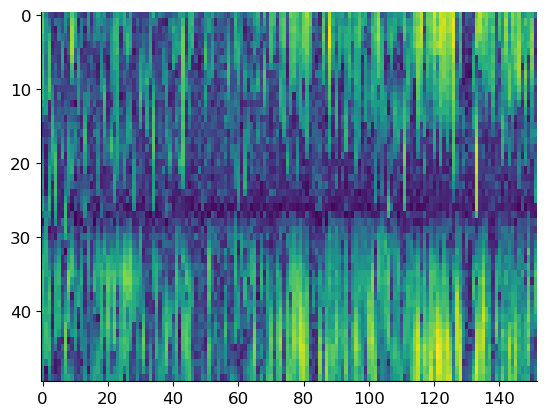

In [14]:
plt.imshow(list_of_2d_velocities[5], aspect='auto')

In [15]:
print(variable_list)

['Activity', 'Licks', 'Reward_loc', 'Velocity', '#1', '#2', '#3', '#4', '#5', '#6', '#7', '#8', '#9', '#10']


In [16]:
def compute_residual_activity(GLM_params, reorganized_data, quintile=None):
    neuron_activity_list = []
    predicted_activity_list = []
    residual_activity = {}
    avg_residuals = []
    for animal in GLM_params:
        residual_activity[animal] = {}
        for neuron in GLM_params[animal]:
            # Pre-process the data
            neuron_data = reorganized_data[animal][neuron]
            if quintile is not None:
                num_trials = neuron_data.shape[2]
                start_idx,end_idx = get_quintile_indices(num_trials, quintile)
                neuron_data = neuron_data[:, :, start_idx:end_idx]

            flattened_data = flatten_data(neuron_data)
            neuron_activity = neuron_data[:,0,:]

            # Predict activity and compute residuals
            glm_model = GLM_params[animal][neuron]['model']
            flattened_input_variables = flattened_data[:,1:]
            print(f"flattened_input_variables {flattened_input_variables}") #######################
            predicted_activity = glm_model.predict(flattened_input_variables)
            predicted_activity = predicted_activity.reshape(neuron_activity.shape)
            predicted_activity_list.append(predicted_activity)
            neuron_activity_list.append(neuron_activity)
            residual_activity[animal][neuron] = neuron_activity - predicted_activity

            avg_residuals.append(np.mean(residual_activity[animal][neuron], axis=1))

    avg_residuals = np.array(avg_residuals)
    return residual_activity, avg_residuals, predicted_activity_list, neuron_activity_list

In [17]:
def remove_variables_from_glm(GLM_params, vars_to_remove, variable_list):
    GLM_params_ = copy.deepcopy(GLM_params)

    idx_to_remove = [variable_list[1:].index(var) for var in vars_to_remove if var in variable_list[1:]]

    modified_GLM_params = {}
    for animal_key, neurons in GLM_params_.items():
        modified_GLM_params[animal_key] = {}
        for neuron_idx, params in neurons.items():
            params['model'].coef_[idx_to_remove] = 0
            if "intercept" in vars_to_remove:
                params['model'].intercept_ = 0
                params['intercept'] = 0
            print(f"params {params}") ####################################
            modified_GLM_params[animal_key][neuron_idx] = params

    return modified_GLM_params

In [18]:
def compute_variable_subtracted_residuals(reorganized_data, variable_list, variables_to_remove, quintile):
    #fit a GLM for all variables 
    GLM_params = fit_GLM(reorganized_data, quintile=quintile, regression='ridge', renormalize=False)
    #vars_to_remove = 
    vars_to_remove = variable_list.copy()[1:] + ['intercept']
    removing_list = []

    #look through the list of variables you try to remove - velocity or licks, etc 
    for variable in variables_to_remove:
        if variable in variable_list:
            index = variable_list.index(variable)
            removing_list.append(index)

    for index in removing_list:
        vars_to_remove.remove(variable_list[index])
        
    print(f"vars_to_remove {vars_to_remove}") ###############################

    filtered_GLM_params = remove_variables_from_glm(GLM_params, vars_to_remove, variable_list)
    residual_activity, avg_residuals, predicted_activity, neuron_activity_list = compute_residual_activity(filtered_GLM_params, reorganized_data,
                                                                 quintile=quintile)
    return avg_residuals, GLM_params, residual_activity, predicted_activity, neuron_activity_list

In [19]:
avg_residuals_SST_velocity, GLM_params, residual_activity_velocity_SST, vel_predicted_activity_SST_list, neuron_activity_list_SST = compute_variable_subtracted_residuals(reorganized_data, variable_list, ["Velocity"], quintile=None)

vars_to_remove ['Licks', 'Reward_loc', '#1', '#2', '#3', '#4', '#5', '#6', '#7', '#8', '#9', '#10', 'intercept']
params {'weights': array([ 0.        ,  0.        , -0.21384111,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ]), 'intercept': 0, 'alpha': 10.0, 'l1_ratio': None, 'R2': 0.03176303333314501, 'R2_trialavg': 0.8933778759100398, 'model': RidgeCV(alphas=[0.1, 1, 10, 100, 1000, 5000])}
params {'weights': array([0.        , 0.        , 0.27067897, 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        ]), 'intercept': 0, 'alpha': 100.0, 'l1_ratio': None, 'R2': 0.007701943976180514, 'R2_trialavg': 0.7674429029781443, 'model': RidgeCV(alphas=[0.1, 1, 10, 100, 1000, 5000])}
params {'weights': array([ 0.        ,  0.        , -0.63259375,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.  

len(residuals_SST_list) (50, 212)
len(vel_predicted_activity_SST_list) 75
len(neuron_activity_list_SST) 75


C:\Users\Msfin\AppData\Local\Temp\ipykernel_50220\1679274029.py:61: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


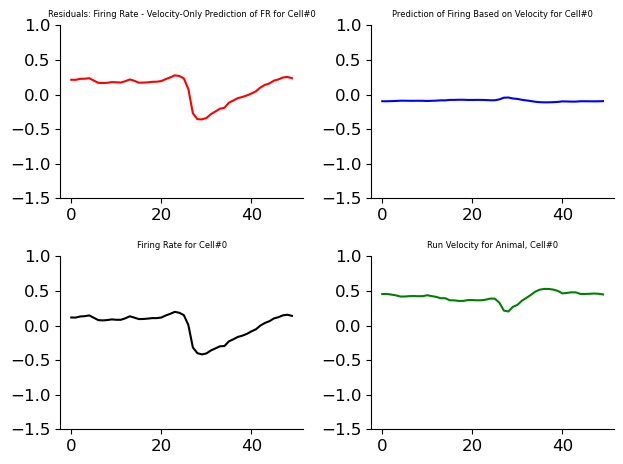

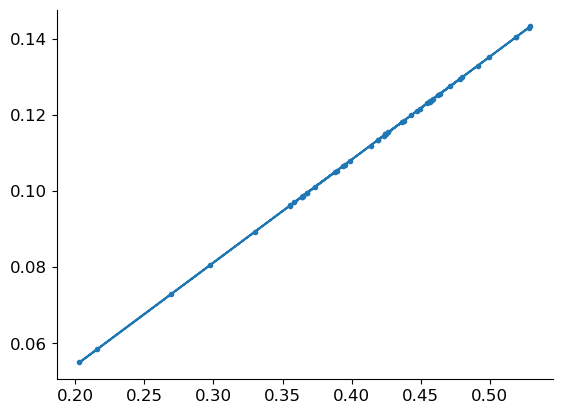

len(residuals_SST_list) (50, 212)
len(vel_predicted_activity_SST_list) 75
len(neuron_activity_list_SST) 75


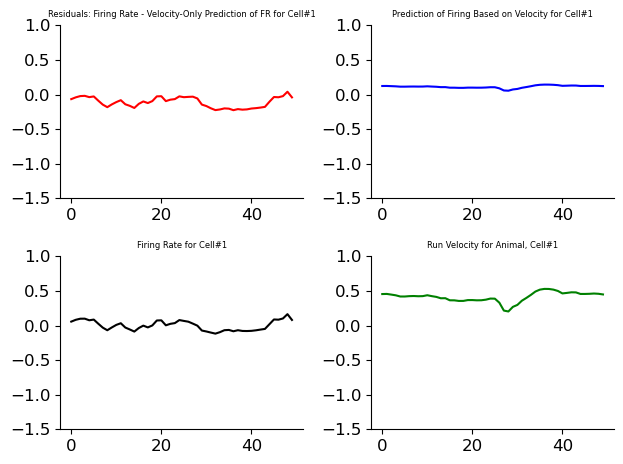

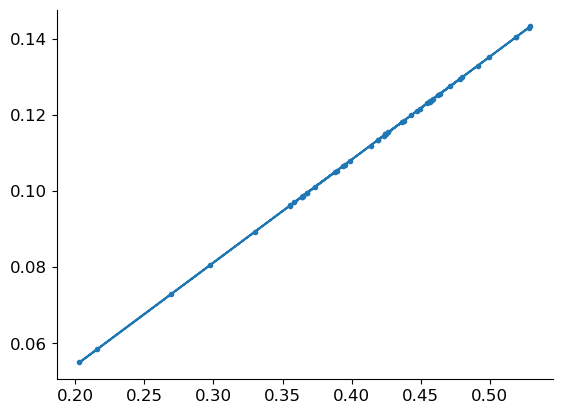

len(residuals_SST_list) (50, 212)
len(vel_predicted_activity_SST_list) 75
len(neuron_activity_list_SST) 75


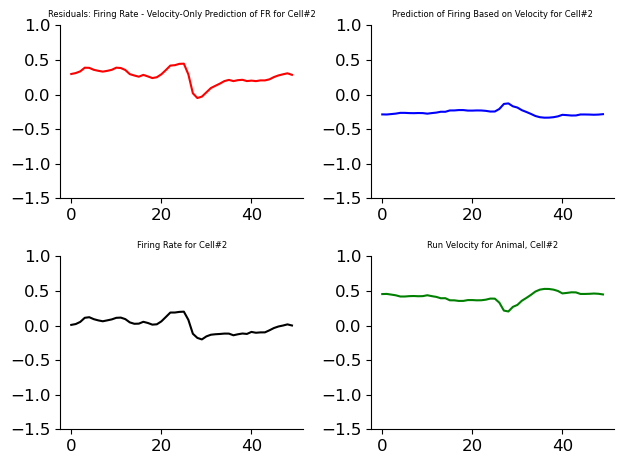

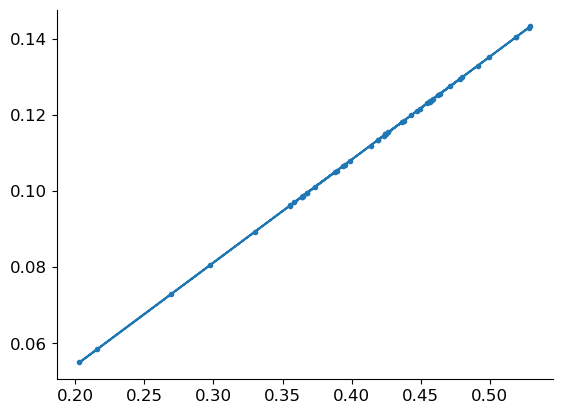

len(residuals_SST_list) (50, 212)
len(vel_predicted_activity_SST_list) 75
len(neuron_activity_list_SST) 75


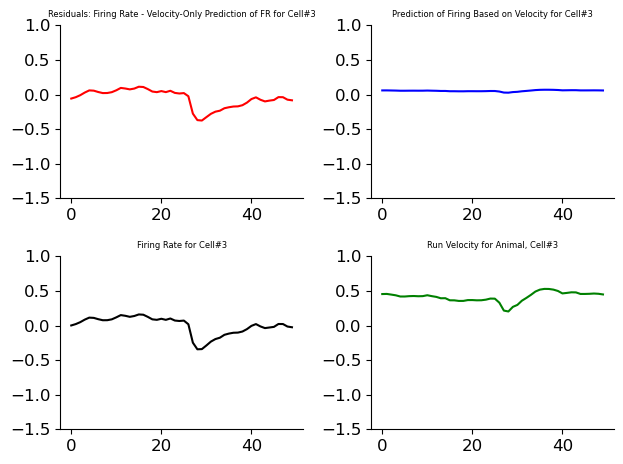

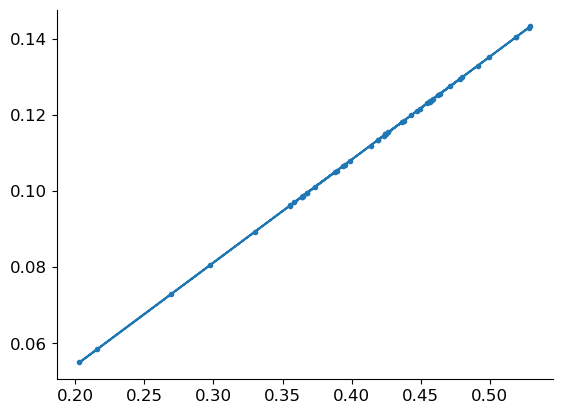

len(residuals_SST_list) (50, 212)
len(vel_predicted_activity_SST_list) 75
len(neuron_activity_list_SST) 75


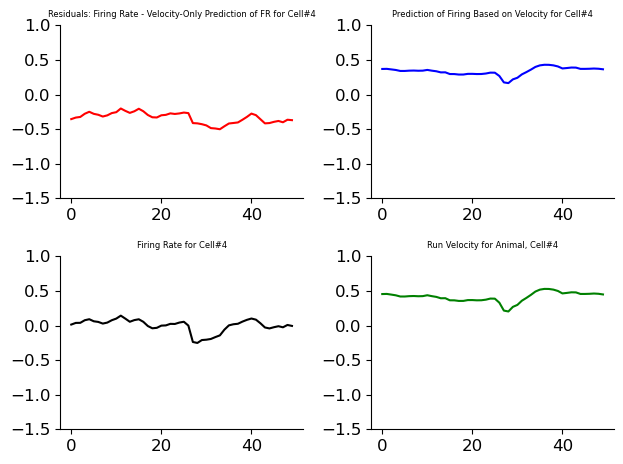

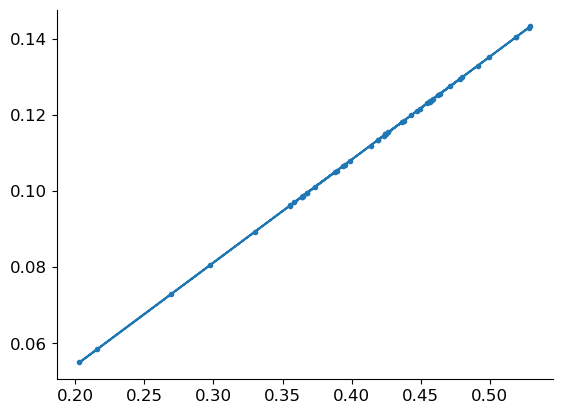

len(residuals_SST_list) (50, 212)
len(vel_predicted_activity_SST_list) 75
len(neuron_activity_list_SST) 75


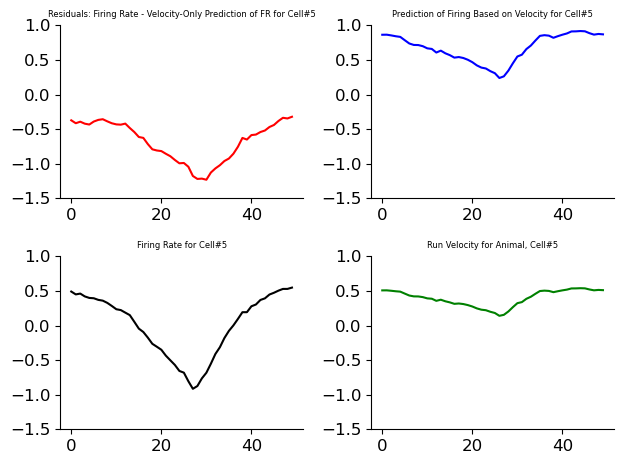

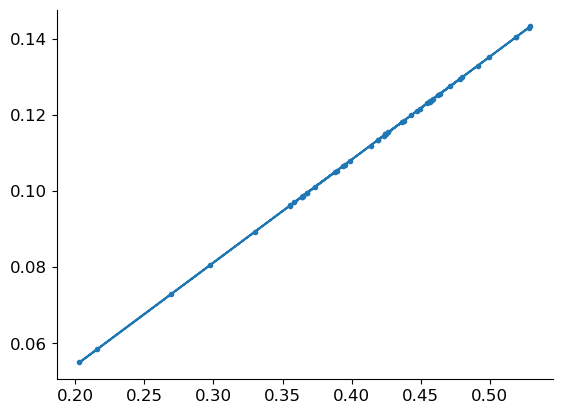

len(residuals_SST_list) (50, 212)
len(vel_predicted_activity_SST_list) 75
len(neuron_activity_list_SST) 75


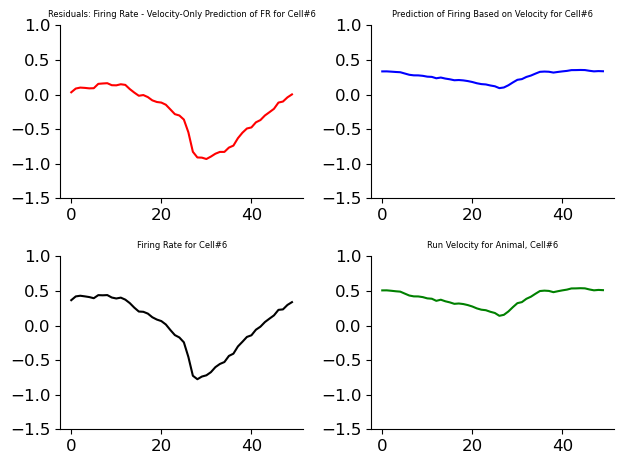

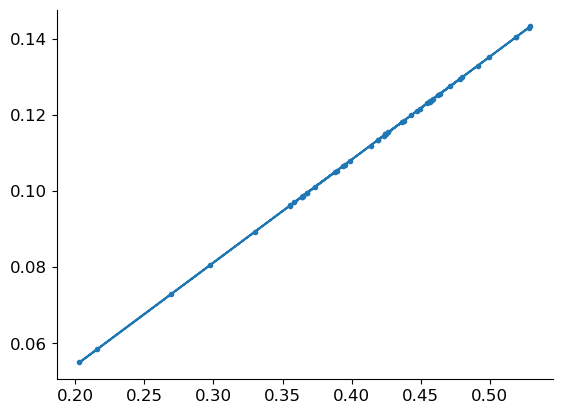

len(residuals_SST_list) (50, 212)
len(vel_predicted_activity_SST_list) 75
len(neuron_activity_list_SST) 75


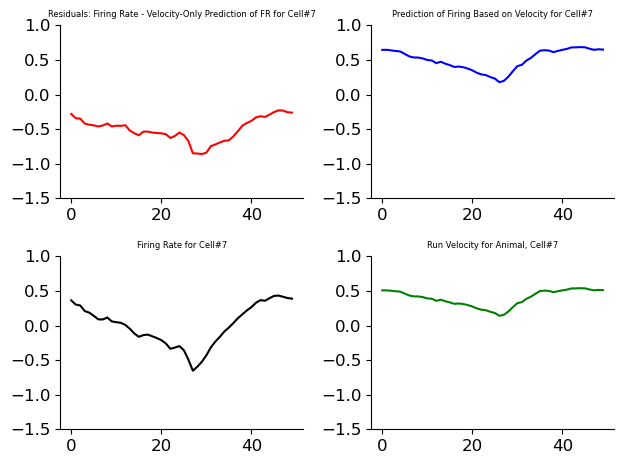

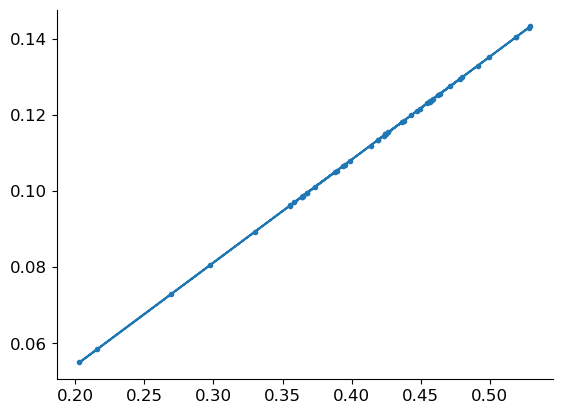

len(residuals_SST_list) (50, 212)
len(vel_predicted_activity_SST_list) 75
len(neuron_activity_list_SST) 75


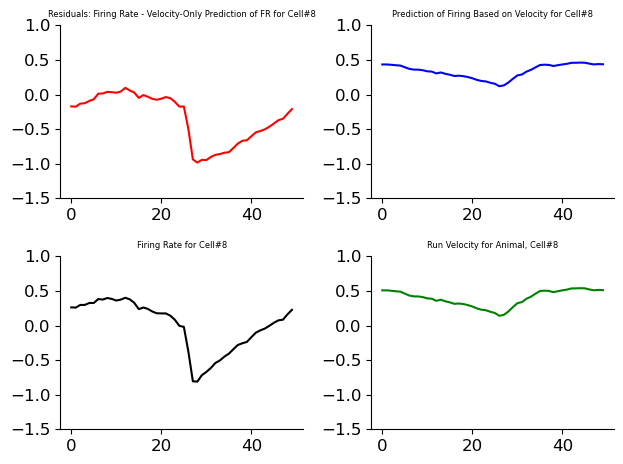

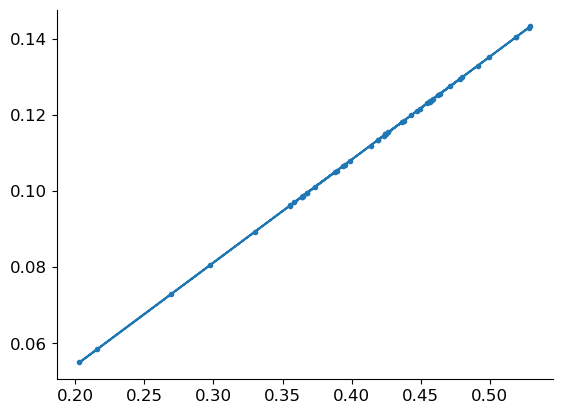

len(residuals_SST_list) (50, 212)
len(vel_predicted_activity_SST_list) 75
len(neuron_activity_list_SST) 75


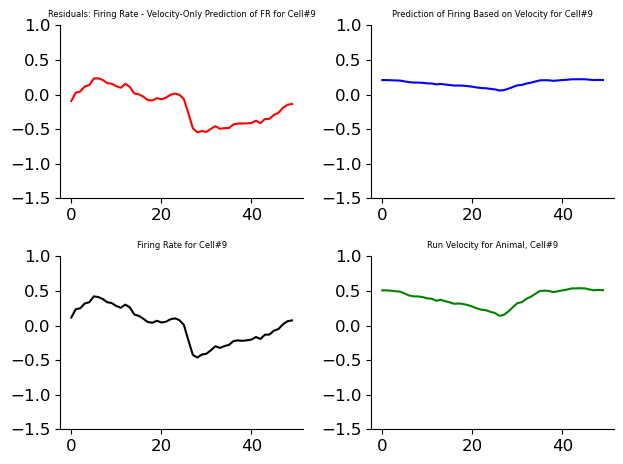

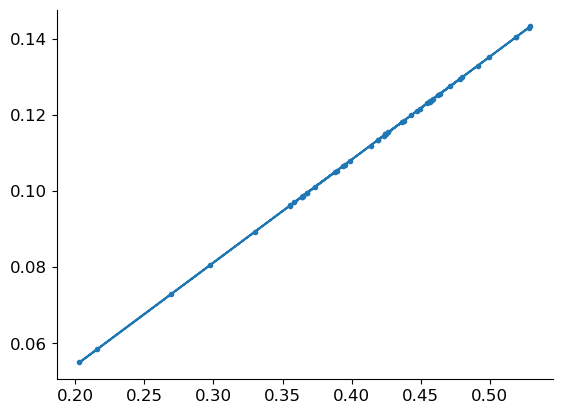

len(residuals_SST_list) (50, 212)
len(vel_predicted_activity_SST_list) 75
len(neuron_activity_list_SST) 75


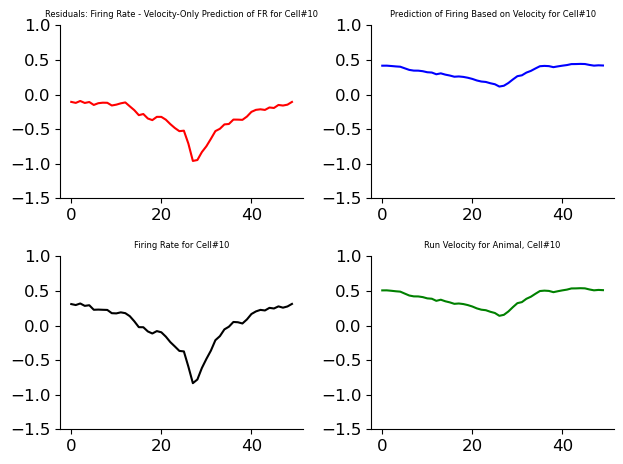

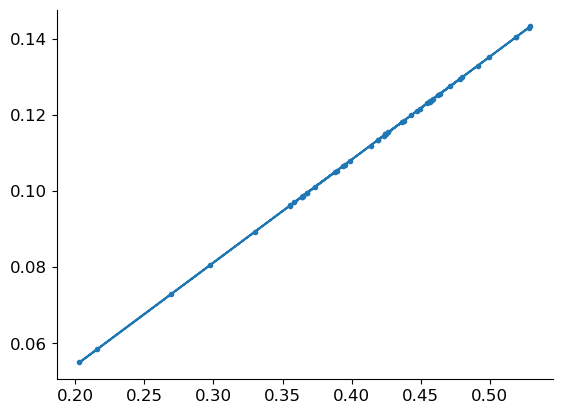

In [166]:
residuals_SST_list = []
for key, value in residual_activity_velocity_SST.items():
    for subkey, subvalue in value.items():
        residuals_SST_list.append(subvalue)
     

def plot_cell_velocity_neuron_activity_predicted_activity_off_velocity_and_residuals(reorganized_data, neuron_activity_list_SST, vel_predicted_activity_SST_list, residuals_SST_list, cell_number):
    
    cell_number = int(cell_number)
    
    trial_average_velocity_list = []
    velocity_list = []
    for animal, subdict in reorganized_data.items():
            for cell, value in subdict.items():
                neuron_data = reorganized_data[animal][cell]
                velocity = neuron_data[:, 3, :]
                velocity_list.append(velocity)
                trial_average_velocity_list.append(np.mean(velocity, axis=1))

    list_of_2d_velocities = [np.vstack(arrays) for arrays in velocity_list]
    
    print(f"len(residuals_SST_list) {residuals_SST_list[1].shape}")

    trial_av_residuals_list = []
    for i in residuals_SST_list:
        trial_av_residuals_list.append(np.mean(i, axis=1))
    
        
    print(f"len(vel_predicted_activity_SST_list) {len(vel_predicted_activity_SST_list)}")


    trial_av_velocity_prediction_list = []
    for i in vel_predicted_activity_SST_list:
        trial_av_velocity_prediction_list.append(np.mean(i, axis=1))

    print(f"len(neuron_activity_list_SST) {len(neuron_activity_list_SST)}")
        
    trial_av_neuron_activity_list = []
    for i in neuron_activity_list_SST:
        trial_av_neuron_activity_list.append(np.mean(i, axis=1))

    fig, axs = plt.subplots(2,2)

    axs[0,0].plot(trial_av_residuals_list[cell_number], color='r', label='residuals')
    axs[0,0].set_title(f"Residuals: Firing Rate - Velocity-Only Prediction of FR for Cell#{cell_number}", fontsize=6)
    axs[0,0].set_ylim(-1.5, 1)
    
    axs[0,1].plot(trial_av_velocity_prediction_list[cell_number], color='b', label='velocity prediction')
    axs[0,1].set_title(f"Prediction of Firing Based on Velocity for Cell#{cell_number}", fontsize=6)
    axs[0,1].set_ylim(-1.5, 1)

    axs[1,0].plot(trial_av_neuron_activity_list[cell_number], color='k', label='neuron activity')
    axs[1,0].set_title(f"Firing Rate for Cell#{cell_number}", fontsize=6)
    axs[1,0].set_ylim(-1.5, 1)

    axs[1,1].plot(trial_average_velocity_list[cell_number], color='g')
    axs[1,1].set_title(f"Run Velocity for Animal, Cell#{cell_number}", fontsize=6)
    axs[1,1].set_ylim(-1.5, 1)

    fig.tight_layout()
    fig.show()
    
    plt.figure()
    plt.plot(trial_average_velocity_list[1], trial_av_velocity_prediction_list[1] ,marker='.')
    plt.show()
    
    return trial_av_residuals_list, trial_av_velocity_prediction_list, trial_av_neuron_activity_list
    
cells = np.arange(0,11)
    
for i in cells:
    trial_av_residuals_list_velocity, trial_av_velocity_prediction_list, trial_av_neuron_activity_list = plot_cell_velocity_neuron_activity_predicted_activity_off_velocity_and_residuals(reorganized_data, neuron_activity_list_SST, vel_predicted_activity_SST_list, residuals_SST_list, i)

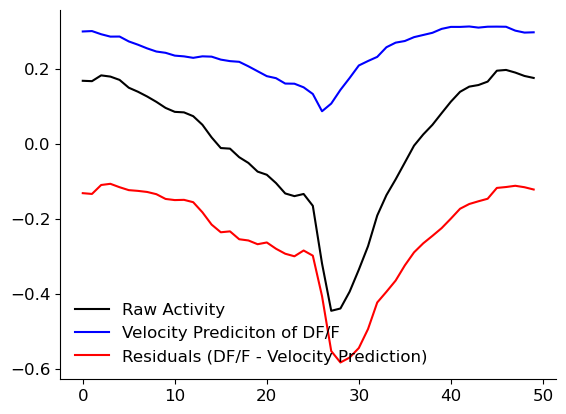

In [171]:
trial_av_residuals_list_velocity_2d = np.vstack(trial_av_residuals_list_velocity)
trial_av_velocity_prediction_list_2d = np.vstack(trial_av_velocity_prediction_list)
trial_av_neuron_activity_list_2d = np.vstack(trial_av_neuron_activity_list)

plt.figure()
plt.plot(np.mean(trial_av_neuron_activity_list_2d, axis=0), color='k', label="Raw Activity")
plt.plot(np.mean(trial_av_velocity_prediction_list_2d, axis=0), color='b', label="Velocity Prediciton of DF/F")
plt.plot(np.mean(trial_av_residuals_list_velocity_2d, axis=0), color='r', label="Residuals (DF/F - Velocity Prediction)")
plt.legend()
plt.show()

In [ ]:
#step 1 --- fit a glm to only velocity - the only variable it will get will be velocity 

In [ ]:
##### fit a GLM to only velocity -- all else zeroed out 

In [233]:
print(variable_list)

['Activity', 'Licks', 'Reward_loc', 'Velocity', '#1', '#2', '#3', '#4', '#5', '#6', '#7', '#8', '#9', '#10']


In [238]:
def fit_GLM_with_variable_removal(reorganized_data, variable_list, variables_to_fit=["all"], quintile=None, regression='ridge', renormalize=True, alphas=None):
    GLM_params = {}
    for animal in reorganized_data:
        GLM_params[animal] = {}
        count=0
        for neuron, neuron_data in reorganized_data[animal].items():
            print(f"count{count}")
            neuron_data = neuron_data[:,:,~np.isnan(neuron_data).any(axis=(0,1))]

            if quintile is not None:
                num_trials = neuron_data.shape[2]
                start_idx,end_idx = get_quintile_indices(num_trials, quintile)
                neuron_data = neuron_data[:, :, start_idx:end_idx]
                
                
                
            if renormalize:
                neuron_data = normalize_data(neuron_data)
                
            
                     
            flattened_data = flatten_data(neuron_data)
            design_matrix_X = flattened_data[:, 1:].copy() 
            
            if variables_to_fit == ["all"]:

                pass
            else:
                # Find indices to keep
                indices_to_keep = []
                for variable in variables_to_fit:
                    if variable in variable_list:
                        indices_to_keep.append(variable_list.index(variable) - 1)  
                    else:
                        raise ValueError(f"Variable '{variable}' not found in variable_list.")

                indices_to_remove = [i for i in range(design_matrix_X.shape[1]) if i not in indices_to_keep]
                design_matrix_X[:, indices_to_remove] = 0


            neuron_activity = flattened_data[:, 0]
                     
           
            
            print(f"design_matrix_x {design_matrix_X}")
            neuron_activity = flattened_data[:,0]
            print(f"neuron_activity {neuron_activity.shape}")

            if regression == 'lasso':
                model = LassoCV(alphas=alphas, cv=None) if alphas is not None else LassoCV(cv=None)
            elif regression == 'ridge':
                model = RidgeCV(alphas=alphas if alphas is not None else [0.1, 1, 10, 100, 1000, 5000], cv=None)
            elif regression == 'elastic':
                l1_ratio = [0.1, 0.3, 0.5, 0.7, 0.9, 1]
                model = ElasticNetCV(alphas=alphas if alphas is not None else [0.1, 1, 10, 100, 1000, 5000], l1_ratio=l1_ratio, cv=None)
            else:
                raise ValueError("Regression type must be 'lasso' or 'ridge'")

            model.fit(design_matrix_X, neuron_activity)

            predicted_activity = model.predict(design_matrix_X)
            trialavg_neuron_activity = np.mean(neuron_data[:,0,:], axis=1)
            trialavg_predicted_activity = np.mean(predicted_activity.reshape(neuron_data[:,0,:].shape), axis=1)
            pearson_R = np.corrcoef(trialavg_predicted_activity, trialavg_neuron_activity)[0,1]

            GLM_params[animal][neuron] = {
                'weights': model.coef_,
                'intercept': model.intercept_,
                'alpha': model.alpha_ if regression == 'ridge' else model.alpha_,
                'l1_ratio': model.l1_ratio_ if regression == 'elastic' else None,
                'R2': model.score(design_matrix_X, neuron_activity),
                'R2_trialavg': pearson_R**2,
                'model': model
            }
            count+=1
            
            
    return GLM_params


GLM_params = fit_GLM_with_variable_removal(reorganized_data, variable_list, variables_to_fit=["Velocity"], quintile=None, regression='ridge', renormalize=True, alphas=None)


count0
design_matrix_x [[0.         0.         0.38754994 ... 0.         0.         0.        ]
 [0.         0.         0.43966726 ... 0.         0.         0.        ]
 [0.         0.         0.2353543  ... 0.         0.         0.        ]
 ...
 [0.         0.         0.12634626 ... 0.         0.         0.        ]
 [0.         0.         0.52815293 ... 0.         0.         0.        ]
 [0.         0.         0.68826348 ... 0.         0.         0.        ]]
neuron_activity (10600,)
count1
design_matrix_x [[0.         0.         0.38754994 ... 0.         0.         0.        ]
 [0.         0.         0.43966726 ... 0.         0.         0.        ]
 [0.         0.         0.2353543  ... 0.         0.         0.        ]
 ...
 [0.         0.         0.12634626 ... 0.         0.         0.        ]
 [0.         0.         0.52815293 ... 0.         0.         0.        ]
 [0.         0.         0.68826348 ... 0.         0.         0.        ]]
neuron_activity (10600,)
count2
design_ma

count1
design_matrix_x [[0.         0.         0.4588568  ... 0.         0.         0.        ]
 [0.         0.         0.3083549  ... 0.         0.         0.        ]
 [0.         0.         0.34302575 ... 0.         0.         0.        ]
 ...
 [0.         0.         0.41731746 ... 0.         0.         0.        ]
 [0.         0.         0.15890099 ... 0.         0.         0.        ]
 [0.         0.         0.12623609 ... 0.         0.         0.        ]]
neuron_activity (3150,)
count2
design_matrix_x [[0.         0.         0.4588568  ... 0.         0.         0.        ]
 [0.         0.         0.3083549  ... 0.         0.         0.        ]
 [0.         0.         0.34302575 ... 0.         0.         0.        ]
 ...
 [0.         0.         0.41731746 ... 0.         0.         0.        ]
 [0.         0.         0.15890099 ... 0.         0.         0.        ]
 [0.         0.         0.12623609 ... 0.         0.         0.        ]]
neuron_activity (3150,)
count3
design_matr

count5
design_matrix_x [[0.         0.         0.70794079 ... 0.         0.         0.        ]
 [0.         0.         0.58333834 ... 0.         0.         0.        ]
 [0.         0.         0.43955977 ... 0.         0.         0.        ]
 ...
 [0.         0.         0.88366203 ... 0.         0.         0.        ]
 [0.         0.         0.46313436 ... 0.         0.         0.        ]
 [0.         0.         0.75680218 ... 0.         0.         0.        ]]
neuron_activity (8150,)
count6
design_matrix_x [[0.         0.         0.70794079 ... 0.         0.         0.        ]
 [0.         0.         0.58333834 ... 0.         0.         0.        ]
 [0.         0.         0.43955977 ... 0.         0.         0.        ]
 ...
 [0.         0.         0.88366203 ... 0.         0.         0.        ]
 [0.         0.         0.46313436 ... 0.         0.         0.        ]
 [0.         0.         0.75680218 ... 0.         0.         0.        ]]
neuron_activity (8150,)
count7
design_matr

design_matrix_x [[0.         0.         0.08702293 ... 0.         0.         0.        ]
 [0.         0.         0.21027183 ... 0.         0.         0.        ]
 [0.         0.         0.44599757 ... 0.         0.         0.        ]
 ...
 [0.         0.         0.17786719 ... 0.         0.         0.        ]
 [0.         0.         0.27927893 ... 0.         0.         0.        ]
 [0.         0.         0.35758439 ... 0.         0.         0.        ]]
neuron_activity (7450,)


In [251]:
### zeroes method

def compute_variable_subtracted_residuals_zero(reorganized_data, variable_list, variables_to_remove_predicting, quintile, variables_to_fit=["all"]):
    #fit a GLM for all variables 
    GLM_params = fit_GLM_with_variable_removal(reorganized_data, variable_list, variables_to_fit, quintile=None, regression='ridge', renormalize=True, alphas=None)
    #vars_to_remove = 
    vars_to_remove = variable_list.copy()[1:] + ['intercept']
    removing_list = []

    #look through the list of variables you try to remove - velocity or licks, etc 
    for variable in variables_to_remove_predicting:
        if variable in variable_list:
            index = variable_list.index(variable)
            removing_list.append(index)

    for index in removing_list:
        vars_to_remove.remove(variable_list[index])
        
    print(f"vars_to_remove {vars_to_remove}") ###############################

    filtered_GLM_params = remove_variables_from_glm(GLM_params, vars_to_remove, variable_list)
    residual_activity, avg_residuals, predicted_activity, neuron_activity_list = compute_residual_activity(filtered_GLM_params, reorganized_data,
                                                                 quintile=quintile)
    return avg_residuals, GLM_params, residual_activity, predicted_activity, neuron_activity_list

In [244]:
#get the residuals from the vlocity-only prediction 

In [245]:
vel_only_avg_residuals_zero, vel_only_GLM_params_zero, vel_only_residual_activity_zero, vel_only_vel_predicted_activity_zero, vel_only_neuron_activity_list_zer = compute_variable_subtracted_residuals_only_velocity_zero(reorganized_data, variable_list, variables_to_remove_predicting = ["Velocity"], quintile=None, variables_to_fit=["Velocity"])

count0
design_matrix_x [[0.         0.         0.38754994 ... 0.         0.         0.        ]
 [0.         0.         0.43966726 ... 0.         0.         0.        ]
 [0.         0.         0.2353543  ... 0.         0.         0.        ]
 ...
 [0.         0.         0.12634626 ... 0.         0.         0.        ]
 [0.         0.         0.52815293 ... 0.         0.         0.        ]
 [0.         0.         0.68826348 ... 0.         0.         0.        ]]
neuron_activity (10600,)
count1
design_matrix_x [[0.         0.         0.38754994 ... 0.         0.         0.        ]
 [0.         0.         0.43966726 ... 0.         0.         0.        ]
 [0.         0.         0.2353543  ... 0.         0.         0.        ]
 ...
 [0.         0.         0.12634626 ... 0.         0.         0.        ]
 [0.         0.         0.52815293 ... 0.         0.         0.        ]
 [0.         0.         0.68826348 ... 0.         0.         0.        ]]
neuron_activity (10600,)
count2
design_ma

count0
design_matrix_x [[0.         0.         0.52389345 ... 0.         0.         0.        ]
 [0.         0.         0.35421396 ... 0.         0.         0.        ]
 [0.         0.         0.51839454 ... 0.         0.         0.        ]
 ...
 [0.         0.         0.37289165 ... 0.         0.         0.        ]
 [0.         0.         0.24057056 ... 0.         0.         0.        ]
 [0.         0.         0.14217343 ... 0.         0.         0.        ]]
neuron_activity (3650,)
count1
design_matrix_x [[0.         0.         0.52389345 ... 0.         0.         0.        ]
 [0.         0.         0.35421396 ... 0.         0.         0.        ]
 [0.         0.         0.51839454 ... 0.         0.         0.        ]
 ...
 [0.         0.         0.37289165 ... 0.         0.         0.        ]
 [0.         0.         0.24057056 ... 0.         0.         0.        ]
 [0.         0.         0.14217343 ... 0.         0.         0.        ]]
neuron_activity (3650,)
count2
design_matr

count7
design_matrix_x [[0.         0.         0.70794079 ... 0.         0.         0.        ]
 [0.         0.         0.58333834 ... 0.         0.         0.        ]
 [0.         0.         0.43955977 ... 0.         0.         0.        ]
 ...
 [0.         0.         0.88366203 ... 0.         0.         0.        ]
 [0.         0.         0.46313436 ... 0.         0.         0.        ]
 [0.         0.         0.75680218 ... 0.         0.         0.        ]]
neuron_activity (8150,)
count8
design_matrix_x [[0.         0.         0.70794079 ... 0.         0.         0.        ]
 [0.         0.         0.58333834 ... 0.         0.         0.        ]
 [0.         0.         0.43955977 ... 0.         0.         0.        ]
 ...
 [0.         0.         0.88366203 ... 0.         0.         0.        ]
 [0.         0.         0.46313436 ... 0.         0.         0.        ]
 [0.         0.         0.75680218 ... 0.         0.         0.        ]]
neuron_activity (8150,)
count9
design_matr

params {'weights': array([ 0.       ,  0.       , -0.0867986,  0.       ,  0.       ,
        0.       ,  0.       ,  0.       ,  0.       ,  0.       ,
        0.       ,  0.       ,  0.       ]), 'intercept': 0, 'alpha': 100.0, 'l1_ratio': None, 'R2': 0.000713736013279398, 'R2_trialavg': 0.10743478665683125, 'model': RidgeCV(alphas=[0.1, 1, 10, 100, 1000, 5000])}
params {'weights': array([0.        , 0.        , 0.62840862, 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        ]), 'intercept': 0, 'alpha': 1.0, 'l1_ratio': None, 'R2': 0.012588626050577645, 'R2_trialavg': 0.013301977797245177, 'model': RidgeCV(alphas=[0.1, 1, 10, 100, 1000, 5000])}
params {'weights': array([0.        , 0.        , 0.31228132, 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        ]), 'intercept': 0, 'alpha': 10.0, 'l1_ratio': None, 'R2': 0.0036660070

C:\Users\Msfin\AppData\Local\Temp\ipykernel_50220\3914677247.py:134: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


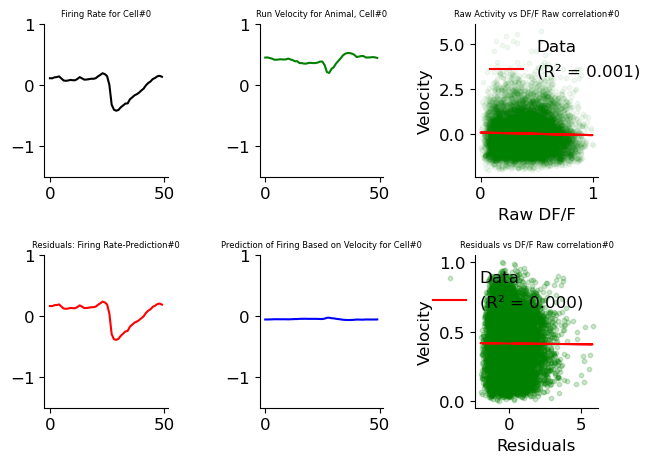

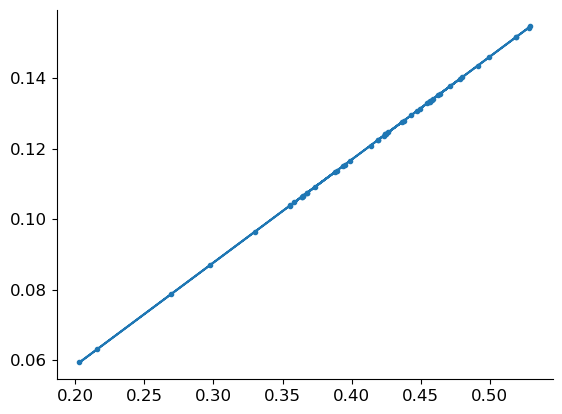

C:\Users\Msfin\AppData\Local\Temp\ipykernel_50220\3914677247.py:134: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


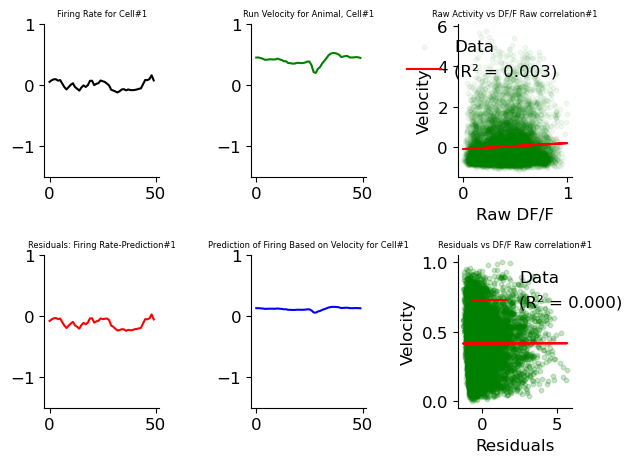

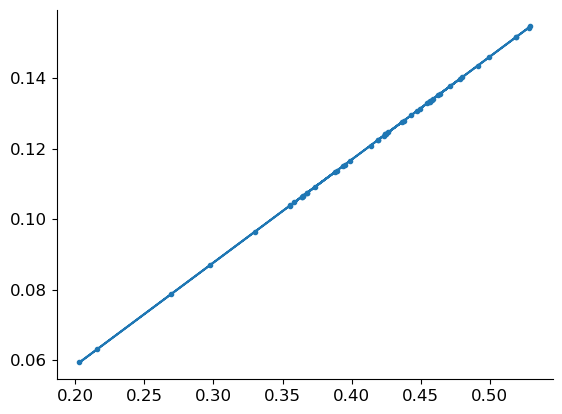

C:\Users\Msfin\AppData\Local\Temp\ipykernel_50220\3914677247.py:134: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


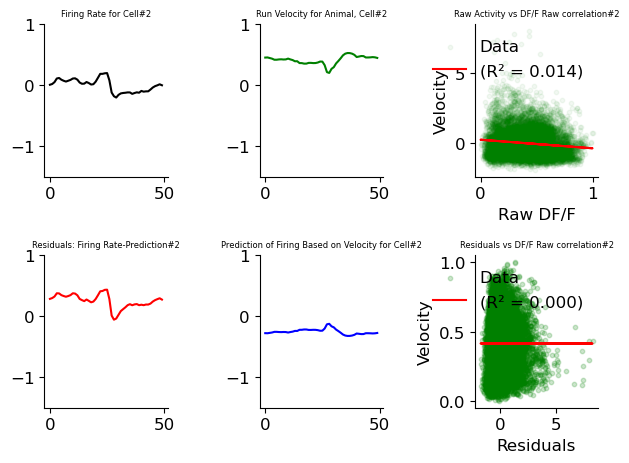

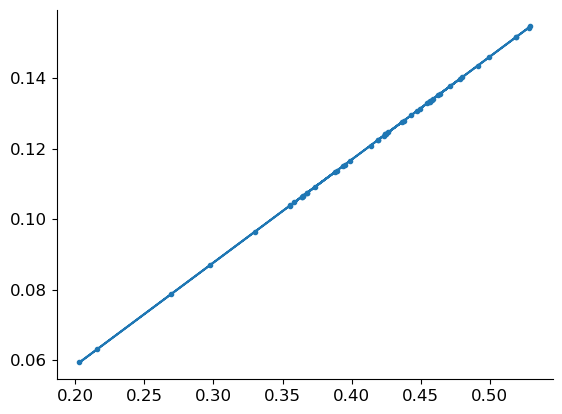

C:\Users\Msfin\AppData\Local\Temp\ipykernel_50220\3914677247.py:134: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


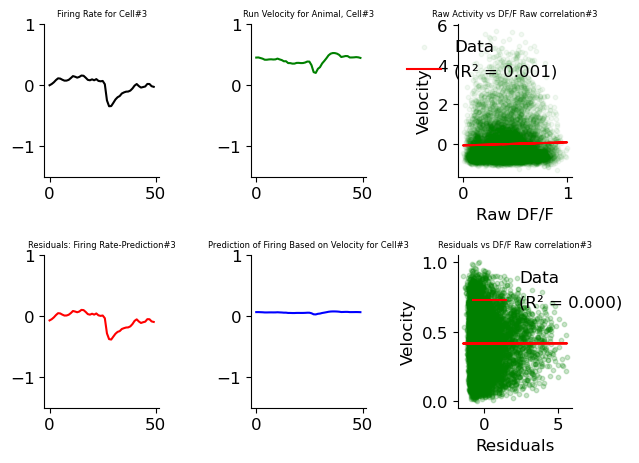

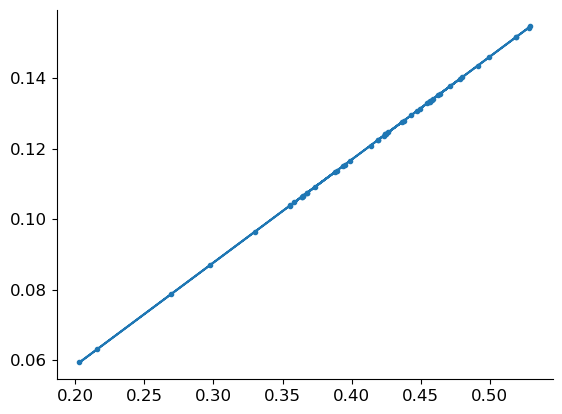

C:\Users\Msfin\AppData\Local\Temp\ipykernel_50220\3914677247.py:134: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


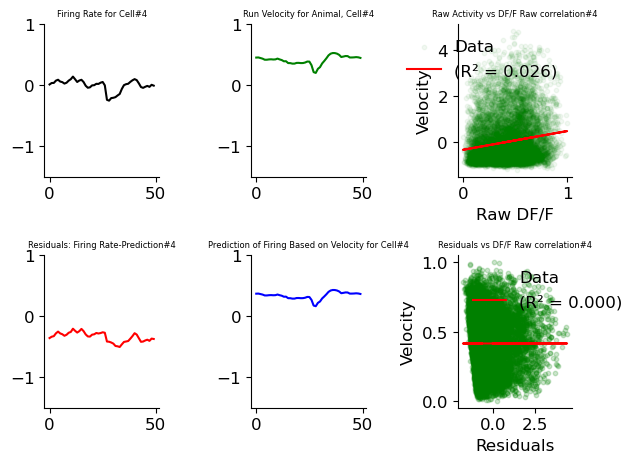

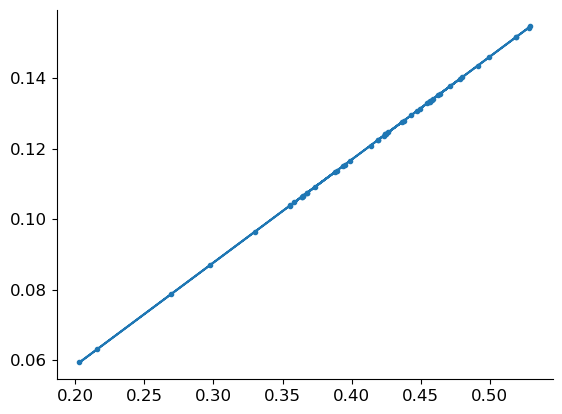

C:\Users\Msfin\AppData\Local\Temp\ipykernel_50220\3914677247.py:134: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


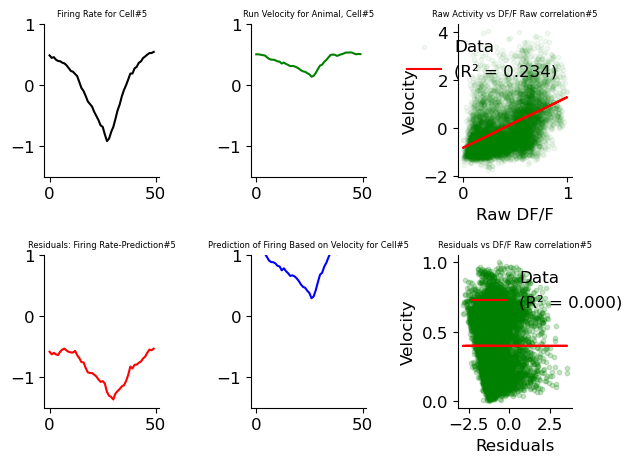

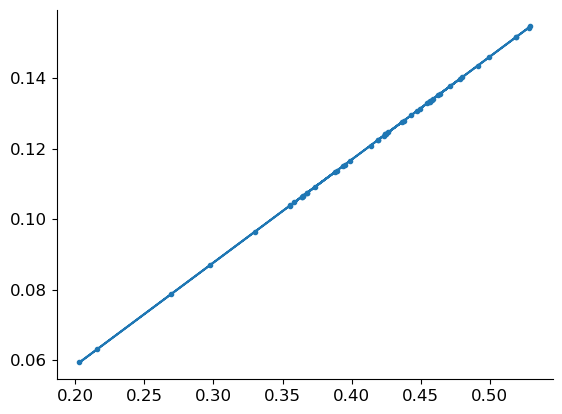

C:\Users\Msfin\AppData\Local\Temp\ipykernel_50220\3914677247.py:134: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


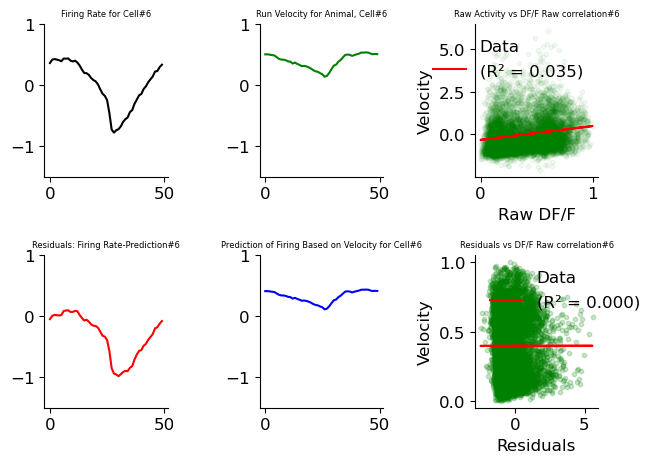

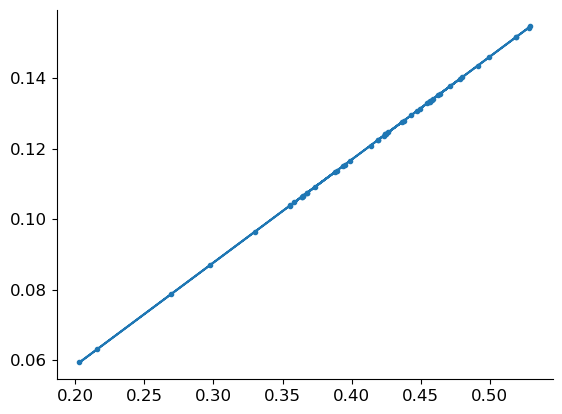

C:\Users\Msfin\AppData\Local\Temp\ipykernel_50220\3914677247.py:134: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


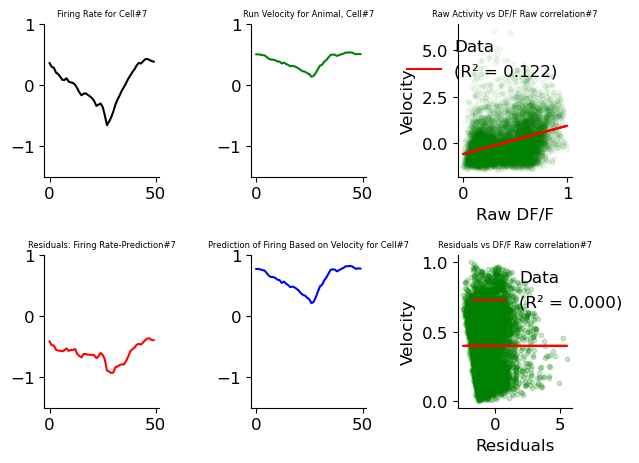

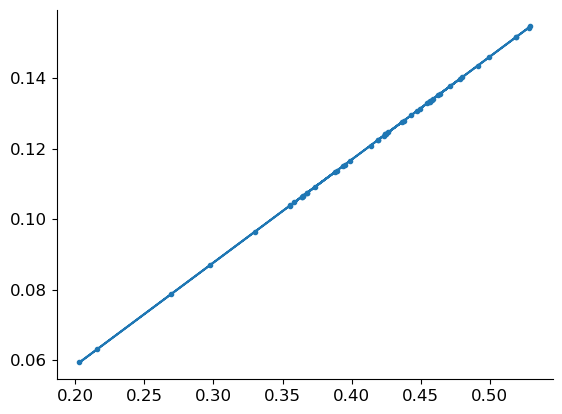

C:\Users\Msfin\AppData\Local\Temp\ipykernel_50220\3914677247.py:134: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


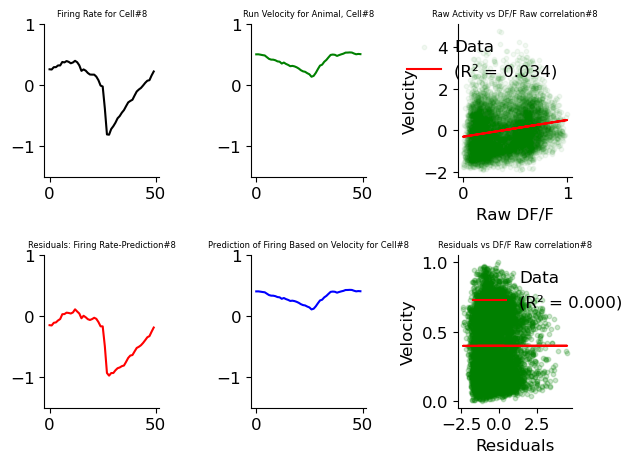

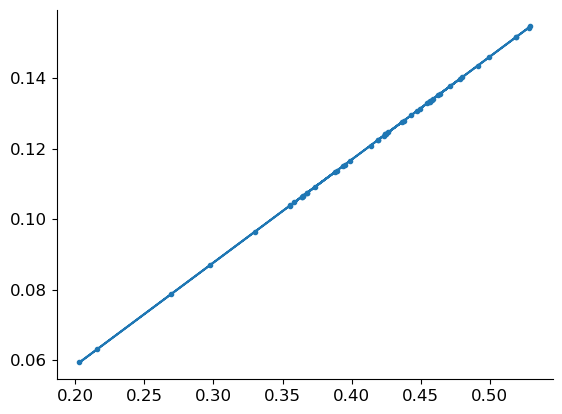

C:\Users\Msfin\AppData\Local\Temp\ipykernel_50220\3914677247.py:134: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


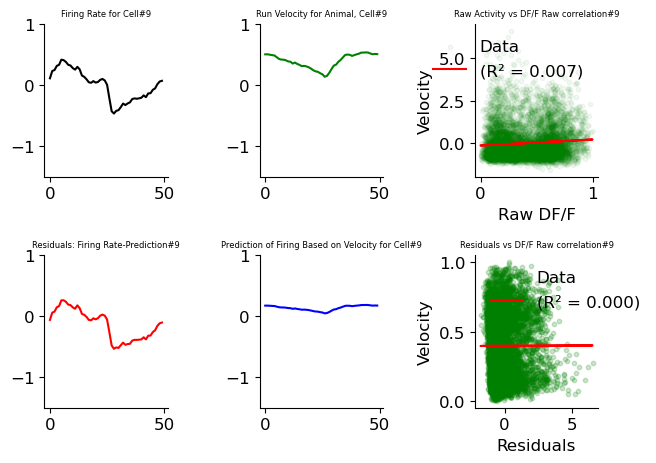

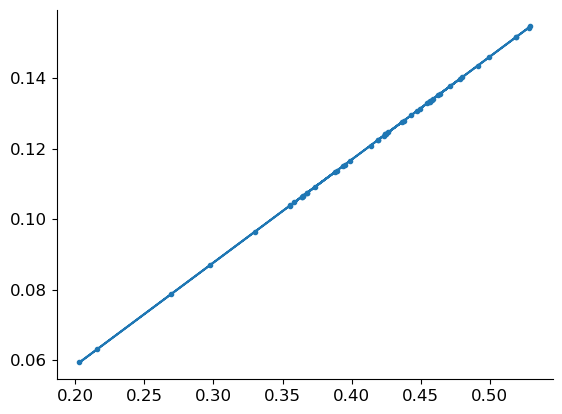

In [246]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

def plot_cell_velocity_neuron_activity_predicted_activity_off_velocity_and_residuals(reorganized_data, vel_only_neuron_activity_list_zero_final, vel_only_vel_predicted_activity_zero_final, vel_only_residual_activity_zero_final, cell_number):
    
    cell_number = int(cell_number)
    
    trial_average_velocity_list = []
    velocity_list = []
    for animal, subdict in reorganized_data.items():
            for cell, value in subdict.items():
                neuron_data = reorganized_data[animal][cell]
                velocity = neuron_data[:, 3, :]
                velocity_list.append(velocity)
                trial_average_velocity_list.append(np.mean(velocity, axis=1))
                
                
    list_of_2d_velocities = [np.vstack(arrays) for arrays in velocity_list]
    
    
    final_residual_list = []
    for key, value in vel_only_residual_activity_zero_final.items():
        for key2, value2 in value.items():
            final_residual_list.append(value2)
            
    trial_av_residuals_list = []
    for i in final_residual_list:
        trial_av_residuals_list.append(np.mean(i, axis=1))
    

    trial_av_velocity_prediction_list = []
    for i in vel_only_vel_predicted_activity_zero_final:
        trial_av_velocity_prediction_list.append(np.mean(i, axis=1))

        
    trial_av_neuron_activity_list = []
    for i in vel_only_neuron_activity_list_zero_final:
        trial_av_neuron_activity_list.append(np.mean(i, axis=1))

    fig, axs = plt.subplots(2,3)
    

    axs[0,0].plot(trial_av_neuron_activity_list[cell_number], color='k', label='neuron activity')
    axs[0,0].set_title(f"Firing Rate for Cell#{cell_number}", fontsize=6)
    axs[0,0].set_ylim(-1.5, 1)

    axs[0,1].plot(trial_average_velocity_list[cell_number], color='g')
    axs[0,1].set_title(f"Run Velocity for Animal, Cell#{cell_number}", fontsize=6)
    axs[0,1].set_ylim(-1.5, 1)
 
    
    flattened_velocity_list = []
    for i in velocity_list:
        flattened_velocity_list.append(i.flatten())
    
    
    flattened_activity_list = []
    for i in vel_only_neuron_activity_list_zero_final:
        flattened_activity_list.append(i.flatten())
        
    
    r2_list_activity = []
    y_pred_list = []
    x_list = []
    y_list = []
    
    for cell in range(len(velocity_list)):
    
        x = np.array(flattened_velocity_list[cell])
        x_list.append(x)
        y = np.array(flattened_activity_list[cell])
        y_list.append(y)

        x_reshaped = x.reshape(-1, 1)  
        model = LinearRegression()
        model.fit(x_reshaped, y)

        y_pred = model.predict(x_reshaped)
        y_pred_list.append(y_pred)

        r2 = r2_score(y, y_pred)
        r2_list_activity.append(r2)

    axs[0,2].scatter(flattened_velocity_list[cell_number], flattened_activity_list[cell_number], color='g', s=10, alpha=0.05, label='Data')                           
    axs[0,2].plot(flattened_velocity_list[cell_number], y_pred_list[cell_number], color='r', label=f'(R² = {r2_list_activity[cell_number]:.3f})')
    axs[0,2].set_title(f"Raw Activity vs DF/F Raw correlation#{cell_number}", fontsize=6)
    axs[0,2].legend() 
    axs[0,2].set_xlabel("Raw DF/F")
    axs[0,2].set_ylabel("Velocity")
    
    
    
    axs[1,0].plot(trial_av_residuals_list[cell_number], color='r', label='residuals')
    axs[1,0].set_title(f"Residuals: Firing Rate-Prediction#{cell_number}", fontsize=6)
    axs[1,0].set_ylim(-1.5, 1)
    
    axs[1,1].plot(trial_av_velocity_prediction_list[cell_number], color='b', label='velocity prediction')
    axs[1,1].set_title(f"Prediction of Firing Based on Velocity for Cell#{cell_number}", fontsize=6)
    axs[1,1].set_ylim(-1.5, 1)

   
    
    flattened_residuals_list = []
    for i in final_residual_list:
        flattened_residuals_list.append(i.flatten())
    
    r2_list_residuals = []
    y_pred_list = []
    
    for cell in range(len(velocity_list)):
        
        x = np.array(flattened_residuals_list[cell])
        y = np.array(flattened_velocity_list[cell])

        x_reshaped = x.reshape(-1, 1)  
        model = LinearRegression()
        model.fit(x_reshaped, y)

        y_pred = model.predict(x_reshaped)

        r2 = r2_score(y, y_pred)
        r2_list_residuals.append(r2)
        y_pred_list.append(y_pred)
        

    axs[1,2].scatter(flattened_residuals_list[cell_number], flattened_velocity_list[cell_number], color='g', s=10, alpha=0.2, label='Data')                           
    axs[1,2].plot(flattened_residuals_list[cell_number], y_pred_list[cell_number], color='r', label=f'(R² = {r2_list_residuals[cell_number]:.3f})')
    axs[1,2].set_title(f"Residuals vs DF/F Raw correlation#{cell_number}", fontsize=6)
    axs[1,2].legend() 
    axs[1,2].set_xlabel("Residuals")
    axs[1,2].set_ylabel("Velocity")

    fig.tight_layout()
    fig.show()
    
    plt.figure()
    plt.plot(trial_average_velocity_list[1], trial_av_velocity_prediction_list[1] ,marker='.')
    plt.show()
    
    return r2_list_activity, r2_list_residuals, trial_av_residuals_list, trial_av_velocity_prediction_list, trial_av_neuron_activity_list

    
for i in range(10):
    r2_list_activity_zero, r2_list_residuals_zero, trial_av_residuals_list_zero, trial_av_velocity_prediction_list_zero, trial_av_neuron_activity_list_zero = plot_cell_velocity_neuron_activity_predicted_activity_off_velocity_and_residuals(reorganized_data, vel_only_neuron_activity_list_zero, vel_only_vel_predicted_activity_zero, vel_only_residual_activity_zero, i)
    
    
    


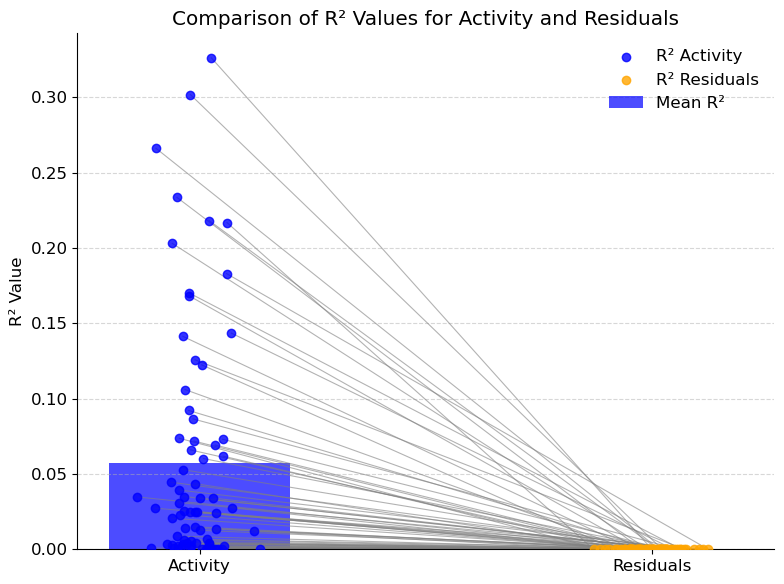

In [248]:
import matplotlib.pyplot as plt
import numpy as np

def plot_r2_difference_vs_velocity(r2_list_activity, r2_list_residuals):
    mean_activity = np.mean(r2_list_activity)
    mean_residuals = np.mean(r2_list_residuals)

    positions = [0, 1]

    plt.figure(figsize=(8, 6))

    plt.bar(positions, [mean_activity, mean_residuals], color=['blue', 'orange'], alpha=0.7, width=0.4, label='Mean R²')

    x_jitter_activity = np.random.normal(positions[0], 0.05, size=len(r2_list_activity))  
    x_jitter_residuals = np.random.normal(positions[1], 0.05, size=len(r2_list_residuals)) 

    plt.scatter(x_jitter_activity, r2_list_activity, color='blue', alpha=0.8, label='R² Activity', zorder=3)
    plt.scatter(x_jitter_residuals, r2_list_residuals, color='orange', alpha=0.8, label='R² Residuals', zorder=3)

    for i in range(len(r2_list_activity)):
        plt.plot([x_jitter_activity[i], x_jitter_residuals[i]],
                 [r2_list_activity[i], r2_list_residuals[i]],
                 color='gray', alpha=0.6, linewidth=0.8)


    plt.xticks(positions, ['Activity', 'Residuals'])
    plt.ylabel("R² Value")
    plt.title("Comparison of R² Values for Activity and Residuals")
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.5)


    plt.tight_layout()
    plt.show()

plot_r2_difference_vs_velocity(r2_list_activity_zero, r2_list_residuals_zero)

In [249]:
print(f"variable_list {variable_list}")

variable_list ['Activity', 'Licks', 'Reward_loc', 'Velocity', '#1', '#2', '#3', '#4', '#5', '#6', '#7', '#8', '#9', '#10']


In [ ]:
###### giving the GLM just position and then making position - removed 

In [250]:
GLM_params_position = fit_GLM_with_variable_removal(reorganized_data, variable_list, variables_to_fit=['#1', '#2', '#3', '#4', '#5', '#6', '#7', '#8', '#9', '#10'], quintile=None, regression='ridge', renormalize=True, alphas=None)

count0
design_matrix_x [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]]
neuron_activity (10600,)
count1
design_matrix_x [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]]
neuron_activity (10600,)
count2
design_matrix_x [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]]
neuron_activity (10600,)
count3
design_matrix_x [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]]
neuron_activity (10600,)
count4
design_matrix_x [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]]
neuro

count4
design_matrix_x [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]]
neuron_activity (8150,)
count5
design_matrix_x [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]]
neuron_activity (8150,)
count6
design_matrix_x [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]]
neuron_activity (8150,)
count7
design_matrix_x [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]]
neuron_activity (8150,)
count8
design_matrix_x [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]]
neuron_ac

In [ ]:
avg_residuals_position, GLM_params_position, residual_activity_position, predicted_activity_position, neuron_activity_list

In [258]:
avg_residuals_pos, GLM_params_position, residual_activity_position, predicted_activity_position_pos, neuron_activity_list_pos = compute_variable_subtracted_residuals_zero(reorganized_data, variable_list, variables_to_remove_predicting=['#1', '#2', '#3', '#4', '#5', '#6', '#7', '#8', '#9', '#10'], quintile=None, variables_to_fit=['#1', '#2', '#3', '#4', '#5', '#6', '#7', '#8', '#9', '#10'])

count0
design_matrix_x [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]]
neuron_activity (10600,)
count1
design_matrix_x [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]]
neuron_activity (10600,)
count2
design_matrix_x [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]]
neuron_activity (10600,)
count3
design_matrix_x [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]]
neuron_activity (10600,)
count4
design_matrix_x [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]]
neuro

count6
design_matrix_x [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]]
neuron_activity (8150,)
count7
design_matrix_x [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]]
neuron_activity (8150,)
count8
design_matrix_x [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]]
neuron_activity (8150,)
count9
design_matrix_x [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]]
neuron_activity (8150,)
count10
design_matrix_x [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]]
neuron_a

params {'weights': array([ 0.        ,  0.        ,  0.        ,  0.09239744,  0.03850386,
       -0.04136381, -0.09020635, -0.29666456, -0.62908007,  0.05200602,
        0.39094789,  0.32127434,  0.16218523]), 'intercept': 0, 'alpha': 10.0, 'l1_ratio': None, 'R2': 0.08080399570129781, 'R2_trialavg': 0.9204726953353911, 'model': RidgeCV(alphas=[0.1, 1, 10, 100, 1000, 5000])}
params {'weights': array([ 0.        ,  0.        ,  0.        ,  0.54036538,  0.27225556,
       -0.14062728, -0.43343264, -0.4840212 , -0.69395319, -0.27474546,
        0.11112967,  0.5018444 ,  0.60118475]), 'intercept': 0, 'alpha': 1.0, 'l1_ratio': None, 'R2': 0.1995596232518505, 'R2_trialavg': 0.9574029809567748, 'model': RidgeCV(alphas=[0.1, 1, 10, 100, 1000, 5000])}
params {'weights': array([ 0.        ,  0.        ,  0.        ,  0.22213959,  0.12599415,
       -0.04604938, -0.12931343, -0.10876702, -0.30783642, -0.0473116 ,
        0.03213446,  0.07579624,  0.18321342]), 'intercept': 0, 'alpha': 10.0, 'l1_

C:\Users\Msfin\AppData\Local\Temp\ipykernel_50220\3914677247.py:134: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


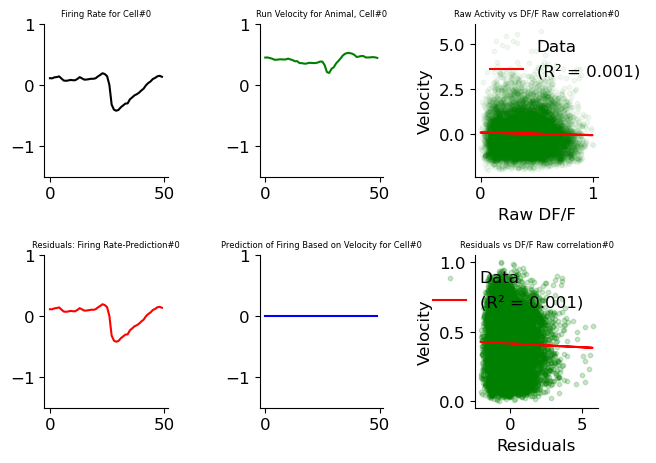

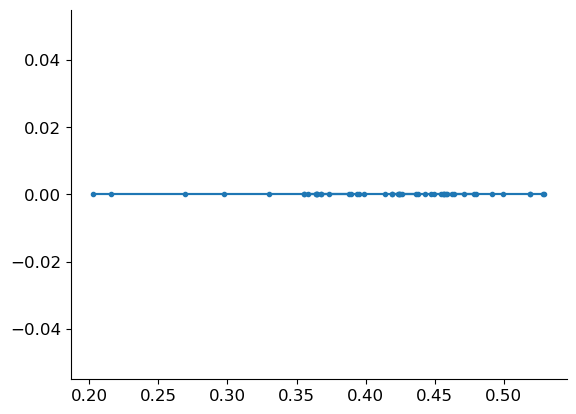

C:\Users\Msfin\AppData\Local\Temp\ipykernel_50220\3914677247.py:134: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


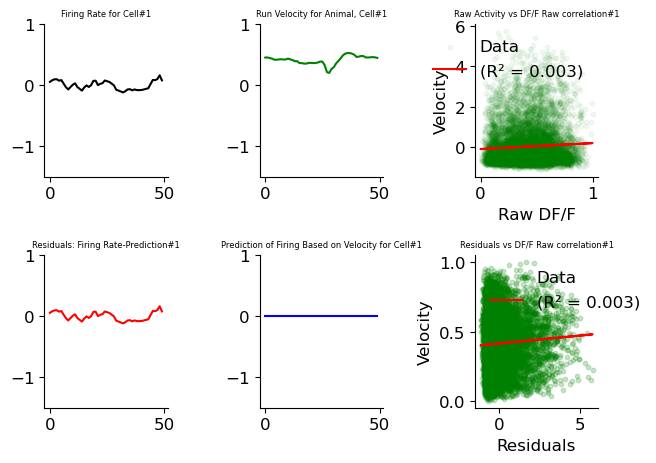

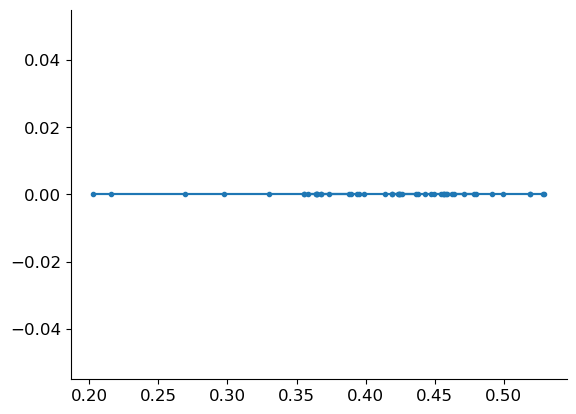

C:\Users\Msfin\AppData\Local\Temp\ipykernel_50220\3914677247.py:134: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


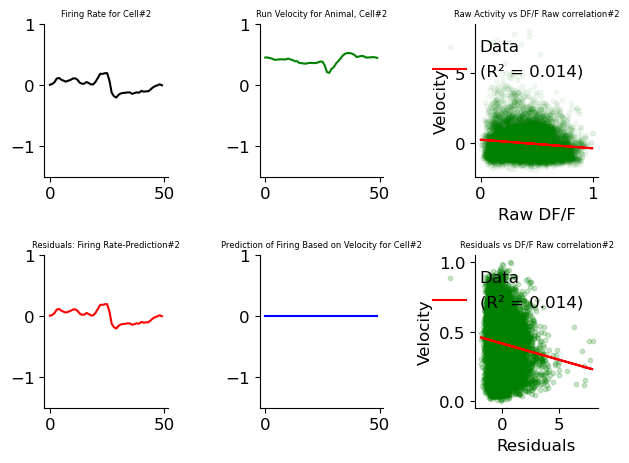

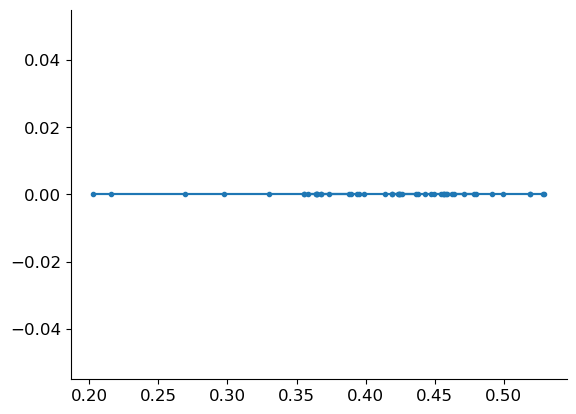

C:\Users\Msfin\AppData\Local\Temp\ipykernel_50220\3914677247.py:134: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


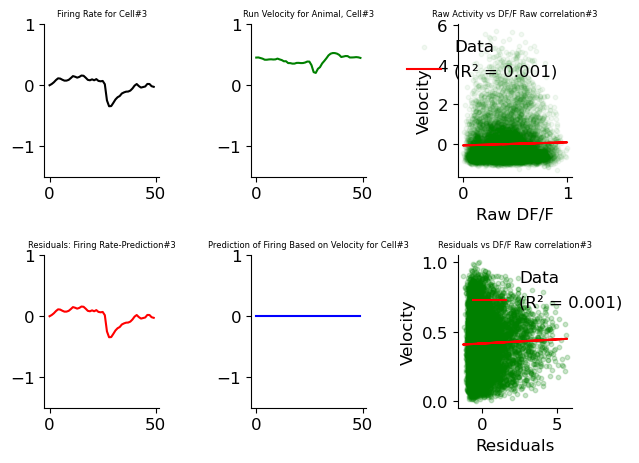

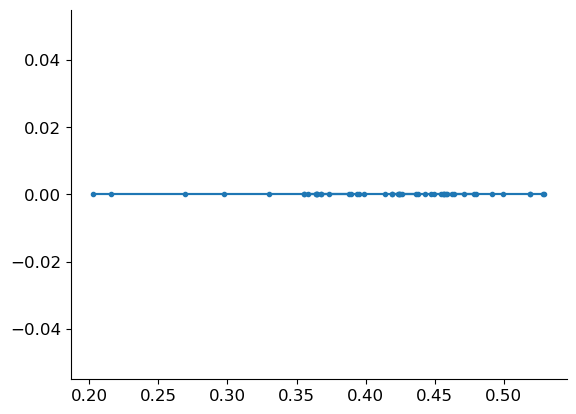

C:\Users\Msfin\AppData\Local\Temp\ipykernel_50220\3914677247.py:134: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


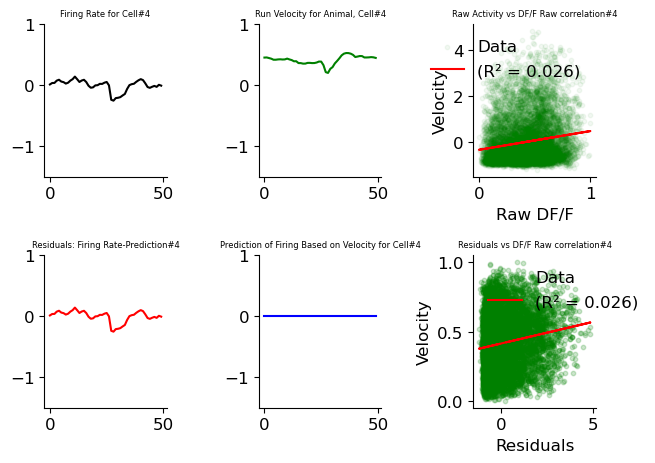

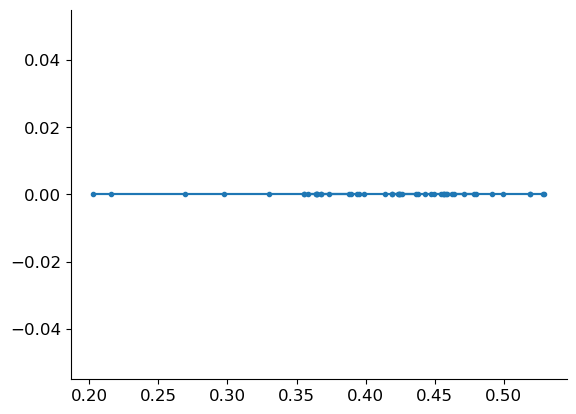

C:\Users\Msfin\AppData\Local\Temp\ipykernel_50220\3914677247.py:134: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


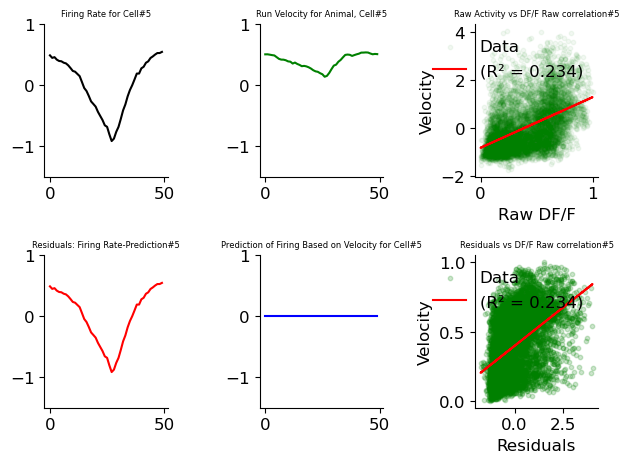

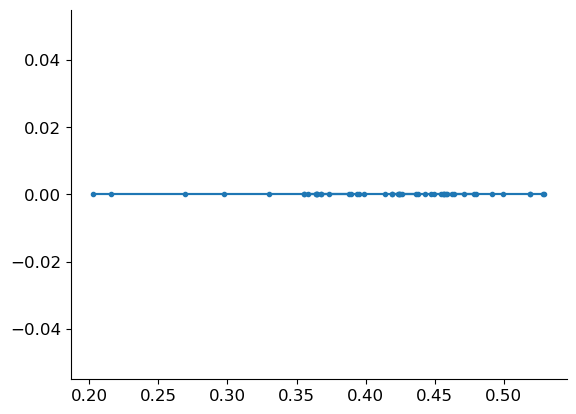

C:\Users\Msfin\AppData\Local\Temp\ipykernel_50220\3914677247.py:134: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


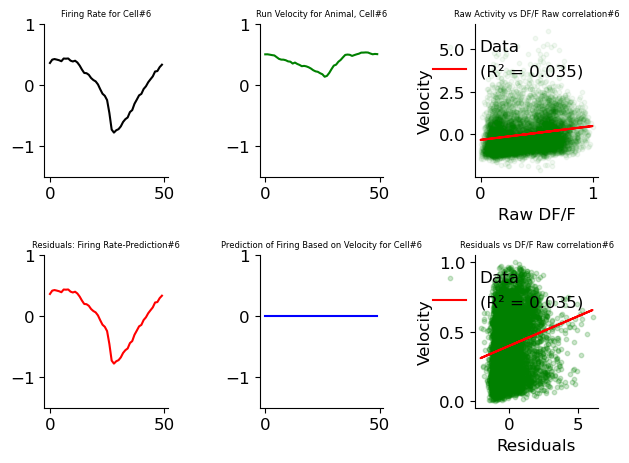

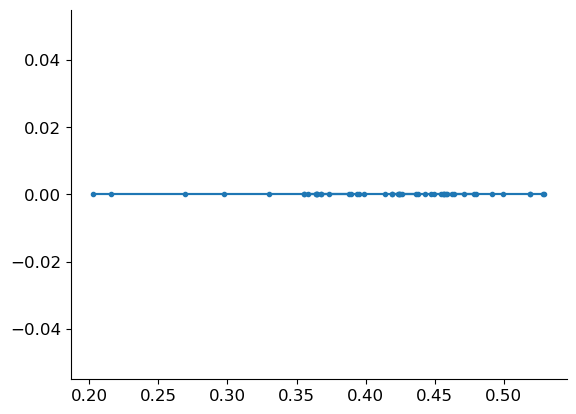

C:\Users\Msfin\AppData\Local\Temp\ipykernel_50220\3914677247.py:134: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


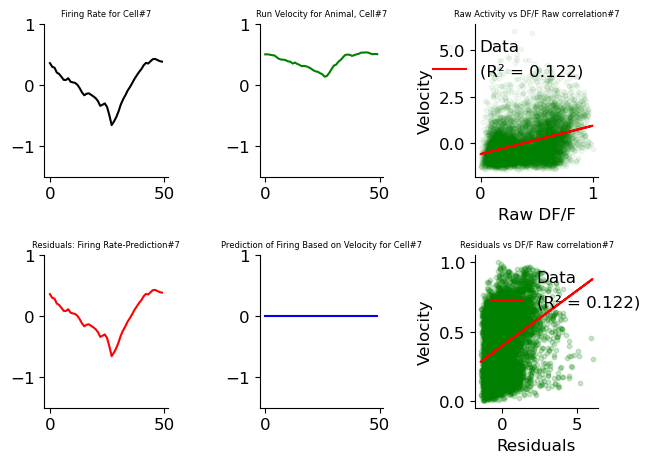

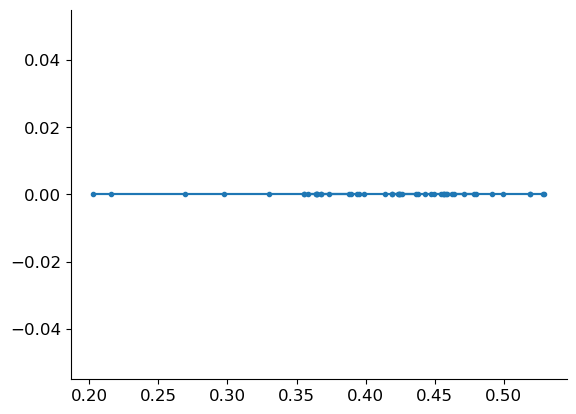

C:\Users\Msfin\AppData\Local\Temp\ipykernel_50220\3914677247.py:134: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


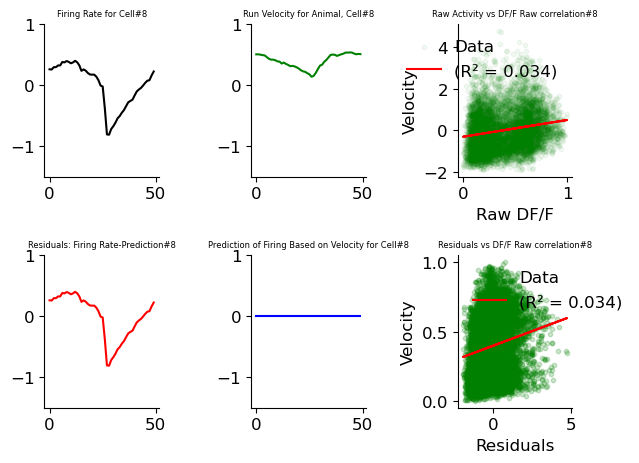

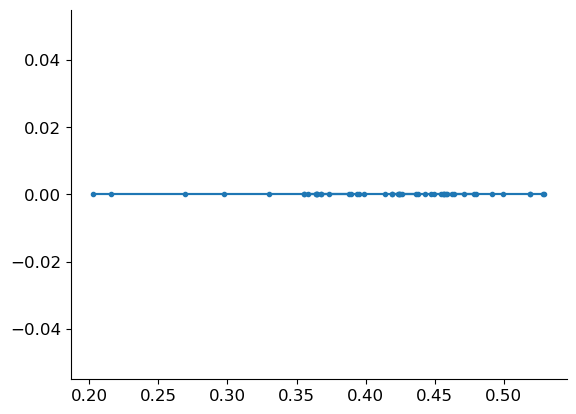

C:\Users\Msfin\AppData\Local\Temp\ipykernel_50220\3914677247.py:134: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


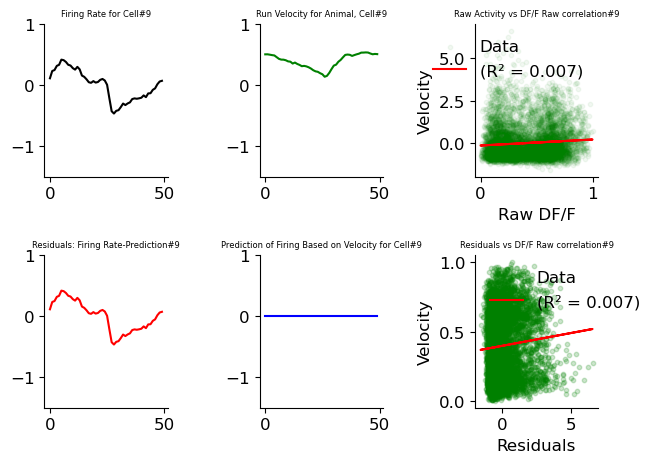

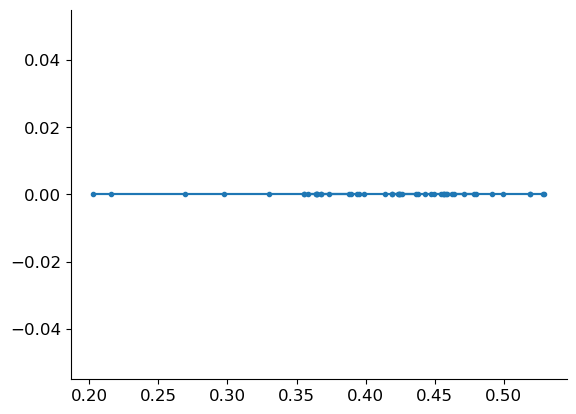

In [256]:

for i in range(10):
    r2_list_activity_zero_pos, r2_list_residuals_zero_pos, trial_av_residuals_list_zero_pos, trial_av_velocity_prediction_list_zero_pos, trial_av_neuron_activity_list_zero_pos = plot_cell_velocity_neuron_activity_predicted_activity_off_velocity_and_residuals(reorganized_data, neuron_activity_list_pos, predicted_activity_position_pos, residual_activity_position, i)
    

In [ ]:
#fit a second GLM where instead of making a prediction using raw df/f I am instead handing in the residuals (df/f - veloocity only prediction) and then getting the prediction based on every varaible except velocity 

In [94]:
def fit_GLM_to_velocity_residuals(vel_only_vel_predicted_activity_zero, reorganized_data, quintile=None, regression='ridge', renormalize=True, alphas=None):
    
    vel_only_vel_predicted_activity_zero_flat_list = []
    for i in vel_only_vel_predicted_activity_zero:
        vel_only_vel_predicted_activity_zero_flat_list.append(i.flatten())
    
    GLM_params = {}
    count = 0
    
    for animal in reorganized_data:
        GLM_params[animal] = {}
   
        for neuron, neuron_data in reorganized_data[animal].items():
            print(f"count {count}")
            neuron_data = neuron_data[:,:,~np.isnan(neuron_data).any(axis=(0,1))]

            if quintile is not None:
                num_trials = neuron_data.shape[2]
                start_idx,end_idx = get_quintile_indices(num_trials, quintile)
                neuron_data = neuron_data[:, :, start_idx:end_idx]
                
                
                
            if renormalize:
                neuron_data = normalize_data(neuron_data)
                
            

            flattened_data = flatten_data(neuron_data)
            design_matrix_X = flattened_data[:, 1:].copy()
            design_matrix_X[:, 2] = 0
            
            print(f"design_matrix_X.shape {design_matrix_X.shape}")
#             neuron_activity = flattened_data[:,0]

            neuron_activity = vel_only_vel_predicted_activity_zero_flat_list[count]
    
            print(f"neuron_activity {neuron_activity.shape}")

            if regression == 'lasso':
                model = LassoCV(alphas=alphas, cv=None) if alphas is not None else LassoCV(cv=None)
            elif regression == 'ridge':
                model = RidgeCV(alphas=alphas if alphas is not None else [0.1, 1, 10, 100, 1000, 5000], cv=None)
            elif regression == 'elastic':
                l1_ratio = [0.1, 0.3, 0.5, 0.7, 0.9, 1]
                model = ElasticNetCV(alphas=alphas if alphas is not None else [0.1, 1, 10, 100, 1000, 5000], l1_ratio=l1_ratio, cv=None)
            else:
                raise ValueError("Regression type must be 'lasso' or 'ridge'")

            model.fit(design_matrix_X, neuron_activity)

            predicted_activity = model.predict(design_matrix_X)
            trialavg_neuron_activity = np.mean(neuron_data[:,0,:], axis=1)
            trialavg_predicted_activity = np.mean(predicted_activity.reshape(neuron_data[:,0,:].shape), axis=1)
            pearson_R = np.corrcoef(trialavg_predicted_activity, trialavg_neuron_activity)[0,1]

            GLM_params[animal][neuron] = {
                'weights': model.coef_,
                'intercept': model.intercept_,
                'alpha': model.alpha_ if regression == 'ridge' else model.alpha_,
                'l1_ratio': model.l1_ratio_ if regression == 'elastic' else None,
                'R2': model.score(design_matrix_X, neuron_activity),
                'R2_trialavg': pearson_R**2,
                'model': model
            }
            
            count+=1

    return GLM_params


In [ ]:
### get the residuals for that which are the subtraction between the raw df/f and the frankenstein prediction that is based on first velocity and then everything else 

In [95]:
def compute_variable_subtracted_residuals_only_velocity_zero_final(vel_only_vel_predicted_activity_zero, reorganized_data, variable_list, variables_to_remove, quintile):
    #fit a GLM for all variables 
    GLM_params = fit_GLM_to_velocity_residuals(vel_only_vel_predicted_activity_zero, reorganized_data, quintile=quintile, regression='ridge', renormalize=False)
    #vars_to_remove = 
    vars_to_remove = variable_list.copy()[1:] + ['intercept']
    removing_list = []

    #look through the list of variables you try to remove - velocity or licks, etc 
    for variable in variables_to_remove:
        if variable in variable_list:
            index = variable_list.index(variable)
            removing_list.append(index)

    for index in removing_list:
        vars_to_remove.remove(variable_list[index])
        
    print(f"vars_to_remove {vars_to_remove}") ###############################

    filtered_GLM_params = remove_variables_from_glm(GLM_params, vars_to_remove, variable_list)
    residual_activity, avg_residuals, predicted_activity, neuron_activity_list = compute_residual_activity(filtered_GLM_params, reorganized_data,
                                                                 quintile=quintile)
    return avg_residuals, GLM_params, residual_activity, predicted_activity, neuron_activity_list

vel_only_avg_residuals_zero_final, vel_only_GLM_params_zero_final, vel_only_residual_activity_zero_final, vel_only_vel_predicted_activity_zero_final, vel_only_neuron_activity_list_zero_final = compute_variable_subtracted_residuals_only_velocity_zero_final(vel_only_vel_predicted_activity_zero, reorganized_data, variable_list, ["Velocity"], quintile=None)

count 0
design_matrix_X.shape (10600, 13)
neuron_activity (10600,)
count 1
design_matrix_X.shape (10600, 13)
neuron_activity (10600,)
count 2
design_matrix_X.shape (10600, 13)
neuron_activity (10600,)
count 3
design_matrix_X.shape (10600, 13)
neuron_activity (10600,)
count 4
design_matrix_X.shape (10600, 13)
neuron_activity (10600,)
count 5
design_matrix_X.shape (7600, 13)
neuron_activity (7600,)
count 6
design_matrix_X.shape (7600, 13)
neuron_activity (7600,)
count 7
design_matrix_X.shape (7600, 13)
neuron_activity (7600,)
count 8
design_matrix_X.shape (7600, 13)
neuron_activity (7600,)
count 9
design_matrix_X.shape (7600, 13)
neuron_activity (7600,)
count 10
design_matrix_X.shape (7600, 13)
neuron_activity (7600,)
count 11
design_matrix_X.shape (7600, 13)
neuron_activity (7600,)
count 12
design_matrix_X.shape (7600, 13)
neuron_activity (7600,)
count 13
design_matrix_X.shape (7600, 13)
neuron_activity (7600,)
count 14
design_matrix_X.shape (7600, 13)
neuron_activity (7600,)
count 15
d

flattened_input_variables [[0.         0.         0.70794079 ... 0.         0.         0.        ]
 [0.         0.         0.58333834 ... 0.         0.         0.        ]
 [0.         0.         0.43955977 ... 0.         0.         0.        ]
 ...
 [0.         0.         0.88366203 ... 0.         0.         1.        ]
 [0.         0.         0.46313436 ... 0.         0.         1.        ]
 [0.         0.         0.75680218 ... 0.         0.         1.        ]]
flattened_input_variables [[0.         0.         0.70794079 ... 0.         0.         0.        ]
 [0.         0.         0.58333834 ... 0.         0.         0.        ]
 [0.         0.         0.43955977 ... 0.         0.         0.        ]
 ...
 [0.         0.         0.88366203 ... 0.         0.         1.        ]
 [0.         0.         0.46313436 ... 0.         0.         1.        ]
 [0.         0.         0.75680218 ... 0.         0.         1.        ]]
flattened_input_variables [[0.         0.         0.70794079

len(neuron_activity_list_SST) 75


C:\Users\Msfin\AppData\Local\Temp\ipykernel_50220\4219131426.py:58: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


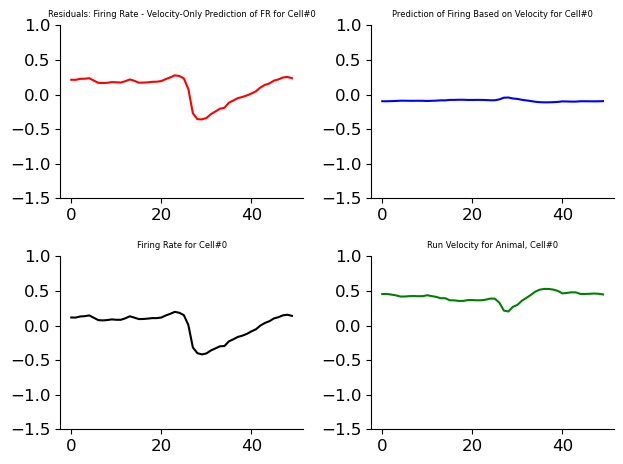

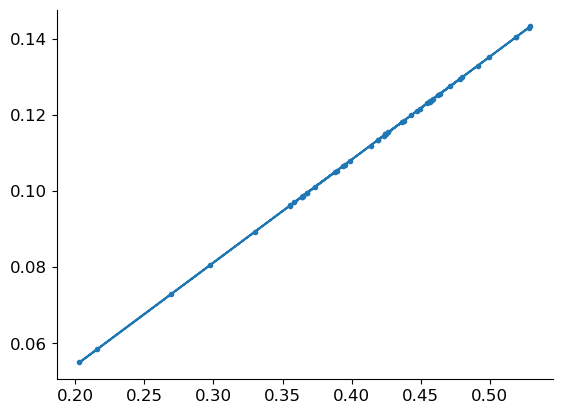

len(neuron_activity_list_SST) 75


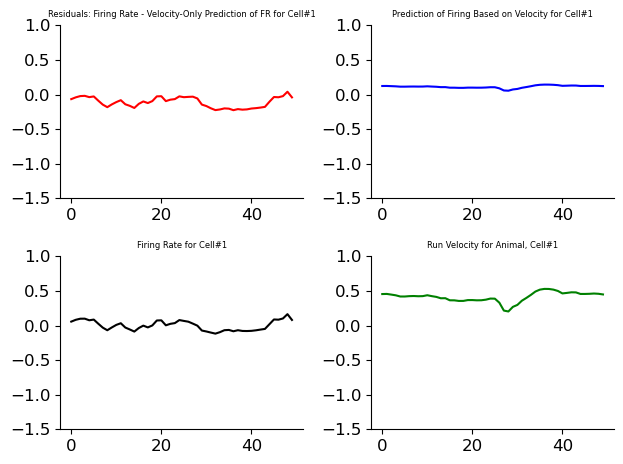

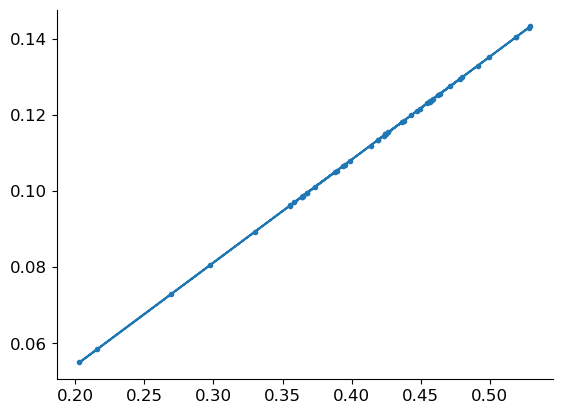

len(neuron_activity_list_SST) 75


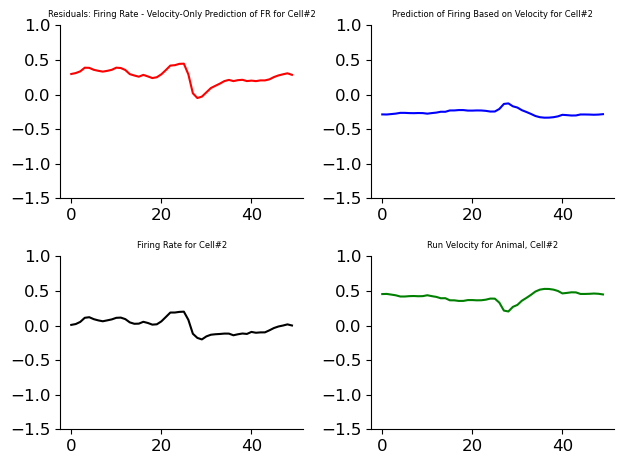

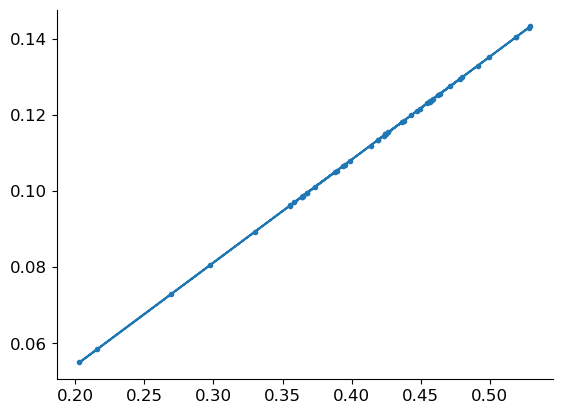

len(neuron_activity_list_SST) 75


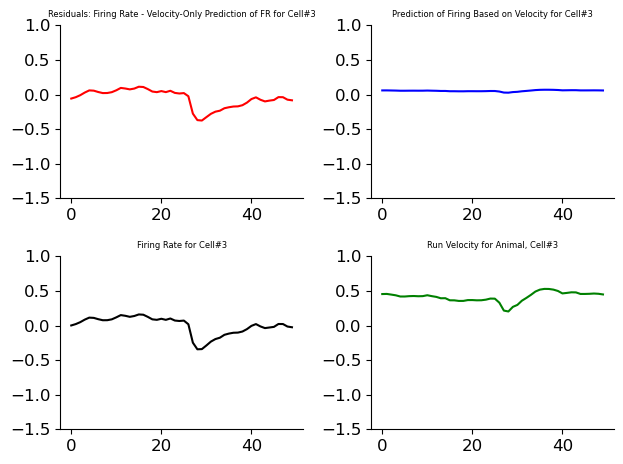

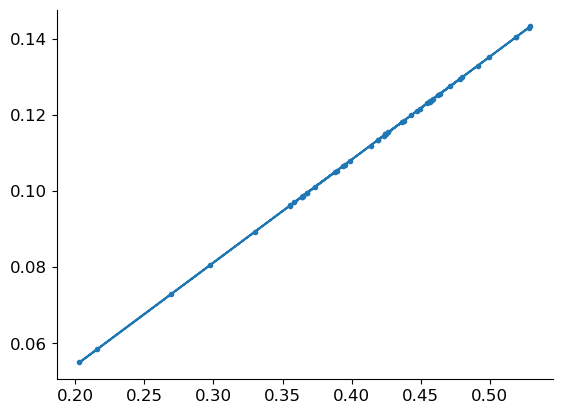

len(neuron_activity_list_SST) 75


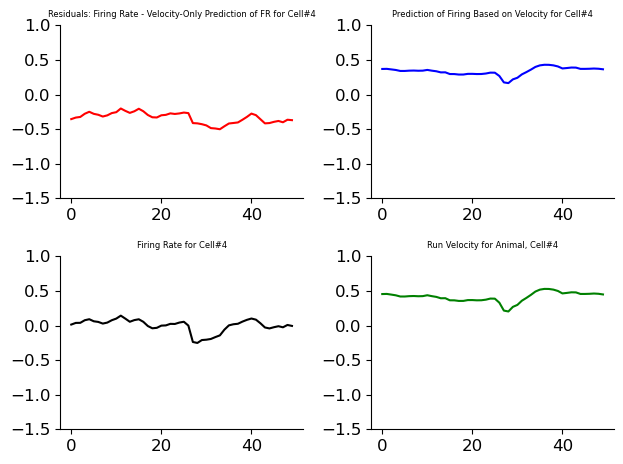

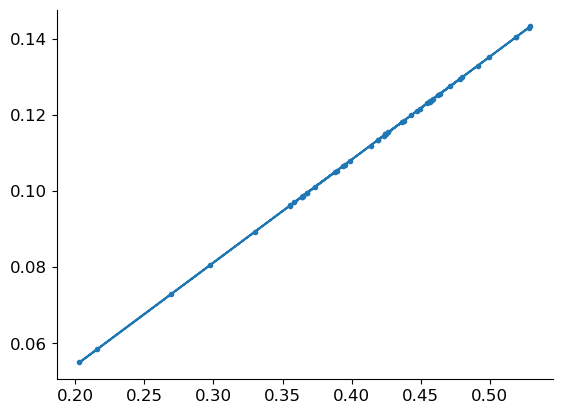

len(neuron_activity_list_SST) 75


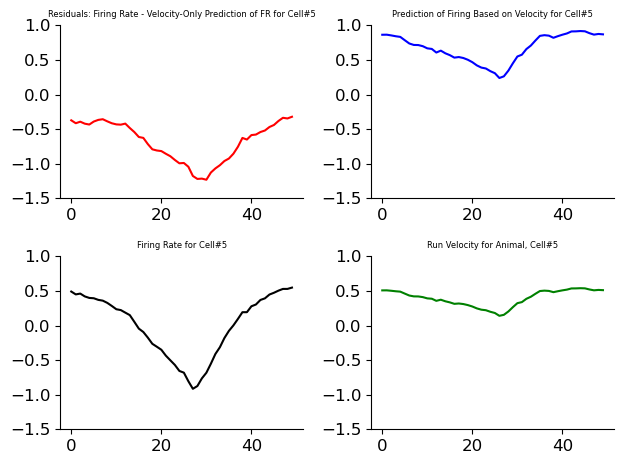

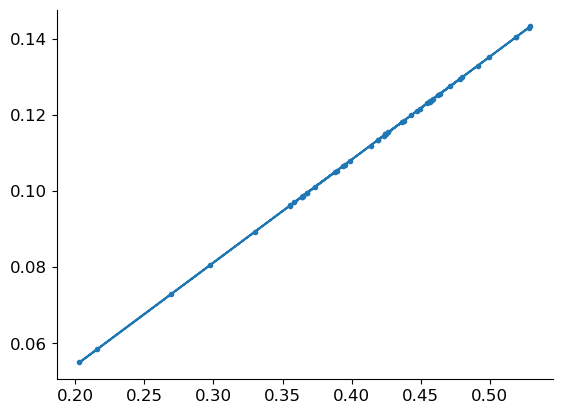

len(neuron_activity_list_SST) 75


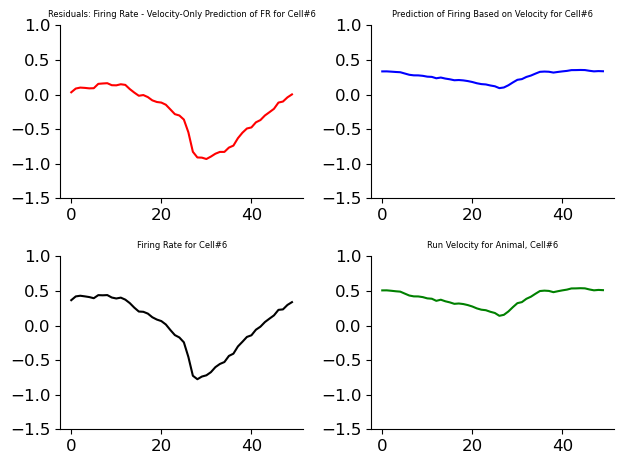

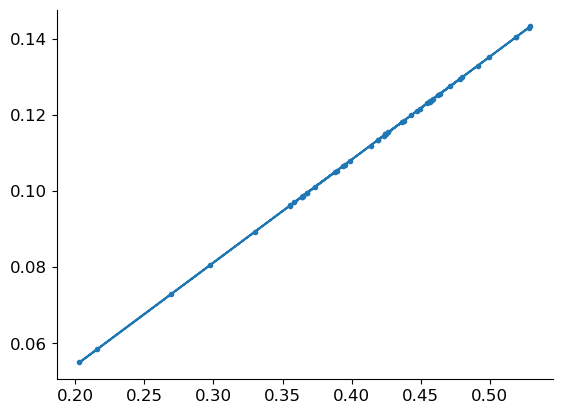

len(neuron_activity_list_SST) 75


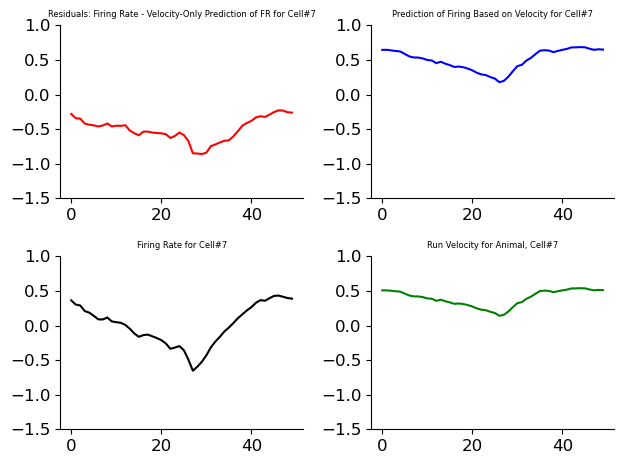

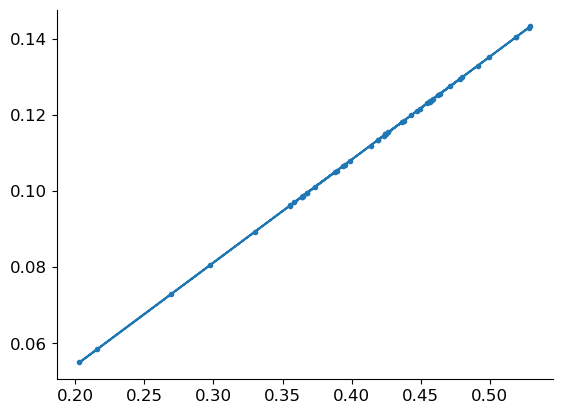

len(neuron_activity_list_SST) 75


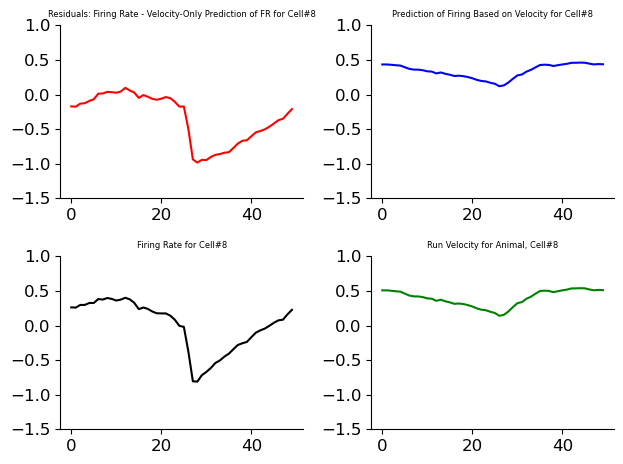

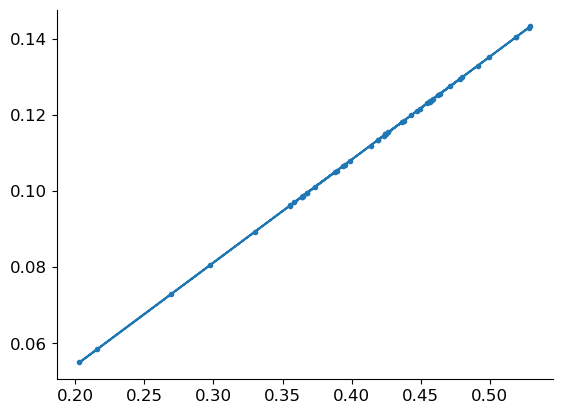

len(neuron_activity_list_SST) 75


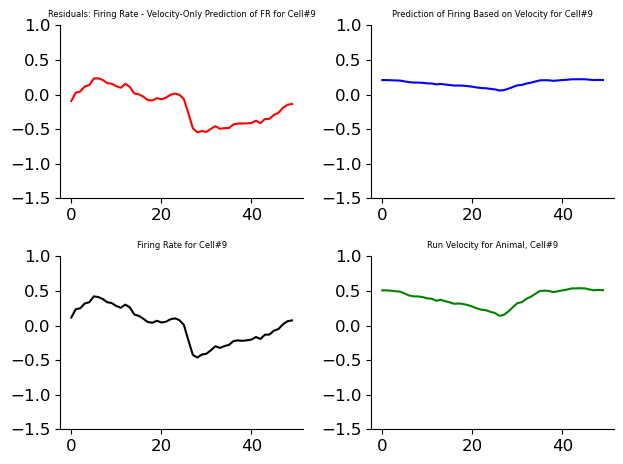

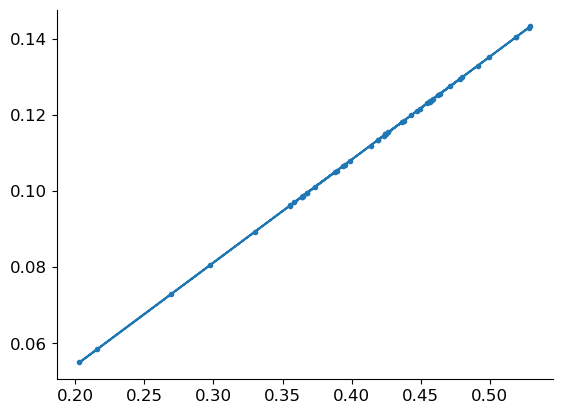

len(neuron_activity_list_SST) 75


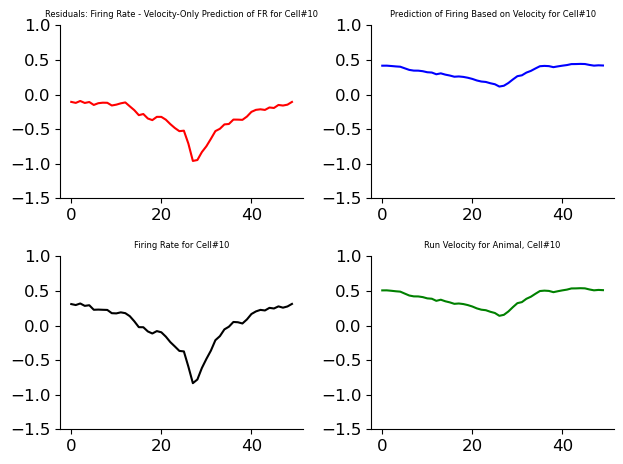

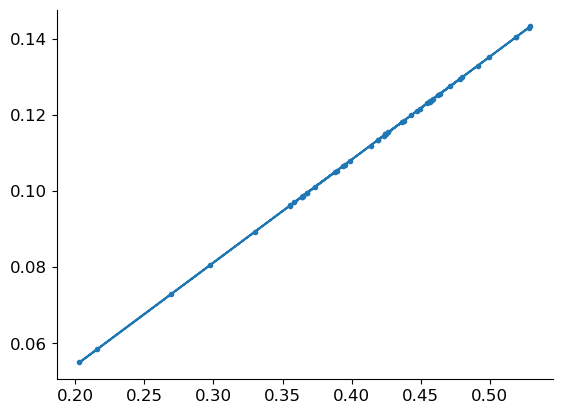

AxisError: axis 1 is out of bounds for array of dimension 0

In [108]:

def plot_cell_velocity_neuron_activity_predicted_activity_off_velocity_and_residuals(reorganized_data, vel_only_neuron_activity_list_zero_final, vel_only_vel_predicted_activity_zero_final, vel_only_residual_activity_zero_final, cell_number):
    
    cell_number = int(cell_number)
    
    trial_average_velocity_list = []
    velocity_list = []
    for animal, subdict in reorganized_data.items():
            for cell, value in subdict.items():
                neuron_data = reorganized_data[animal][cell]
                velocity = neuron_data[:, 3, :]
                velocity_list.append(velocity)
                trial_average_velocity_list.append(np.mean(velocity, axis=1))

    list_of_2d_velocities = [np.vstack(arrays) for arrays in velocity_list]
    
#     print(f"len(residuals_SST_list) {len(residuals_SST_list)}")
    
#     final_residual_list = []
#     for key, value in vel_only_residual_activity_zero_final.items():
#         for key2, value2 in value.items():
#             final_residual_list.append(value2)

    trial_av_residuals_list = []
    for i in vel_only_residual_activity_zero_final:
        trial_av_residuals_list.append(np.mean(i, axis=1))
    
        

    trial_av_velocity_prediction_list = []
    for i in vel_only_vel_predicted_activity_zero_final:
        trial_av_velocity_prediction_list.append(np.mean(i, axis=1))

    print(f"len(neuron_activity_list_SST) {len(neuron_activity_list_SST)}")
        
    trial_av_neuron_activity_list = []
    for i in vel_only_neuron_activity_list_zero_final:
        trial_av_neuron_activity_list.append(np.mean(i, axis=1))

    fig, axs = plt.subplots(2,2)

    axs[0,0].plot(trial_av_residuals_list[cell_number], color='r', label='residuals')
    axs[0,0].set_title(f"Residuals: Firing Rate - Velocity-Only Prediction of FR for Cell#{cell_number}", fontsize=6)
    axs[0,0].set_ylim(-1.5, 1)
    
    axs[0,1].plot(trial_av_velocity_prediction_list[cell_number], color='b', label='velocity prediction')
    axs[0,1].set_title(f"Prediction of Firing Based on Velocity for Cell#{cell_number}", fontsize=6)
    axs[0,1].set_ylim(-1.5, 1)

    axs[1,0].plot(trial_av_neuron_activity_list[cell_number], color='k', label='neuron activity')
    axs[1,0].set_title(f"Firing Rate for Cell#{cell_number}", fontsize=6)
    axs[1,0].set_ylim(-1.5, 1)

    axs[1,1].plot(trial_average_velocity_list[cell_number], color='g')
    axs[1,1].set_title(f"Run Velocity for Animal, Cell#{cell_number}", fontsize=6)
    axs[1,1].set_ylim(-1.5, 1)

    fig.tight_layout()
    fig.show()
    
    plt.figure()
    plt.plot(trial_average_velocity_list[1], trial_av_velocity_prediction_list[1] ,marker='.')
    plt.show()
    
cells = np.arange(0,11)
    
for i in cells:
    plot_cell_velocity_neuron_activity_predicted_activity_off_velocity_and_residuals(reorganized_data, neuron_activity_list_SST, vel_predicted_activity_SST_list, residuals_SST_list, i)




cells = np.arange(0,11)
    
for i in cells:
    plot_cell_velocity_neuron_activity_predicted_activity_off_velocity_and_residuals(reorganized_data, vel_only_neuron_activity_list_zero_final, vel_only_vel_predicted_activity_zero_final, vel_only_residual_activity_zero_final, i)

In [ ]:
#### fitting the GLLM without alot of variables at zero - just handing it in 

In [110]:
def fit_GLM_to_only_velocity_gone(reorganized_data, quintile=None, regression='ridge', renormalize=True, alphas=None):
    GLM_params = {}
    for animal in reorganized_data:
        GLM_params[animal] = {}
        count=0
        for neuron, neuron_data in reorganized_data[animal].items():
            print(f"count{count}")
            neuron_data = neuron_data[:,:,~np.isnan(neuron_data).any(axis=(0,1))]

            if quintile is not None:
                num_trials = neuron_data.shape[2]
                start_idx,end_idx = get_quintile_indices(num_trials, quintile)
                neuron_data = neuron_data[:, :, start_idx:end_idx]
                
                
                
            if renormalize:
                neuron_data = normalize_data(neuron_data)
                
            

            flattened_data = flatten_data(neuron_data)
            design_matrix_X = flattened_data[:, 3].reshape(-1, 1)
            
            print(f"design_matrix_X.shape {design_matrix_X.shape}")
            neuron_activity = flattened_data[:,0]
            print(f"neuron_activity {neuron_activity.shape}")

            if regression == 'lasso':
                model = LassoCV(alphas=alphas, cv=None) if alphas is not None else LassoCV(cv=None)
            elif regression == 'ridge':
                model = RidgeCV(alphas=alphas if alphas is not None else [0.1, 1, 10, 100, 1000, 5000], cv=None)
            elif regression == 'elastic':
                l1_ratio = [0.1, 0.3, 0.5, 0.7, 0.9, 1]
                model = ElasticNetCV(alphas=alphas if alphas is not None else [0.1, 1, 10, 100, 1000, 5000], l1_ratio=l1_ratio, cv=None)
            else:
                raise ValueError("Regression type must be 'lasso' or 'ridge'")

            model.fit(design_matrix_X, neuron_activity)

            predicted_activity = model.predict(design_matrix_X)
            trialavg_neuron_activity = np.mean(neuron_data[:,0,:], axis=1)
            trialavg_predicted_activity = np.mean(predicted_activity.reshape(neuron_data[:,0,:].shape), axis=1)
            pearson_R = np.corrcoef(trialavg_predicted_activity, trialavg_neuron_activity)[0,1]

            GLM_params[animal][neuron] = {
                'weights': model.coef_,
                'intercept': model.intercept_,
                'alpha': model.alpha_ if regression == 'ridge' else model.alpha_,
                'l1_ratio': model.l1_ratio_ if regression == 'elastic' else None,
                'R2': model.score(design_matrix_X, neuron_activity),
                'R2_trialavg': pearson_R**2,
                'model': model
            }
            count+=1
            
            
    return GLM_params


GLM_params = fit_GLM_to_only_velocity_gone(reorganized_data, quintile=None, regression='ridge', renormalize=True, alphas=None)


count0
design_matrix_X.shape (10600, 1)
neuron_activity (10600,)
count1
design_matrix_X.shape (10600, 1)
neuron_activity (10600,)
count2
design_matrix_X.shape (10600, 1)
neuron_activity (10600,)
count3
design_matrix_X.shape (10600, 1)
neuron_activity (10600,)
count4
design_matrix_X.shape (10600, 1)
neuron_activity (10600,)
count0
design_matrix_X.shape (7600, 1)
neuron_activity (7600,)
count1
design_matrix_X.shape (7600, 1)
neuron_activity (7600,)
count2
design_matrix_X.shape (7600, 1)
neuron_activity (7600,)
count3
design_matrix_X.shape (7600, 1)
neuron_activity (7600,)
count4
design_matrix_X.shape (7600, 1)
neuron_activity (7600,)
count5
design_matrix_X.shape (7600, 1)
neuron_activity (7600,)
count6
design_matrix_X.shape (7600, 1)
neuron_activity (7600,)
count7
design_matrix_X.shape (7600, 1)
neuron_activity (7600,)
count8
design_matrix_X.shape (7600, 1)
neuron_activity (7600,)
count9
design_matrix_X.shape (7600, 1)
neuron_activity (7600,)
count10
design_matrix_X.shape (7600, 1)
neuro

In [117]:
print(variable_list)

['Activity', 'Licks', 'Reward_loc', 'Velocity', '#1', '#2', '#3', '#4', '#5', '#6', '#7', '#8', '#9', '#10']


In [120]:
def compute_residual_activity_gone(GLM_params, reorganized_data, quintile=None):
    neuron_activity_list = []
    predicted_activity_list = []
    residual_activity = {}
    avg_residuals = []
    for animal in GLM_params:
        residual_activity[animal] = {}
        for neuron in GLM_params[animal]:
            # Pre-process the data
            neuron_data = reorganized_data[animal][neuron]
            if quintile is not None:
                num_trials = neuron_data.shape[2]
                start_idx,end_idx = get_quintile_indices(num_trials, quintile)
                neuron_data = neuron_data[:, :, start_idx:end_idx]

            flattened_data = flatten_data(neuron_data)
            neuron_activity = neuron_data[:,0,:]

            # Predict activity and compute residuals
            glm_model = GLM_params[animal][neuron]['model']
            flattened_input_variables = flattened_data[:,3]
            flattened_input_variables = flattened_input_variables.reshape(-1, 1)

            print(f"flattened_input_variables {flattened_input_variables}") #######################
            predicted_activity = glm_model.predict(flattened_input_variables)
            predicted_activity = predicted_activity.reshape(neuron_activity.shape)
            predicted_activity_list.append(predicted_activity)
            neuron_activity_list.append(neuron_activity)
            residual_activity[animal][neuron] = neuron_activity - predicted_activity

            avg_residuals.append(np.mean(residual_activity[animal][neuron], axis=1))

    avg_residuals = np.array(avg_residuals)
    return residual_activity, avg_residuals, predicted_activity_list, neuron_activity_list

In [121]:
def compute_variable_subtracted_residuals_only_velocity_gone(reorganized_data, variable_list, variables_to_remove, quintile):
    #fit a GLM for all variables 
    GLM_params = fit_GLM_to_only_velocity_gone(reorganized_data, quintile=quintile, regression='ridge', renormalize=False)
#     vars_to_remove = 
#     vars_to_remove = variable_list.copy()[1:] + ['intercept']
#     removing_list = []

#     #look through the list of variables you try to remove - velocity or licks, etc 
#     for variable in variables_to_remove:
#         if variable in variable_list:
#             index = variable_list.index(variable)
#             removing_list.append(index)

#     for index in removing_list:
#         vars_to_remove.remove(variable_list[index])
        
#     print(f"vars_to_remove {vars_to_remove}") ###############################

#     filtered_GLM_params = fake_remove_variables_from_glm(GLM_params, vars_to_remove, variable_list)
    residual_activity, avg_residuals, predicted_activity, neuron_activity_list = compute_residual_activity_gone(GLM_params, reorganized_data,
                                                                 quintile=quintile)
    return avg_residuals, GLM_params, residual_activity, predicted_activity, neuron_activity_list

vel_only_avg_residuals_zero_gone, vel_only_GLM_params_zero_gone, vel_only_residual_activity_zero_gone, vel_only_vel_predicted_activity_zero_gone, vel_only_neuron_activity_list_zero_gone = compute_variable_subtracted_residuals_only_velocity_gone(reorganized_data, variable_list, [], quintile=None)

count0
design_matrix_X.shape (10600, 1)
neuron_activity (10600,)
count1
design_matrix_X.shape (10600, 1)
neuron_activity (10600,)
count2
design_matrix_X.shape (10600, 1)
neuron_activity (10600,)
count3
design_matrix_X.shape (10600, 1)
neuron_activity (10600,)
count4
design_matrix_X.shape (10600, 1)
neuron_activity (10600,)
count0
design_matrix_X.shape (7600, 1)
neuron_activity (7600,)
count1
design_matrix_X.shape (7600, 1)
neuron_activity (7600,)
count2
design_matrix_X.shape (7600, 1)
neuron_activity (7600,)
count3
design_matrix_X.shape (7600, 1)
neuron_activity (7600,)
count4
design_matrix_X.shape (7600, 1)
neuron_activity (7600,)
count5
design_matrix_X.shape (7600, 1)
neuron_activity (7600,)
count6
design_matrix_X.shape (7600, 1)
neuron_activity (7600,)
count7
design_matrix_X.shape (7600, 1)
neuron_activity (7600,)
count8
design_matrix_X.shape (7600, 1)
neuron_activity (7600,)
count9
design_matrix_X.shape (7600, 1)
neuron_activity (7600,)
count10
design_matrix_X.shape (7600, 1)
neuro

flattened_input_variables [[0.70794079]
 [0.58333834]
 [0.43955977]
 ...
 [0.88366203]
 [0.46313436]
 [0.75680218]]
flattened_input_variables [[0.70794079]
 [0.58333834]
 [0.43955977]
 ...
 [0.88366203]
 [0.46313436]
 [0.75680218]]
flattened_input_variables [[0.70794079]
 [0.58333834]
 [0.43955977]
 ...
 [0.88366203]
 [0.46313436]
 [0.75680218]]
flattened_input_variables [[0.70794079]
 [0.58333834]
 [0.43955977]
 ...
 [0.88366203]
 [0.46313436]
 [0.75680218]]
flattened_input_variables [[0.70794079]
 [0.58333834]
 [0.43955977]
 ...
 [0.88366203]
 [0.46313436]
 [0.75680218]]
flattened_input_variables [[0.70794079]
 [0.58333834]
 [0.43955977]
 ...
 [0.88366203]
 [0.46313436]
 [0.75680218]]
flattened_input_variables [[0.70794079]
 [0.58333834]
 [0.43955977]
 ...
 [0.88366203]
 [0.46313436]
 [0.75680218]]
flattened_input_variables [[0.70794079]
 [0.58333834]
 [0.43955977]
 ...
 [0.88366203]
 [0.46313436]
 [0.75680218]]
flattened_input_variables [[0.70794079]
 [0.58333834]
 [0.43955977]
 ...

len(vel_predicted_activity_SST_list) 75
len(neuron_activity_list_SST) 75


C:\Users\Msfin\AppData\Local\Temp\ipykernel_50220\32298461.py:59: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


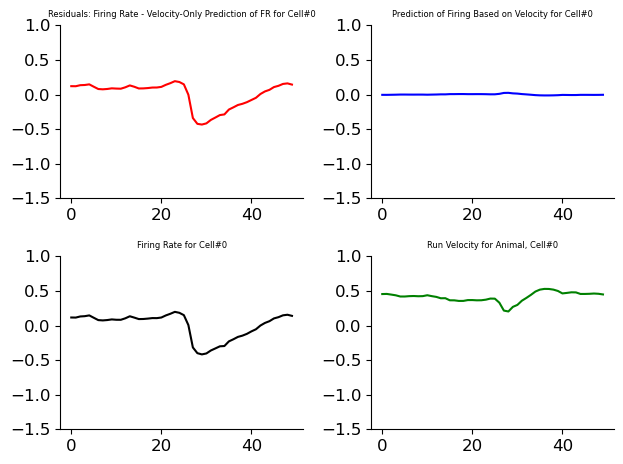

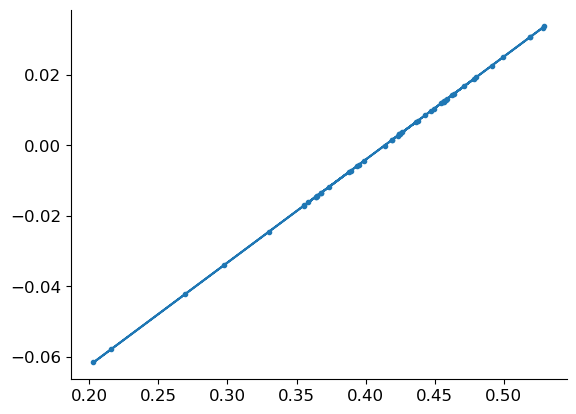

len(vel_predicted_activity_SST_list) 75
len(neuron_activity_list_SST) 75


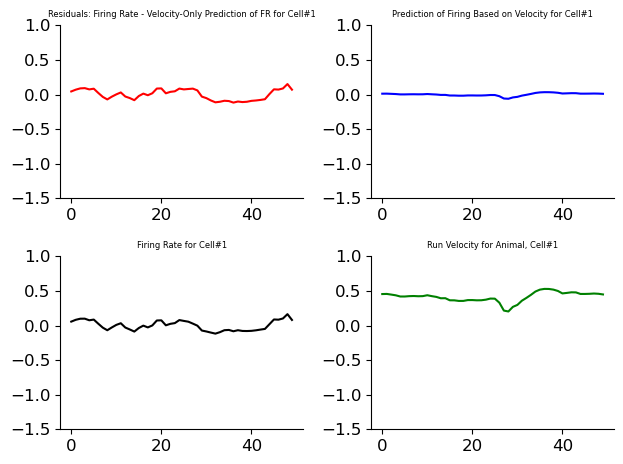

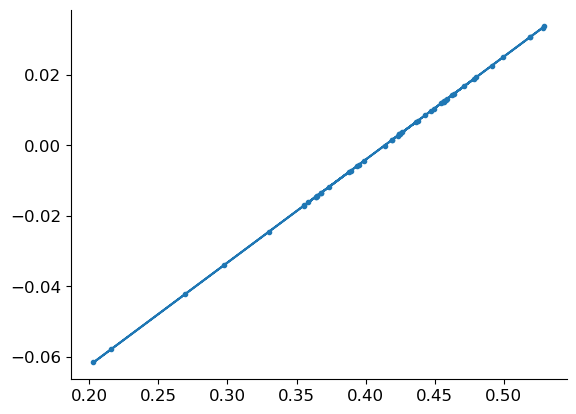

len(vel_predicted_activity_SST_list) 75
len(neuron_activity_list_SST) 75


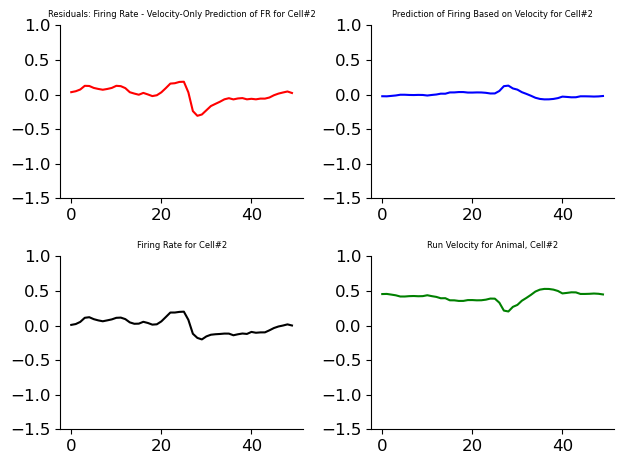

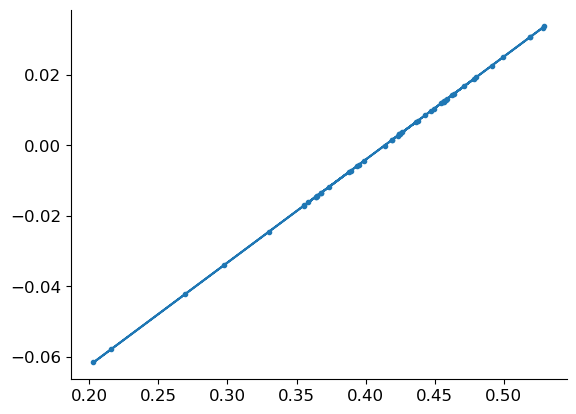

len(vel_predicted_activity_SST_list) 75
len(neuron_activity_list_SST) 75


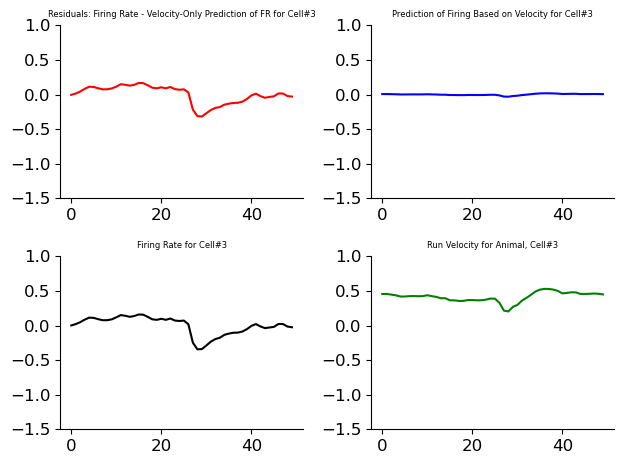

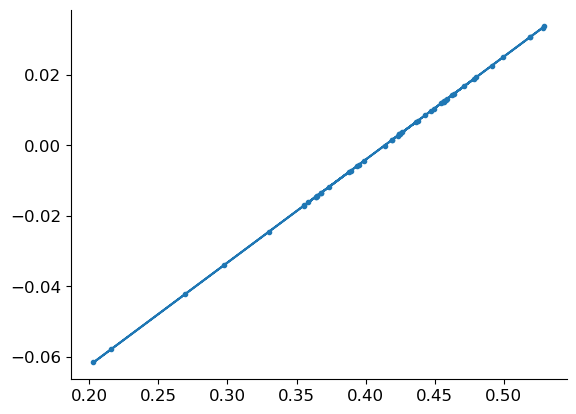

len(vel_predicted_activity_SST_list) 75
len(neuron_activity_list_SST) 75


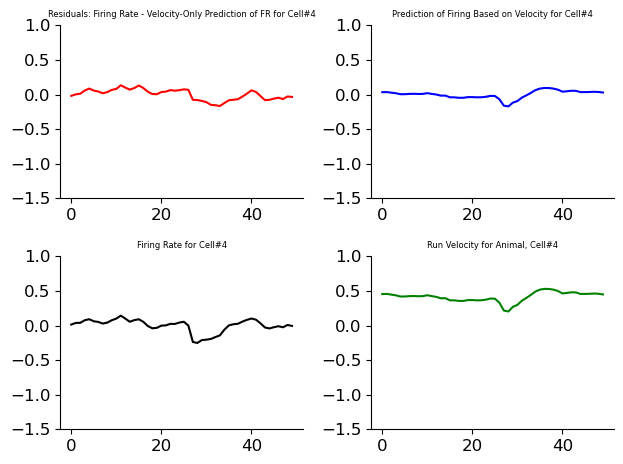

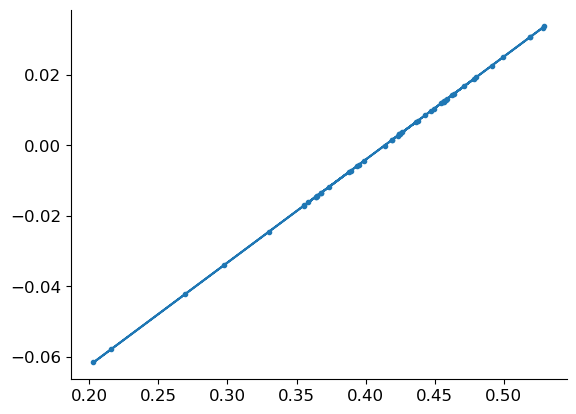

len(vel_predicted_activity_SST_list) 75
len(neuron_activity_list_SST) 75


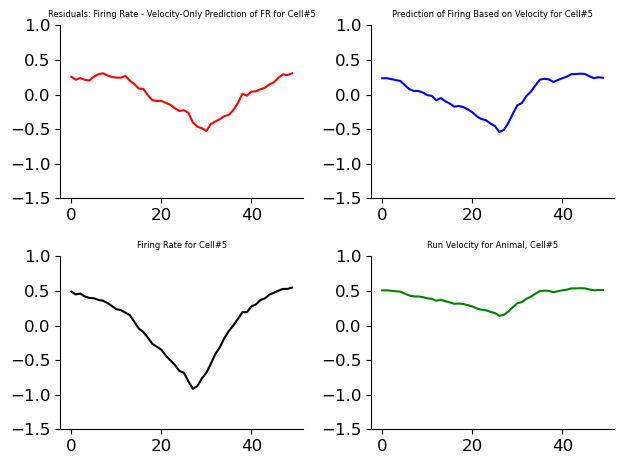

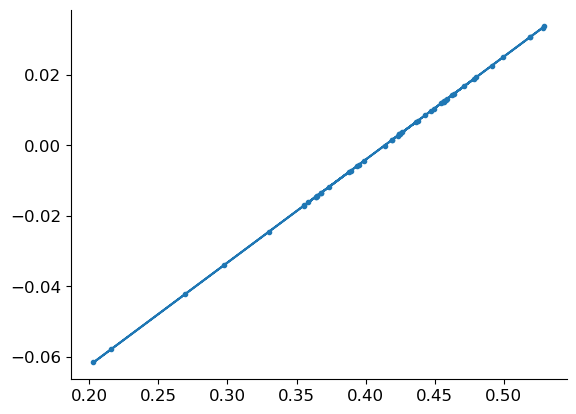

len(vel_predicted_activity_SST_list) 75
len(neuron_activity_list_SST) 75


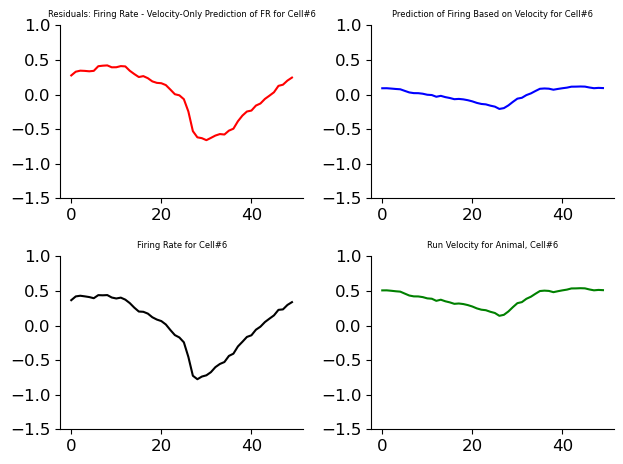

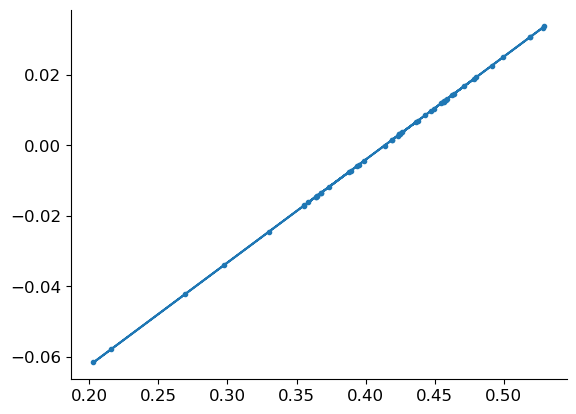

len(vel_predicted_activity_SST_list) 75
len(neuron_activity_list_SST) 75


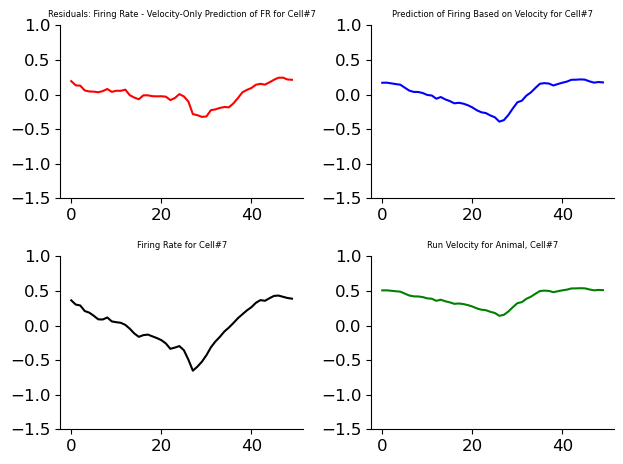

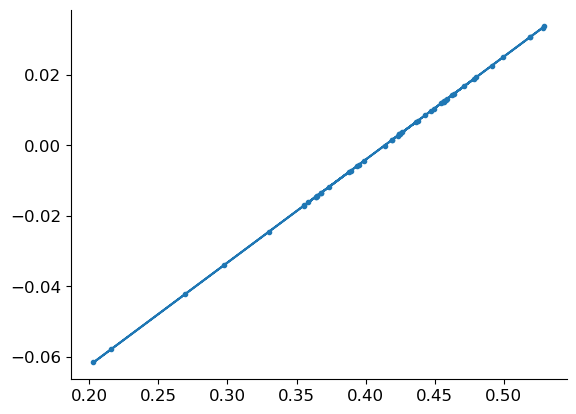

len(vel_predicted_activity_SST_list) 75
len(neuron_activity_list_SST) 75


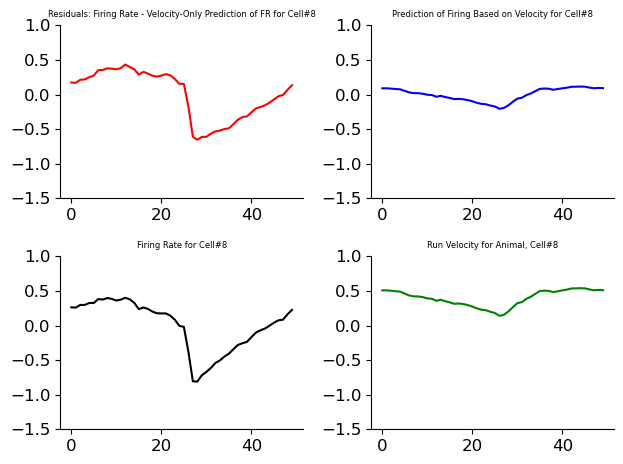

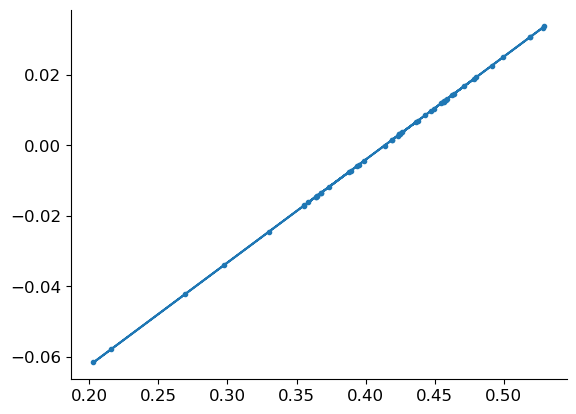

len(vel_predicted_activity_SST_list) 75
len(neuron_activity_list_SST) 75


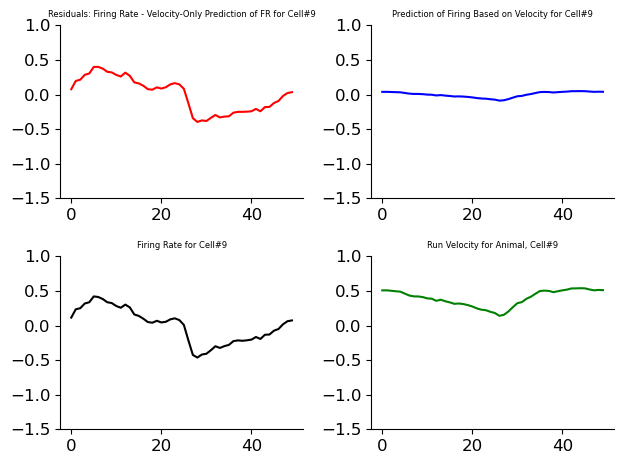

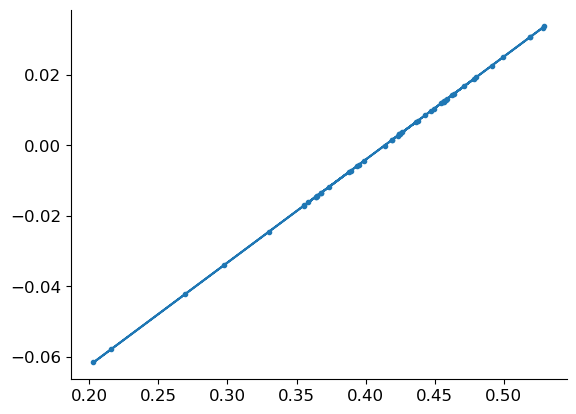

len(vel_predicted_activity_SST_list) 75
len(neuron_activity_list_SST) 75


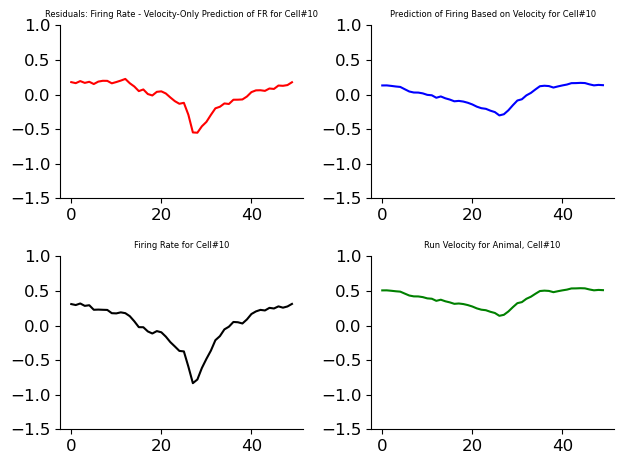

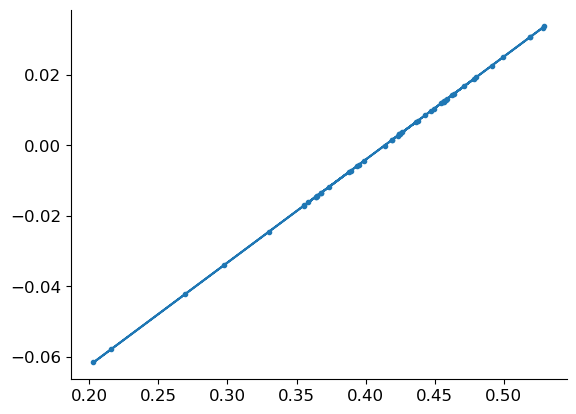

In [127]:
def plot_cell_velocity_neuron_activity_predicted_activity_off_velocity_and_residuals_gone(reorganized_data, vel_only_neuron_activity_list_zero_gone, vel_only_vel_predicted_activity_zero_gone, vel_only_residual_activity_zero_gone, cell_number):
    
    cell_number = int(cell_number)
    
    trial_average_velocity_list = []
    velocity_list = []
    for animal, subdict in reorganized_data.items():
            for cell, value in subdict.items():
                neuron_data = reorganized_data[animal][cell]
                velocity = neuron_data[:, 3, :]
                velocity_list.append(velocity)
                trial_average_velocity_list.append(np.mean(velocity, axis=1))

    list_of_2d_velocities = [np.vstack(arrays) for arrays in velocity_list]
    
    
    all_vel_only_residual_activity_zero_gone = []
    for key, value in vel_only_residual_activity_zero_gone.items():
        for subkey, subdict in value.items():
            all_vel_only_residual_activity_zero_gone.append(subdict)

    trial_av_residuals_list = []
    for i in all_vel_only_residual_activity_zero_gone:
        trial_av_residuals_list.append(np.mean(i, axis=1))
    
        
    print(f"len(vel_predicted_activity_SST_list) {len(vel_predicted_activity_SST_list)}")


    trial_av_velocity_prediction_list = []
    for i in vel_only_vel_predicted_activity_zero_gone:
        trial_av_velocity_prediction_list.append(np.mean(i, axis=1))

    print(f"len(neuron_activity_list_SST) {len(neuron_activity_list_SST)}")
        
    trial_av_neuron_activity_list = []
    for i in vel_only_neuron_activity_list_zero_gone:
        trial_av_neuron_activity_list.append(np.mean(i, axis=1))

    fig, axs = plt.subplots(2,2)

    axs[0,0].plot(trial_av_residuals_list[cell_number], color='r', label='residuals')
    axs[0,0].set_title(f"Residuals: Firing Rate - Velocity-Only Prediction of FR for Cell#{cell_number}", fontsize=6)
    axs[0,0].set_ylim(-1.5, 1)
    
    axs[0,1].plot(trial_av_velocity_prediction_list[cell_number], color='b', label='velocity prediction')
    axs[0,1].set_title(f"Prediction of Firing Based on Velocity for Cell#{cell_number}", fontsize=6)
    axs[0,1].set_ylim(-1.5, 1)

    axs[1,0].plot(trial_av_neuron_activity_list[cell_number], color='k', label='neuron activity')
    axs[1,0].set_title(f"Firing Rate for Cell#{cell_number}", fontsize=6)
    axs[1,0].set_ylim(-1.5, 1)

    axs[1,1].plot(trial_average_velocity_list[cell_number], color='g')
    axs[1,1].set_title(f"Run Velocity for Animal, Cell#{cell_number}", fontsize=6)
    axs[1,1].set_ylim(-1.5, 1)

    fig.tight_layout()
    fig.show()
    
    plt.figure()
    plt.plot(trial_average_velocity_list[1], trial_av_velocity_prediction_list[1] ,marker='.')
    plt.show()
    
cells = np.arange(0,11)
    
for i in cells:
    plot_cell_velocity_neuron_activity_predicted_activity_off_velocity_and_residuals_gone(reorganized_data, vel_only_neuron_activity_list_zero_gone, vel_only_vel_predicted_activity_zero_gone, vel_only_residual_activity_zero_gone, i)

In [ ]:
###### reorganizing the data 

In [128]:
def preprocess_data(filepath, normalize=True, num_spatial_bins=10):
    data_dict = mat73.loadmat(filepath)

    # Define new position variables to use as input for the GLM
    position_matrix = np.zeros((50, num_spatial_bins))
    bin_size = 50//num_spatial_bins
    for i in range(num_spatial_bins):
        position_matrix[i*bin_size:(i+1)*bin_size,i] = 1

    reorganized_data = {}
    variable_list = []

    for animal_idx, (delta_f,velocity,lick_rate,reward_loc) in enumerate(zip(data_dict['animal']['ShiftR'], data_dict['animal']['ShiftRunning'], data_dict['animal']['ShiftLrate'], data_dict['animal']['ShiftV'])):
        reorganized_data[f'animal_{animal_idx + 1}'] = {}

        for i, neuron_idx in enumerate(range(delta_f.shape[2])):
            if np.all(np.isnan(delta_f[:,:,neuron_idx])) or np.all(delta_f[:,:,neuron_idx] == 0):
                continue

            neuron_data = []
            
            # Neuron activity
            neuron_data.append(delta_f[:,:,neuron_idx]) 
            variable_list.append('Activity') if 'Activity' not in variable_list else None
            
            # Lick rate
            neuron_data.append(lick_rate)  
            variable_list.append('Licks') if 'Licks' not in variable_list else None

            # Reward location (valve opening)
            neuron_data.append(reward_loc)
            variable_list.append('Reward_loc') if 'Reward_loc' not in variable_list else None

            # Running speed
            neuron_data.append(velocity)
            variable_list.append('Velocity') if 'Velocity' not in variable_list else None

            ####################################################
            # TODO: EC_GLM.mat has a data mismatch (missing trial in neuron activity). Check with Christine
            num_trials = np.min([neuron_data[i].shape[1] for i in range(len(neuron_data))])
            for i in range(len(neuron_data)):
                neuron_data[i] = neuron_data[i][:, :num_trials]
            ####################################################

            neuron_data = np.stack(neuron_data, axis=1)

            # Add position variables to the data matrix
            expanded_position_matrix = np.repeat(position_matrix[:, :, np.newaxis], neuron_data.shape[2], axis=2) # Copy along the 'trials' dimension
            neuron_data = np.concatenate((neuron_data, expanded_position_matrix), axis=1)
            variable_list.extend([f'#{i}' for i in range(1, num_spatial_bins+1)]) if f'#{i}' not in variable_list else None

            # Filter out NaN trials
            neuron_data = neuron_data[:, :, ~np.isnan(neuron_data).any(axis=(0, 1))]

            if normalize:
                neuron_data = normalize_data(neuron_data)

            reorganized_data[f'animal_{animal_idx + 1}'][f'cell_{neuron_idx + 1}'] = neuron_data

    return reorganized_data, variable_list

reorganized_data_five, variable_list_five = preprocess_data(filepath_SST, normalize=True, num_spatial_bins=5)

In [131]:
avg_residuals_five_velocity, GLM_params, residual_activity_velocity_five, vel_predicted_activity_five_list, neuron_activity_list_five = compute_variable_subtracted_residuals(reorganized_data_five, variable_list_five, ["Velocity"], quintile=None)

vars_to_remove ['Licks', 'Reward_loc', '#1', '#2', '#3', '#4', '#5', 'intercept']
params {'weights': array([ 0.        ,  0.        , -0.12268075,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ]), 'intercept': 0, 'alpha': 10.0, 'l1_ratio': None, 'R2': 0.01955834187860972, 'R2_trialavg': 0.540696442007319, 'model': RidgeCV(alphas=[0.1, 1, 10, 100, 1000, 5000])}
params {'weights': array([0.        , 0.        , 0.33048248, 0.        , 0.        ,
       0.        , 0.        , 0.        ]), 'intercept': 0, 'alpha': 10.0, 'l1_ratio': None, 'R2': 0.006309393110972894, 'R2_trialavg': 0.4344388070509826, 'model': RidgeCV(alphas=[0.1, 1, 10, 100, 1000, 5000])}
params {'weights': array([ 0.        ,  0.        , -0.57207591,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ]), 'intercept': 0, 'alpha': 10.0, 'l1_ratio': None, 'R2': 0.01877701975285906, 'R2_trialavg': 0.3421096330910871, 'model': RidgeCV(alphas=[0.1, 1, 10, 100, 1000, 5000])}
params {

In [137]:
print(len(residual_activity_velocity_five))

10


len(trial_av_residuals_list) (50,)
len(trial_av_residuals_list) 75
len(neuron_activity_list_SST) 75


C:\Users\Msfin\AppData\Local\Temp\ipykernel_50220\2699911446.py:62: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


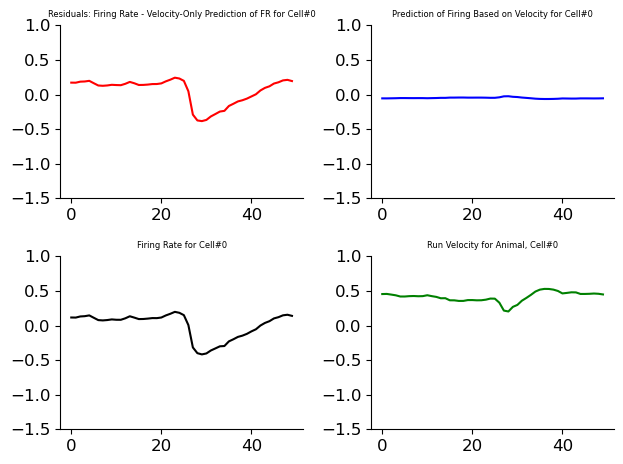

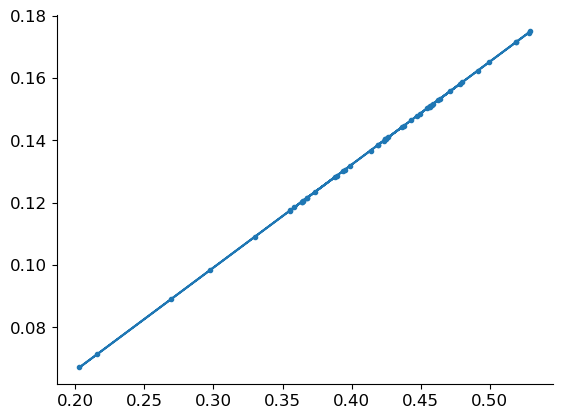

len(trial_av_residuals_list) (50,)
len(trial_av_residuals_list) 75
len(neuron_activity_list_SST) 75


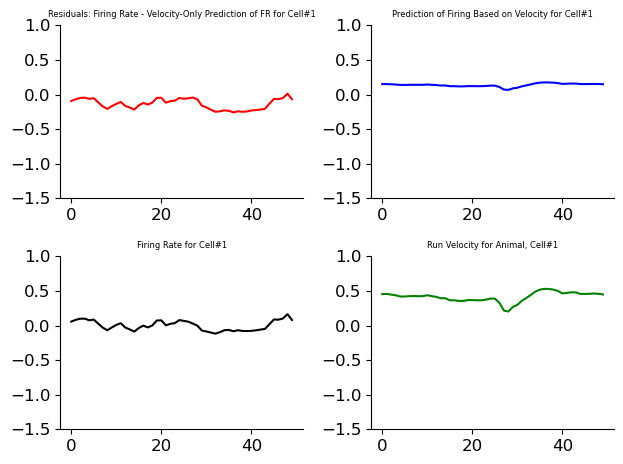

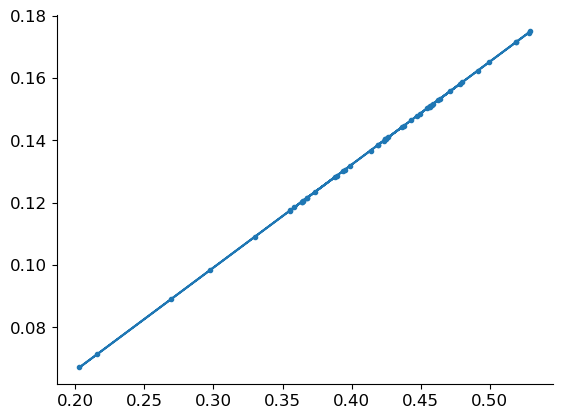

len(trial_av_residuals_list) (50,)
len(trial_av_residuals_list) 75
len(neuron_activity_list_SST) 75


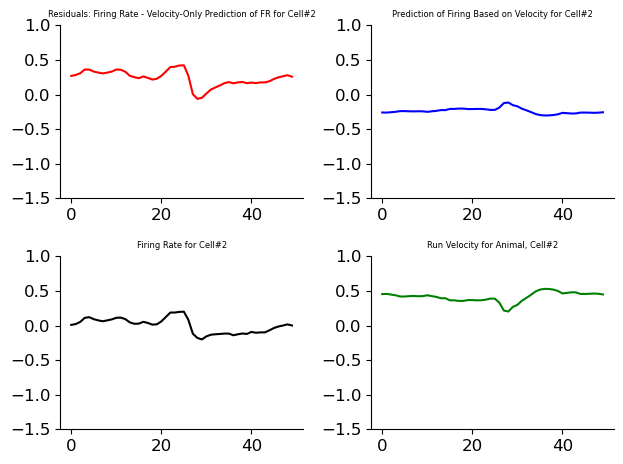

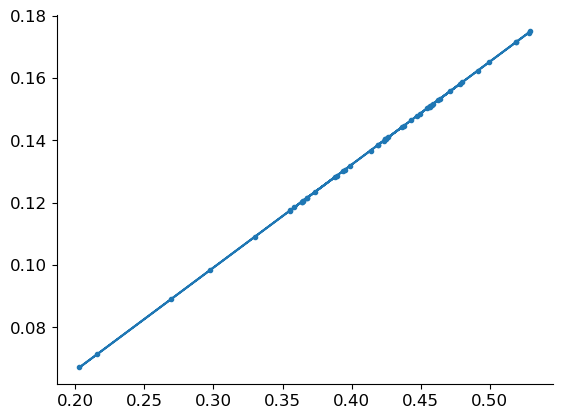

len(trial_av_residuals_list) (50,)
len(trial_av_residuals_list) 75
len(neuron_activity_list_SST) 75


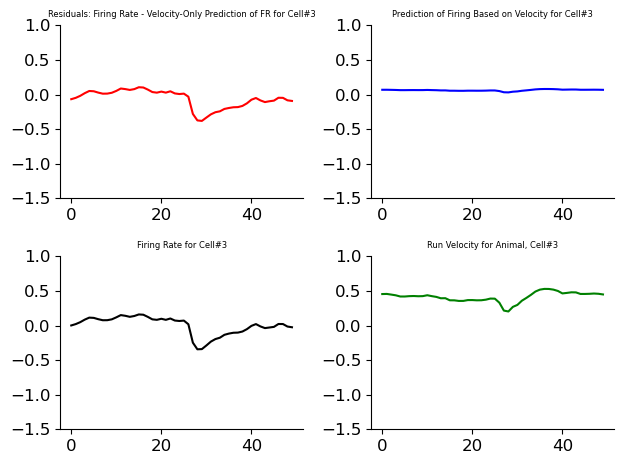

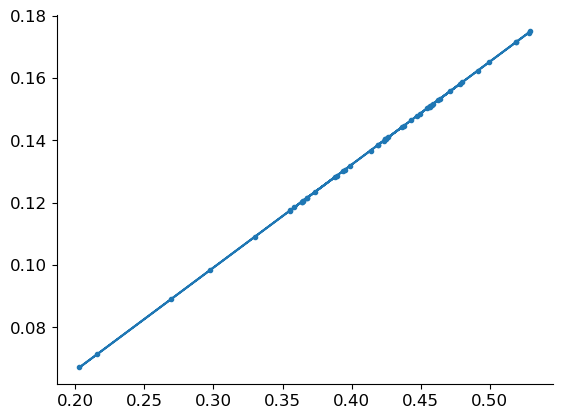

len(trial_av_residuals_list) (50,)
len(trial_av_residuals_list) 75
len(neuron_activity_list_SST) 75


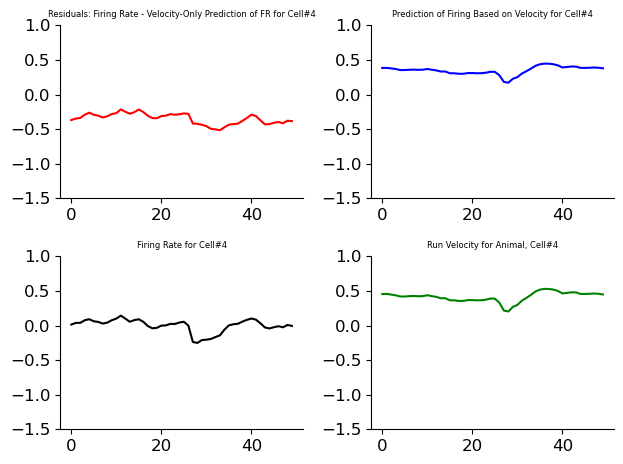

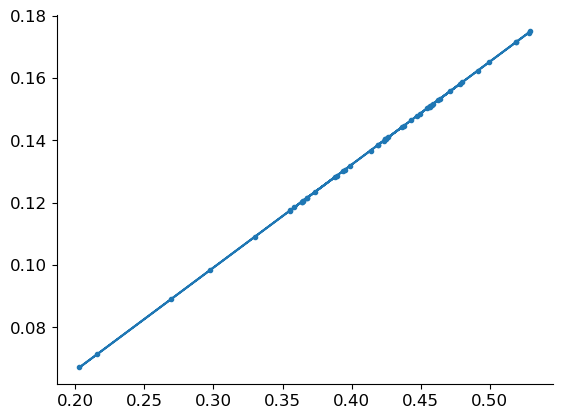

len(trial_av_residuals_list) (50,)
len(trial_av_residuals_list) 75
len(neuron_activity_list_SST) 75


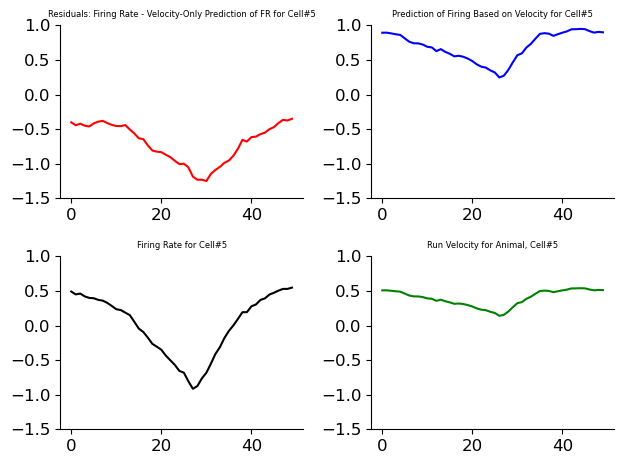

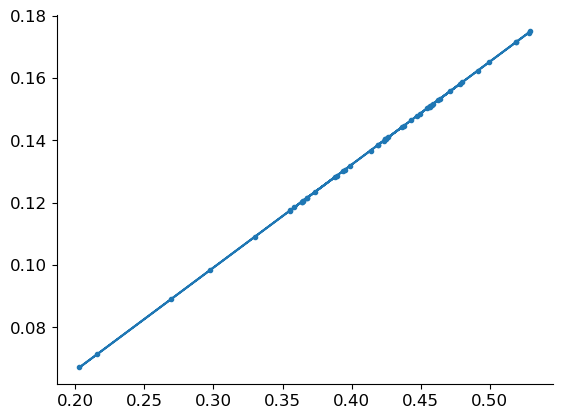

len(trial_av_residuals_list) (50,)
len(trial_av_residuals_list) 75
len(neuron_activity_list_SST) 75


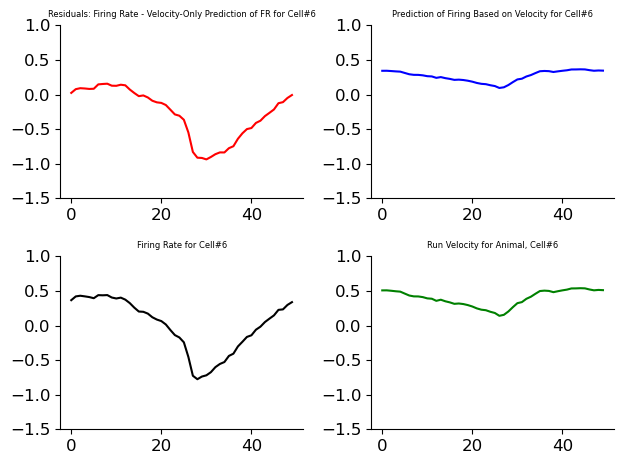

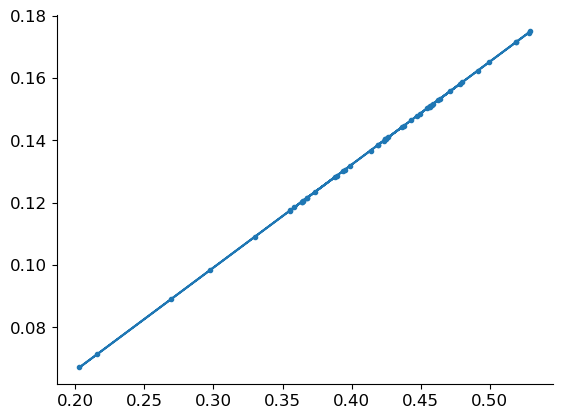

len(trial_av_residuals_list) (50,)
len(trial_av_residuals_list) 75
len(neuron_activity_list_SST) 75


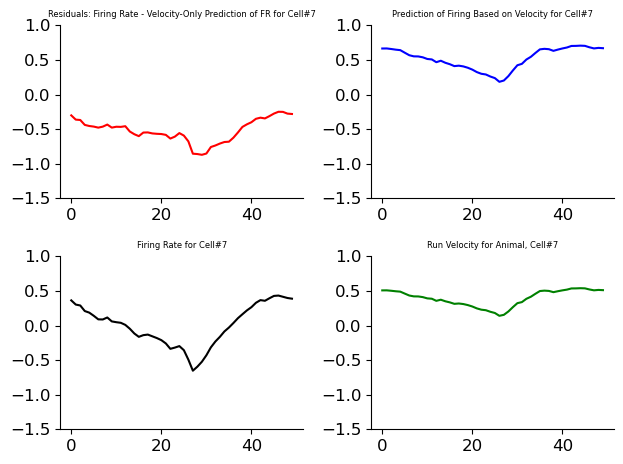

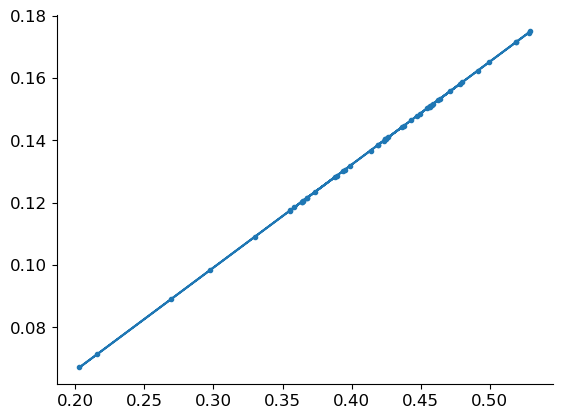

len(trial_av_residuals_list) (50,)
len(trial_av_residuals_list) 75
len(neuron_activity_list_SST) 75


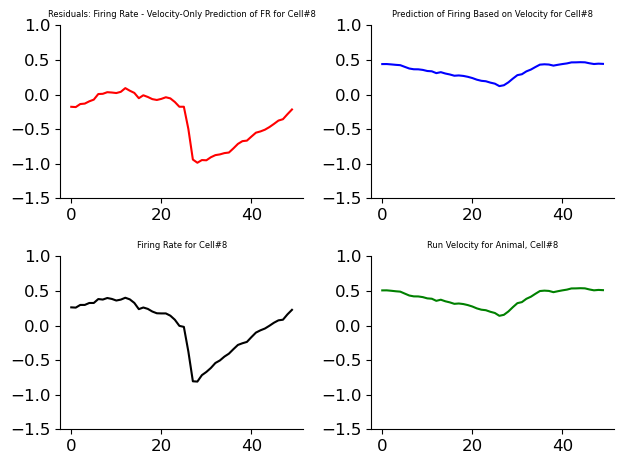

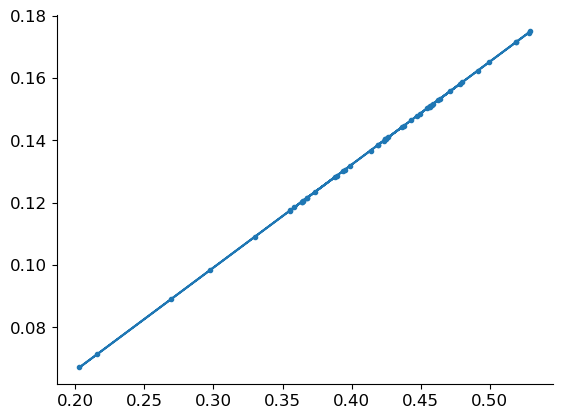

len(trial_av_residuals_list) (50,)
len(trial_av_residuals_list) 75
len(neuron_activity_list_SST) 75


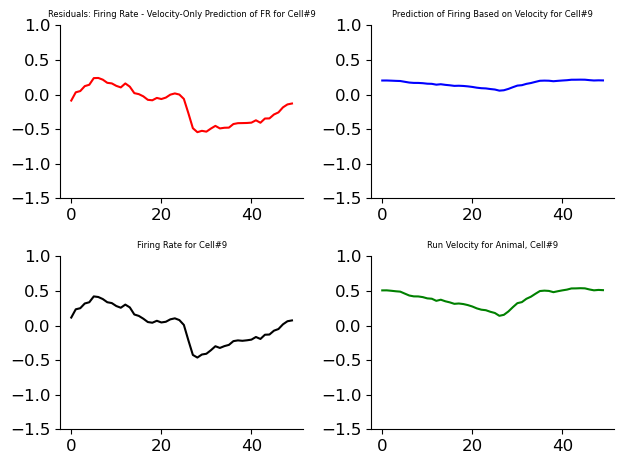

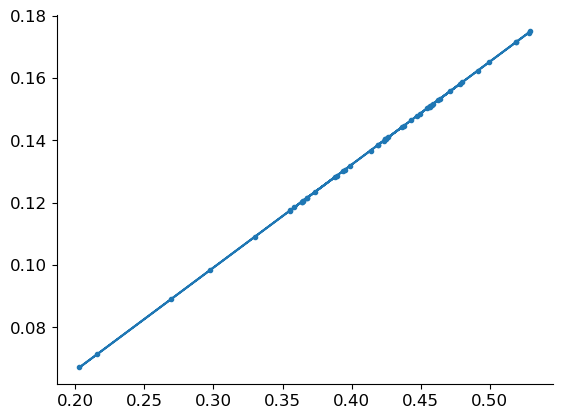

len(trial_av_residuals_list) (50,)
len(trial_av_residuals_list) 75
len(neuron_activity_list_SST) 75


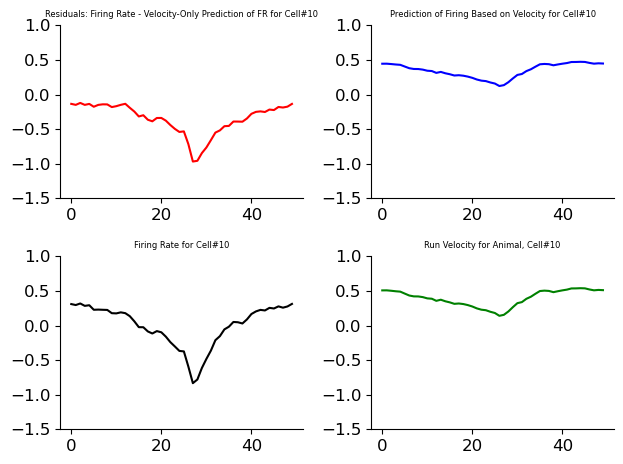

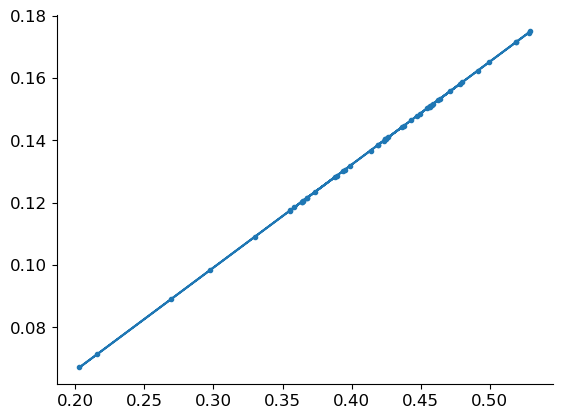

In [140]:


def plot_cell_velocity_neuron_activity_predicted_activity_five(reorganized_data, neuron_activity_list_SST, vel_predicted_activity_SST_list, residuals_SST_list, cell_number):
    
    cell_number = int(cell_number)
    
    trial_average_velocity_list = []
    velocity_list = []
    for animal, subdict in reorganized_data.items():
            for cell, value in subdict.items():
                neuron_data = reorganized_data[animal][cell]
                velocity = neuron_data[:, 3, :]
                velocity_list.append(velocity)
                trial_average_velocity_list.append(np.mean(velocity, axis=1))

    list_of_2d_velocities = [np.vstack(arrays) for arrays in velocity_list]
    
    
    full_residuals_SST_list = []
    for key, value in residuals_SST_list.items():
        for key2, value2 in value.items():
            full_residuals_SST_list.append(value2)
            
    
    trial_av_residuals_list = []
    for i in full_residuals_SST_list:
        trial_av_residuals_list.append(np.mean(i, axis=1))
        
    print(f"len(trial_av_residuals_list) {trial_av_residuals_list[1].shape}")
    
        
    print(f"len(trial_av_residuals_list) {len(trial_av_residuals_list)}")


    trial_av_velocity_prediction_list = []
    for i in vel_predicted_activity_SST_list:
        trial_av_velocity_prediction_list.append(np.mean(i, axis=1))

    print(f"len(neuron_activity_list_SST) {len(neuron_activity_list_SST)}")
        
    trial_av_neuron_activity_list = []
    for i in neuron_activity_list_SST:
        trial_av_neuron_activity_list.append(np.mean(i, axis=1))

    fig, axs = plt.subplots(2,2)

    axs[0,0].plot(trial_av_residuals_list[cell_number], color='r', label='residuals')
    axs[0,0].set_title(f"Residuals: Firing Rate - Velocity-Only Prediction of FR for Cell#{cell_number}", fontsize=6)
    axs[0,0].set_ylim(-1.5, 1)
    
    axs[0,1].plot(trial_av_velocity_prediction_list[cell_number], color='b', label='velocity prediction')
    axs[0,1].set_title(f"Prediction of Firing Based on Velocity for Cell#{cell_number}", fontsize=6)
    axs[0,1].set_ylim(-1.5, 1)

    axs[1,0].plot(trial_av_neuron_activity_list[cell_number], color='k', label='neuron activity')
    axs[1,0].set_title(f"Firing Rate for Cell#{cell_number}", fontsize=6)
    axs[1,0].set_ylim(-1.5, 1)

    axs[1,1].plot(trial_average_velocity_list[cell_number], color='g')
    axs[1,1].set_title(f"Run Velocity for Animal, Cell#{cell_number}", fontsize=6)
    axs[1,1].set_ylim(-1.5, 1)

    fig.tight_layout()
    fig.show()
    
    plt.figure()
    plt.plot(trial_average_velocity_list[1], trial_av_velocity_prediction_list[1] ,marker='.')
    plt.show()
    


cells = np.arange(0,11)
    
for i in cells:
    plot_cell_velocity_neuron_activity_predicted_activity_five(reorganized_data_five, neuron_activity_list_five, vel_predicted_activity_five_list, residual_activity_velocity_five, i)

In [141]:
print(variable_list)

['Activity', 'Licks', 'Reward_loc', 'Velocity', '#1', '#2', '#3', '#4', '#5', '#6', '#7', '#8', '#9', '#10']


In [ ]:
##### fitting the GLM on everything but then subtracting out the effect of position 

In [142]:
avg_residuals_SST_position, GLM_params, residual_activity_SST_position, predicted_activity_SST_position, neuron_activity_list_SST_position = compute_variable_subtracted_residuals(reorganized_data, variable_list, ['#1', '#2', '#3', '#4', '#5', '#6', '#7', '#8', '#9', '#10'], quintile=None)

vars_to_remove ['Licks', 'Reward_loc', 'Velocity', 'intercept']
params {'weights': array([ 0.        ,  0.        ,  0.        ,  0.14191937,  0.0959436 ,
        0.11067447,  0.09649576,  0.16058026, -0.29691116, -0.33055524,
       -0.13977735,  0.01241299,  0.1492173 ]), 'intercept': 0, 'alpha': 10.0, 'l1_ratio': None, 'R2': 0.03176303333314501, 'R2_trialavg': 0.8933778759100398, 'model': RidgeCV(alphas=[0.1, 1, 10, 100, 1000, 5000])}
params {'weights': array([ 0.        ,  0.        ,  0.        ,  0.06841019, -0.00494448,
       -0.02367196,  0.01477594,  0.05012321,  0.04343141, -0.08169371,
       -0.09398648, -0.05668458,  0.08424045]), 'intercept': 0, 'alpha': 100.0, 'l1_ratio': None, 'R2': 0.007701943976180514, 'R2_trialavg': 0.7674429029781443, 'model': RidgeCV(alphas=[0.1, 1, 10, 100, 1000, 5000])}
params {'weights': array([ 0.        ,  0.        ,  0.        ,  0.08799233,  0.09096268,
        0.08430118,  0.00431662,  0.13062913, -0.19661125, -0.1316638 ,
       -0.04940

flattened_input_variables [[0.         0.         0.24025852 ... 0.         0.         0.        ]
 [0.         0.         0.33578023 ... 0.         0.         0.        ]
 [0.         0.         0.25541901 ... 0.         0.         0.        ]
 ...
 [0.         0.         0.30943604 ... 0.         0.         1.        ]
 [0.         0.         0.76504164 ... 0.         0.         1.        ]
 [0.         0.         0.53259136 ... 0.         0.         1.        ]]
flattened_input_variables [[0.         0.         0.24025852 ... 0.         0.         0.        ]
 [0.         0.         0.33578023 ... 0.         0.         0.        ]
 [0.         0.         0.25541901 ... 0.         0.         0.        ]
 ...
 [0.         0.         0.30943604 ... 0.         0.         1.        ]
 [0.         0.         0.76504164 ... 0.         0.         1.        ]
 [0.         0.         0.53259136 ... 0.         0.         1.        ]]
flattened_input_variables [[0.         0.         0.08702293

In [155]:
def plot_cell_velocity_neuron_activity_predicted_position(reorganized_data, neuron_activity_list_SST, vel_predicted_activity_SST_list, residuals_SST_list, cell_number):
    
    cell_number = int(cell_number)
    
    trial_average_velocity_list = []
    velocity_list = []
    for animal, subdict in reorganized_data.items():
            for cell, value in subdict.items():
                neuron_data = reorganized_data[animal][cell]
                velocity = neuron_data[:, 3, :]
                velocity_list.append(velocity)
                trial_average_velocity_list.append(np.mean(velocity, axis=1))

    list_of_2d_velocities = [np.vstack(arrays) for arrays in velocity_list]
    
    
    full_residuals_SST_list = []
    for key, value in residuals_SST_list.items():
        for key2, value2 in value.items():
            full_residuals_SST_list.append(value2)
            
    
    trial_av_residuals_list = []
    for i in full_residuals_SST_list:
        trial_av_residuals_list.append(np.mean(i, axis=1))
        
  
    trial_av_velocity_prediction_list = []
    for i in vel_predicted_activity_SST_list:
        trial_av_velocity_prediction_list.append(np.mean(i, axis=1))
        
    trial_av_neuron_activity_list = []
    for i in neuron_activity_list_SST:
        trial_av_neuron_activity_list.append(np.mean(i, axis=1))

    fig, axs = plt.subplots(2,2)

    axs[0,0].plot(trial_av_residuals_list[cell_number], color='r', label='residuals')
    axs[0,0].set_title(f"Residuals: Firing Rate - Position Bin-Only Prediction of FR for Cell#{cell_number}", fontsize=6)
    axs[0,0].set_ylim(-1.5, 1)
    
    axs[0,1].plot(trial_av_velocity_prediction_list[cell_number], color='b', label='velocity prediction')
    axs[0,1].set_title(f"Prediction of Firing Based on Position Bins for Cell#{cell_number}", fontsize=6)
    axs[0,1].set_ylim(-1.5, 1)

    axs[1,0].plot(trial_av_neuron_activity_list[cell_number], color='k', label='neuron activity')
    axs[1,0].set_title(f"Firing Rate for Cell#{cell_number}", fontsize=6)
    axs[1,0].set_ylim(-1.5, 1)

    axs[1,1].plot(trial_average_velocity_list[cell_number], color='g')
    axs[1,1].set_title(f"Run Velocity for Animal, Cell#{cell_number}", fontsize=6)
    axs[1,1].set_ylim(-1.5, 1)

    fig.tight_layout()
    fig.show()
    
    return trial_av_neuron_activity_list, trial_av_velocity_prediction_list, trial_av_residuals_list
    
    

C:\Users\Msfin\AppData\Local\Temp\ipykernel_50220\367375568.py:55: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


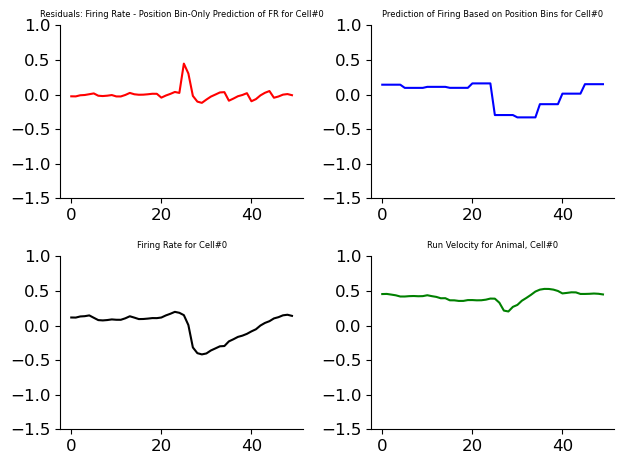

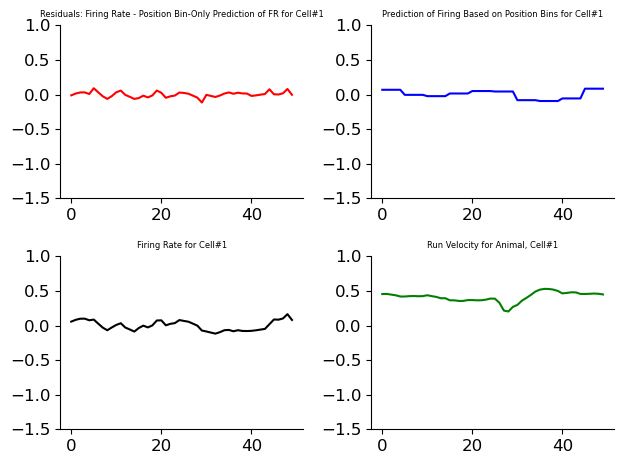

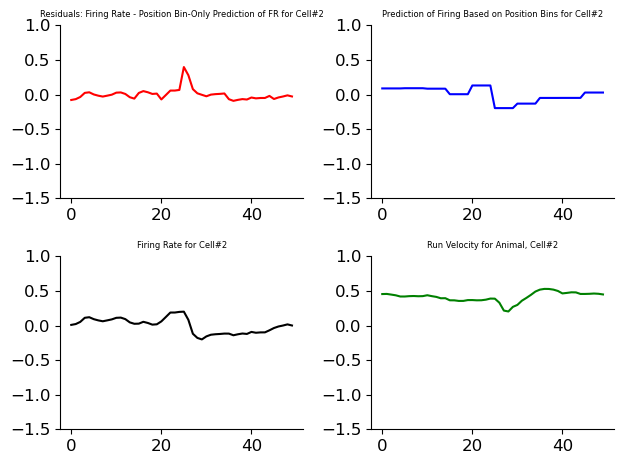

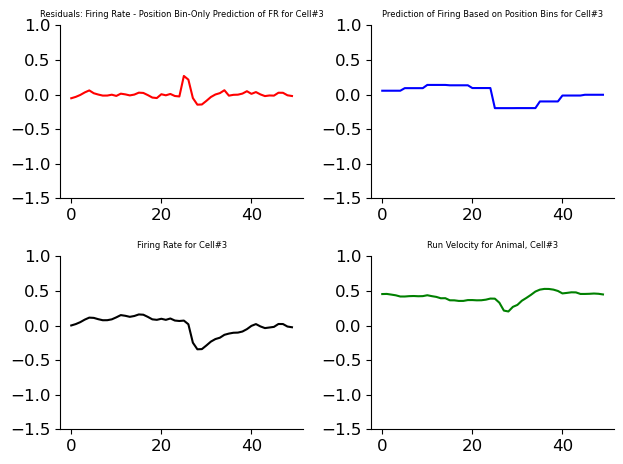

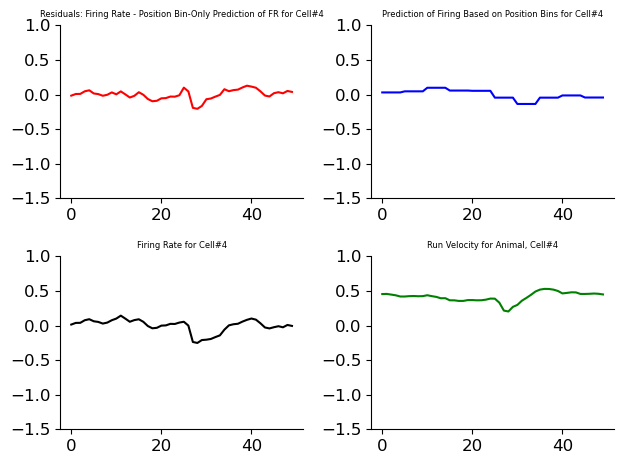

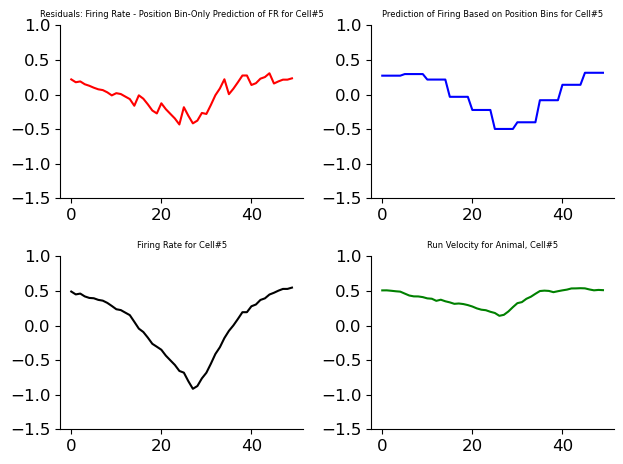

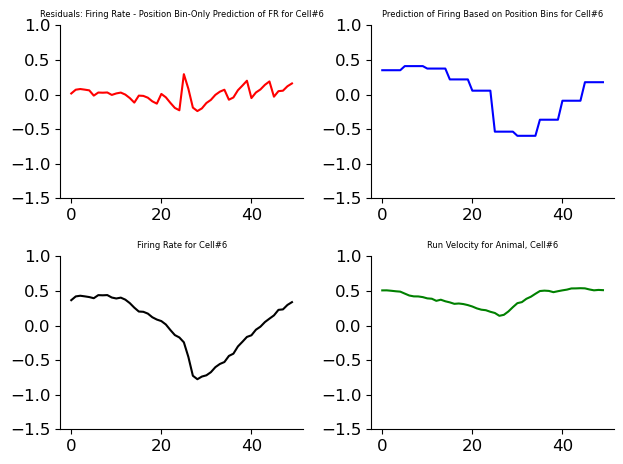

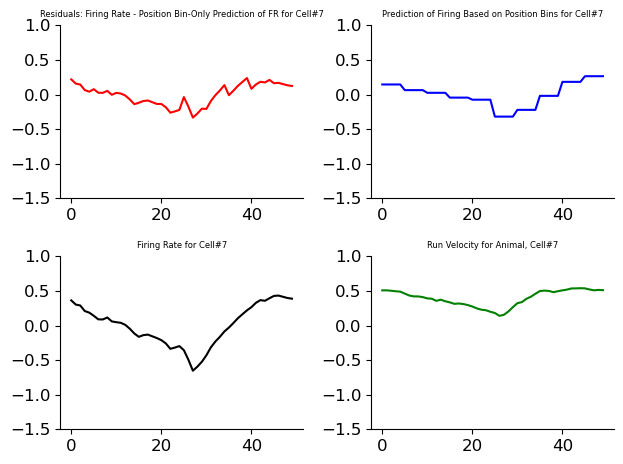

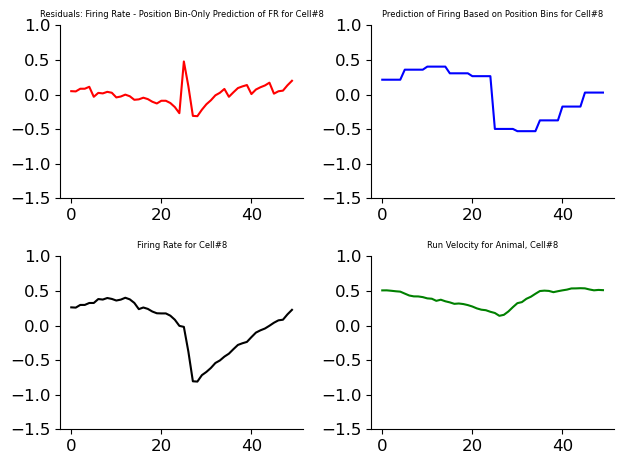

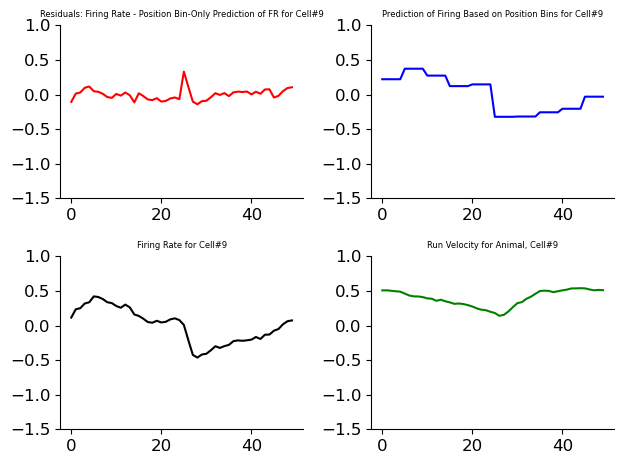

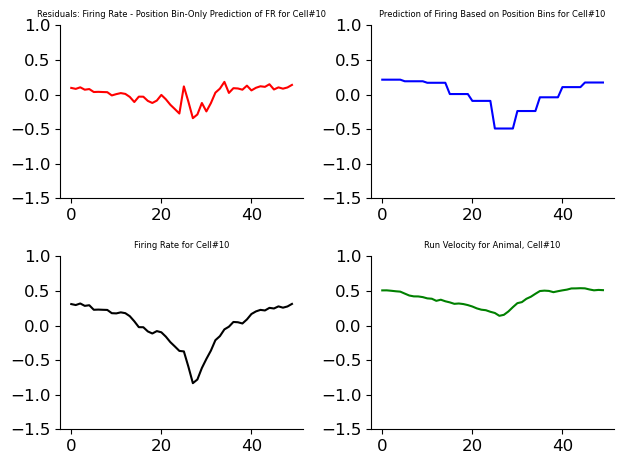

In [156]:
cells = np.arange(0,11)
    
for i in cells:
    trial_av_neuron_activity_list, trial_av_position_prediction_list, trial_av_residuals_list_position = plot_cell_velocity_neuron_activity_predicted_position(reorganized_data, neuron_activity_list_SST_position, predicted_activity_SST_position, residual_activity_SST_position, i)

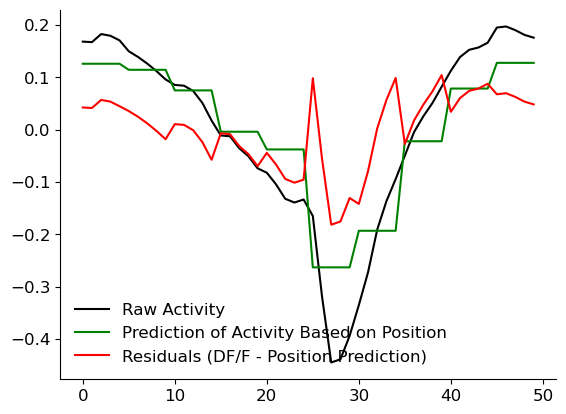

In [164]:

trial_av_neuron_activity_list_2d = np.vstack(trial_av_neuron_activity_list)

trial_av_position_prediction_list_2d = np.vstack(trial_av_position_prediction_list)

trial_av_residuals_list_position_2d = np.vstack(trial_av_residuals_list_position)


plt.figure()
plt.plot(np.mean(trial_av_neuron_activity_list_2d, axis=0), color='k', label="Raw Activity")
plt.plot(np.mean(trial_av_position_prediction_list_2d, axis=0), color='g', label="Prediction of Activity Based on Position")
plt.plot(np.mean(trial_av_residuals_list_position_2d, axis=0), color='r', label="Residuals (DF/F - Position Prediction)")
plt.legend()
plt.show()

In [172]:
print(variable_list_five)

['Activity', 'Licks', 'Reward_loc', 'Velocity', '#1', '#2', '#3', '#4', '#5']


In [173]:
avg_residuals_SST_position_five, GLM_params, residual_activity_SST_position_five, predicted_activity_SST_position_five, neuron_activity_list_SST_position_five = compute_variable_subtracted_residuals(reorganized_data_five, variable_list_five, ['#1', '#2', '#3', '#4', '#5'], quintile=None)

vars_to_remove ['Licks', 'Reward_loc', 'Velocity', 'intercept']
params {'weights': array([ 0.        ,  0.        ,  0.        ,  0.11261882,  0.10102524,
       -0.03888239, -0.24593926,  0.0711776 ]), 'intercept': 0, 'alpha': 10.0, 'l1_ratio': None, 'R2': 0.01955834187860972, 'R2_trialavg': 0.540696442007319, 'model': RidgeCV(alphas=[0.1, 1, 10, 100, 1000, 5000])}
params {'weights': array([ 0.        ,  0.        ,  0.        ,  0.03328847, -0.00349843,
        0.05704208, -0.09862477,  0.01179264]), 'intercept': 0, 'alpha': 10.0, 'l1_ratio': None, 'R2': 0.006309393110972894, 'R2_trialavg': 0.4344388070509826, 'model': RidgeCV(alphas=[0.1, 1, 10, 100, 1000, 5000])}
params {'weights': array([ 0.        ,  0.        ,  0.        ,  0.08507557,  0.04221075,
       -0.01236844, -0.09767448, -0.01724339]), 'intercept': 0, 'alpha': 10.0, 'l1_ratio': None, 'R2': 0.01877701975285906, 'R2_trialavg': 0.3421096330910871, 'model': RidgeCV(alphas=[0.1, 1, 10, 100, 1000, 5000])}
params {'weights':

C:\Users\Msfin\AppData\Local\Temp\ipykernel_50220\367375568.py:55: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


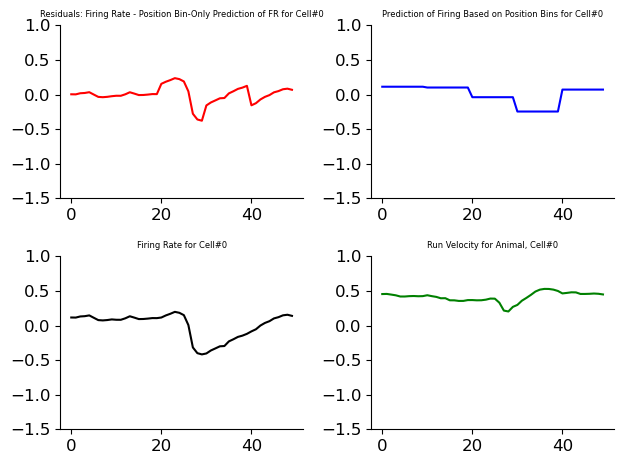

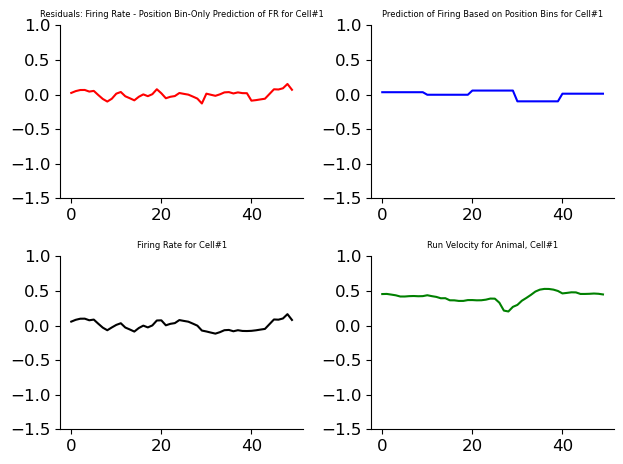

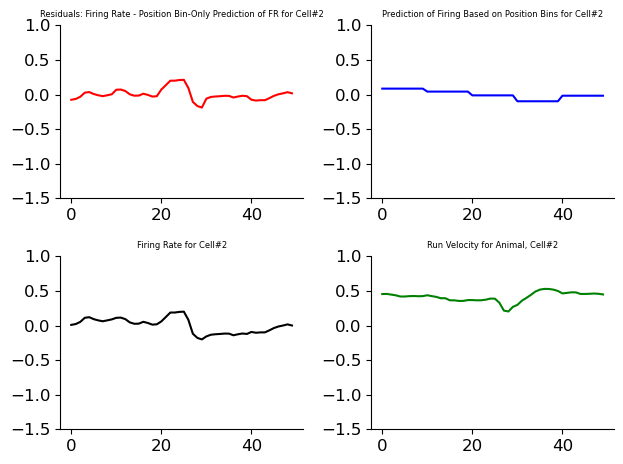

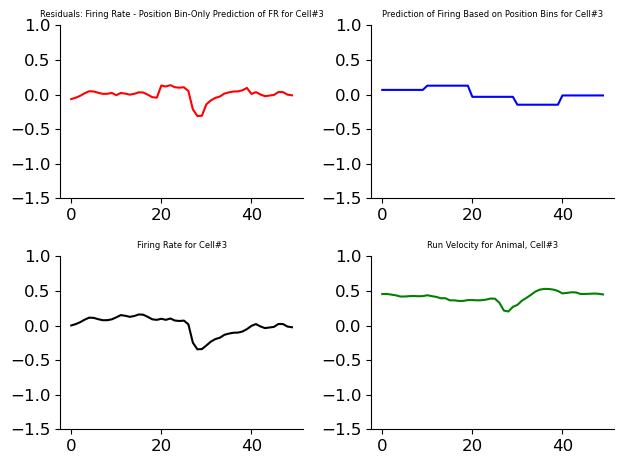

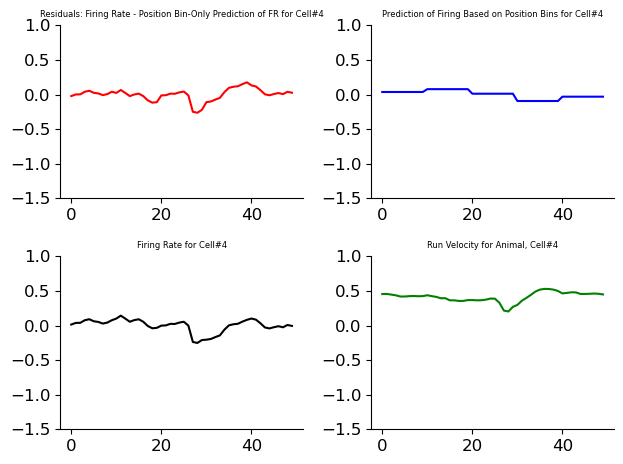

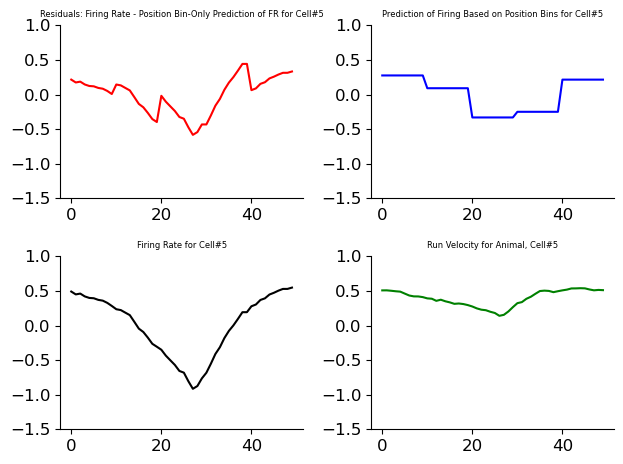

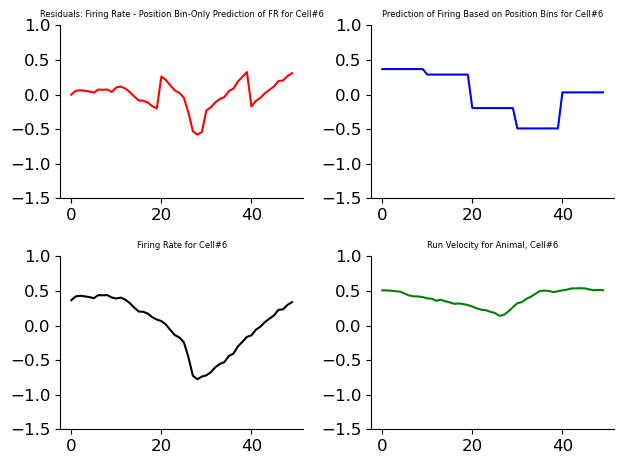

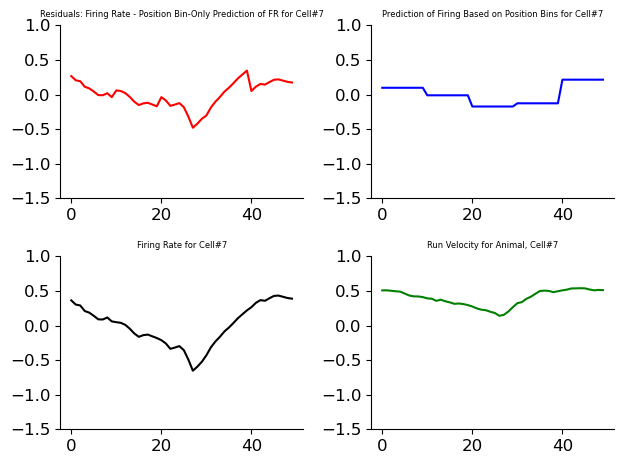

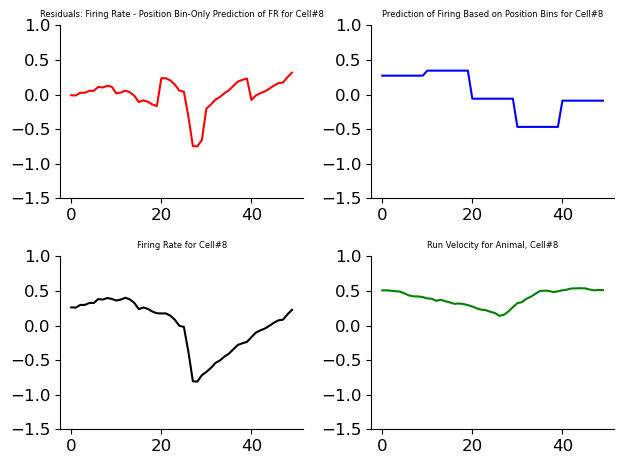

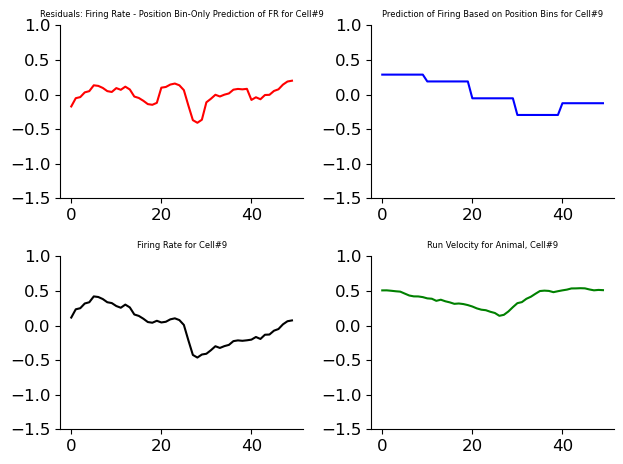

In [174]:
cell = 10
for i in range(cell):
    trial_av_neuron_activity_list_five, trial_av_position_prediction_list_five, trial_av_residuals_list_position_five = plot_cell_velocity_neuron_activity_predicted_position(reorganized_data_five, neuron_activity_list_SST_position_five, predicted_activity_SST_position_five, residual_activity_SST_position_five, i)

In [188]:
vel_only_avg_residuals_zero_list = []

vel_only_avg_residuals_zero = np.vstack(vel_only_avg_residuals_zero)

for i in vel_only_avg_residuals_zero:
    vel_only_avg_residuals_zero_list.append(i)

print(len(vel_only_avg_residuals_zero_list))


print(vel_only_avg_residuals_zero.shape)

print(list_of_2d_velocities[1].shape)


list_of_2d_velocities_mean = []
for i in list_of_2d_velocities:
    list_of_2d_velocities_mean.append(np.mean(i, axis=1))

print(list_of_2d_velocities_mean[1].shape)

list_of_2d_velocities_mean_list = []

list_of_2d_velocities_mean = np.vstack(list_of_2d_velocities_mean)

for i in list_of_2d_velocities_mean:
    list_of_2d_velocities_mean_list.append(i)

75
(75, 50)
(50, 212)
(50,)


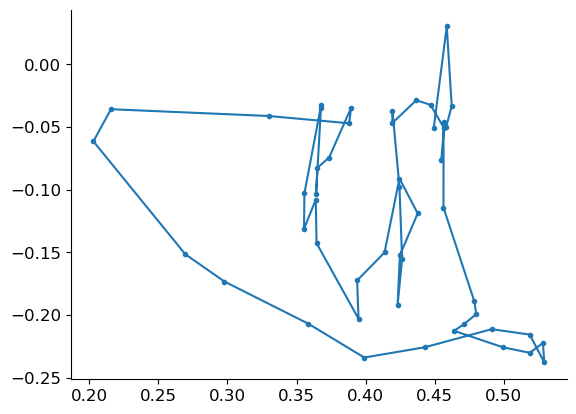

In [189]:
plt.plot(list_of_2d_velocities_mean_list[1], vel_only_avg_residuals_zero_list[1], marker='.')

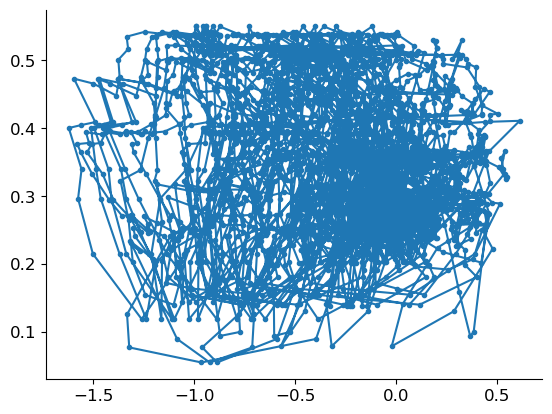

In [187]:
flat_vel_only_avg_residuals_zero = vel_only_avg_residuals_zero.flatten()
flat_list_of_2d_velocities_mean = list_of_2d_velocities_mean.flatten()


plt.plot(flat_vel_only_avg_residuals_zero, flat_list_of_2d_velocities_mean, marker='.')